<a href="https://colab.research.google.com/github/versprechen08/DATA7903-project-/blob/main/test01_v2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproducible Evaluation Framework for LLMs on Small-Scale Benchmarks

**Author:** Qing Zhang (S4762069) | **Course:** DATA7903 | **University:** The University of Queensland

This notebook implements the complete experimental pipeline for evaluating three lightweight LLMs (Qwen2.5-1.5B-Instruct, Gemma-2-2B-it, SmolLM2-360M-Instruct) across three text classification benchmarks (SST-2, AG News, IMDb) with 160+ experimental configurations.

---
## 1. Environment Setup and Dependencies

In [1]:
# ============================================================
# Dependency imports
# datasets: HuggingFace dataset library for loading standard benchmarks
# re: regex for cleaning HTML tags in IMDb
# collections.Counter: for majority baseline calculation
# ============================================================
from datasets import load_dataset
from collections import Counter
import re

## 2. Dataset Loading

In [2]:
# ============================================================
# Load three datasets
# SST-2: Stanford Sentiment (positive/negative), from movie reviews
# AG News: News topic classification (4 classes: World/Sports/Business/Sci-Tech)
# IMDb: Movie review sentiment analysis (positive/negative), longer text
# ============================================================
sst2 = load_dataset("stanfordnlp/sst2")
ag   = load_dataset("ag_news")
imdb = load_dataset("imdb")

print("Datasets loaded successfully")
print(f"SST-2 validation size : {len(sst2['validation'])}")
print(f"AG News test size     : {len(ag['test'])}")
print(f"IMDb test size        : {len(imdb['test'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Datasets loaded successfully
SST-2 validation size : 872
AG News test size     : 7600
IMDb test size        : 25000


## 3. Global Configuration
### 3.1 Label Mappings and Prompt Templates (Template A)

In [3]:
# ============================================================
# Global config: Label mappings & Prompt templates
#
# LABEL_MAPPINGS: Maps numeric labels to readable strings
#   - Used for constructing few-shot exemplars and parsing model output
#
# PROMPT_TEMPLATES: Zero-shot prompt templates
#   - {input} placeholder will be replaced with actual text
#   - Fixed template wording ensures cross-experiment comparability (core of reproducibility)
#   - Note: Template design itself is an experimental variable, to be systematically tested later
# ============================================================
LABEL_MAPPINGS = {
    "sst2"   : {0: "negative", 1: "positive"},
    "imdb"   : {0: "negative", 1: "positive"},
    "ag_news": {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
}

PROMPT_TEMPLATES = {
    "sst2"   : "Classify the sentiment of the following review:\n{input}\nLabel:",
    "imdb"   : "Classify the sentiment of the following movie review:\n{input}\nLabel:",
    "ag_news": "Classify the topic of the following news article into World, Sports, Business, or Sci/Tech:\n{input}\nLabel:"
}

### 3.2 Text Preprocessing Function

In [4]:
# ============================================================
# Preprocessing function
#
# Input: A single example from HuggingFace dataset + dataset name
# Output: A dict containing the following fields
#   - raw_text         : Cleaned original text
#   - formatted_prompt : Complete prompt with template filled in
#   - true_label_id    : Numeric label (for computing accuracy)
#   - true_label_name  : Text label (for constructing few-shot exemplars)
#
# Notes:
#   1. IMDb contains HTML tags (<br /> etc.), must be cleaned to avoid interfering with model
#   2. Truncation at word boundary rather than character boundary to avoid splitting words
#   3. max_chars=500 is sufficient for SST2/AG; may need adjustment for longer IMDb texts
# ============================================================
def preprocess_data(example, dataset_name, max_chars=500):

    # Unified text field reading (SST-2 uses 'sentence', others use 'text')
    raw_text = example.get("text", example.get("sentence", ""))

    # Clean HTML tags (mainly for IMDb, no effect on other datasets)
    raw_text = re.sub(r'<.*?>', ' ', raw_text)

    # Strip leading/trailing whitespace
    raw_text = raw_text.strip()

    # Length truncation: truncate at word boundary to avoid splitting words
    if len(raw_text) > max_chars:
        raw_text = raw_text[:max_chars].rsplit(' ', 1)[0]

    # Fill text into the corresponding dataset's prompt template
    prompt = PROMPT_TEMPLATES[dataset_name].format(input=raw_text)

    # Get label (numeric → text)
    label_id   = int(example["label"])
    label_name = LABEL_MAPPINGS[dataset_name][label_id]

    return {
        "raw_text"        : raw_text,
        "formatted_prompt": prompt,
        "true_label_id"   : label_id,
        "true_label_name" : label_name
    }

### 3.3 Apply Preprocessing to All Datasets

In [5]:
# ============================================================
# Apply preprocessing to test/validation sets
#
# Important: Evaluation should use test/validation sets, not train sets
#   - SST-2 → validation (official test set labels are not public)
#   - AG News → test
#   - IMDb → test
# ============================================================
sst2_test_pp = sst2["validation"].map(lambda x: preprocess_data(x, "sst2"))
ag_test_pp   = ag["test"].map(lambda x: preprocess_data(x, "ag_news"))
imdb_test_pp = imdb["test"].map(lambda x: preprocess_data(x, "imdb"))

# Quick check to verify output format is correct
print("=== SST-2 sample ===")
print("Prompt  :", sst2_test_pp[0]["formatted_prompt"])
print("Label   :", sst2_test_pp[0]["true_label_name"])

print("\n=== AG News sample ===")
print("Prompt  :", ag_test_pp[0]["formatted_prompt"])
print("Label   :", ag_test_pp[0]["true_label_name"])

print("\n=== IMDb sample (check if HTML was cleaned) ===")
print("Prompt  :", imdb_test_pp[0]["formatted_prompt"][:300])
print("Label   :", imdb_test_pp[0]["true_label_name"])

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

=== SST-2 sample ===
Prompt  : Classify the sentiment of the following review:
it 's a charming and often affecting journey .
Label:
Label   : positive

=== AG News sample ===
Prompt  : Classify the topic of the following news article into World, Sports, Business, or Sci/Tech:
Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.
Label:
Label   : Business

=== IMDb sample (check if HTML was cleaned) ===
Prompt  : Classify the sentiment of the following movie review:
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly p
Label   : negative


### 3.4 Fixed Evaluation Sample Selection (n=100, seed=42)

In [6]:
# ============================================================
# Fixed evaluation sample selection
#
# Why fix the sample?
#   - Ensures all models and all prompting strategies are evaluated on the exact same 100 samples
#   - This is one of the core requirements for reproducibility
#   - Once the seed is fixed, it remains unchanged throughout the project
#
# Rationale for n=100:
#   - Small enough for multiple repeated runs under limited compute
#   - Large enough for statistically meaningful results
#   - Aligns with the resource-constrained setting in the proposal
# ============================================================
EVAL_SEED = 42   # Fixed for entire project, do not modify
EVAL_N    = 100  # Number of evaluation samples per dataset

def get_eval_sample(dataset_pp, n=EVAL_N, seed=EVAL_SEED):
    """Select a fixed evaluation subset from the preprocessed dataset."""
    return dataset_pp.shuffle(seed=seed).select(range(n))

sst2_eval = get_eval_sample(sst2_test_pp)
ag_eval   = get_eval_sample(ag_test_pp)
imdb_eval = get_eval_sample(imdb_test_pp)

print(f"SST-2 eval size : {len(sst2_eval)}")
print(f"AG News eval size: {len(ag_eval)}")
print(f"IMDb eval size  : {len(imdb_eval)}")

SST-2 eval size : 100
AG News eval size: 100
IMDb eval size  : 100


### 3.5 Majority Baseline Computation

In [7]:
# ============================================================
# Majority Baseline
#
# Purpose: Verify pipeline works correctly and establish minimum performance baseline
#   - If LLM accuracy is below majority baseline, the model has essentially failed
#   - For balanced datasets (e.g., SST-2), baseline is approximately 50%
#   - AG News has 4 balanced classes, baseline is approximately 25%
# ============================================================
def majority_baseline_accuracy(dataset_pp, label_key="true_label_id"):
    """Compute majority class baseline accuracy."""
    labels = [int(x[label_key]) for x in dataset_pp]
    majority_label = Counter(labels).most_common(1)[0][0]
    acc = sum(1 for y in labels if y == majority_label) / len(labels)
    return majority_label, round(acc, 4)

print("Majority Baseline Accuracy (100-sample eval sets):")
print(f"  SST-2  : {majority_baseline_accuracy(sst2_eval)}")
print(f"  AG News: {majority_baseline_accuracy(ag_eval)}")
print(f"  IMDb   : {majority_baseline_accuracy(imdb_eval)}")

Majority Baseline Accuracy (100-sample eval sets):
  SST-2  : (1, 0.57)
  AG News: (2, 0.32)
  IMDb   : (0, 0.53)


---
## 4. BART Zero-Shot Baseline (Pipeline Verification)

BART (bart-large-mnli) is used solely to verify that the evaluation pipeline works correctly. It is not one of the three primary evaluation models.

### 4.1 Load BART Model

In [8]:
# Load BART model
from transformers import pipeline
import time

print("Loading model, approximately 1-2 minutes...")
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1  # CPU mode, works on Colab free tier
)
print("Model loaded successfully ✓")

# Quick verification that model works
test_result = classifier(
    "This movie was absolutely wonderful!",
    candidate_labels=["positive", "negative"]
)
print(f"Model test → Prediction: {test_result['labels'][0]}  Confidence: {test_result['scores'][0]:.4f}")

Loading model, approximately 1-2 minutes...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded successfully ✓
Model test → Prediction: positive  Confidence: 0.9965


### 4.2 Label Parsing Function

In [9]:
def parse_label(raw_output, dataset_name):
    """
    Parse model output into a standard label.
    Returns standard label string, or "PARSE_ERROR"
    """
    valid_labels = list(LABEL_MAPPINGS[dataset_name].values())
    raw_lower = raw_output.strip().lower()
    for label in valid_labels:
        if label.lower() in raw_lower:
            return label
    return "PARSE_ERROR"

# Test
print(parse_label("positive", "sst2"))        # → positive
print(parse_label("Negative", "sst2"))        # → negative
print(parse_label("Sports", "ag_news"))       # → Sports
print(parse_label("xyz", "sst2"))             # → PARSE_ERROR

positive
negative
Sports
PARSE_ERROR


### 4.3 BART Inference Function

In [10]:
def run_inference_bart(example, dataset_name):
    """Run BART zero-shot inference on a single sample"""
    candidate_labels = list(LABEL_MAPPINGS[dataset_name].values())

    t_start = time.time()
    result = classifier(
        example["raw_text"],       # BART uses raw_text directly, not formatted_prompt
        candidate_labels=candidate_labels
    )
    latency = time.time() - t_start

    top_label_raw    = result["labels"][0]  # Return the top (most likely) label
    predicted_label  = parse_label(top_label_raw, dataset_name)  # Convert to unified format

    return {
        "predicted_label" : predicted_label,
        "true_label"      : example["true_label_name"],
        "correct"         : predicted_label == example["true_label_name"],
        "confidence"      : round(result["scores"][0], 4),
        "latency_sec"     : round(latency, 4),
        "tokens_used"     : -1   # BART has no token usage, placeholder
    }

# Test single sample
r = run_inference_bart(sst2_eval[0], "sst2")
print(f"Text (first 60 chars): {sst2_eval[0]['raw_text'][:100]}...")
print(f"True label: {r['true_label']}  | Predicted label: {r['predicted_label']}  | Correct: {r['correct']}")

Text (first 60 chars): it gets onto the screen just about as much of the novella as one could reasonably expect , and is en...
True label: positive  | Predicted label: positive  | Correct: True


### 4.4 Experiment Logging Function

In [11]:
import json, os
from datetime import datetime

os.makedirs("experiment_logs", exist_ok=True)

def save_experiment_log(model_name, dataset_name, prompting_strategy,
                        temperature, seed, results, accuracy, f1):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_id    = f"{model_name}_{dataset_name}_{prompting_strategy}_{timestamp}"
    latencies = [r["latency_sec"] for r in results]

    log = {
        # Experiment configuration (for reproducibility)
        "run_id"             : run_id,
        "timestamp"          : timestamp,
        "model"              : model_name,
        "dataset"            : dataset_name,
        "prompting_strategy" : prompting_strategy,
        "temperature"        : temperature,
        "eval_seed"          : seed,
        "eval_n"             : len(results),
        # Performance metrics
        "accuracy"           : round(accuracy, 4),
        "f1_macro"           : round(f1, 4),
        "avg_latency_sec"    : round(sum(latencies) / len(latencies), 4),
        "total_latency_sec"  : round(sum(latencies), 4),
        "parse_error_count"  : sum(1 for r in results if r["predicted_label"] == "PARSE_ERROR"),
        # Per-sample detailed results
        "per_sample_results" : results
    }

    filepath = f"experiment_logs/{run_id}.json"
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(log, f, ensure_ascii=False, indent=2)
    print(f"Log has been stored: {filepath}")
    return filepath

### 4.5 Evaluation Loop

In [12]:
from sklearn.metrics import accuracy_score, f1_score

def run_evaluation(eval_dataset, dataset_name,
                   model_name="bart-large-mnli",
                   prompting_strategy="zero_shot",
                   temperature=0.0, seed=EVAL_SEED,
                   max_samples=None):

    dataset = eval_dataset
    if max_samples is not None:
        dataset = eval_dataset.select(range(max_samples))

    print(f"\n{'='*50}")
    print(f"Model: {model_name}  Dataset: {dataset_name}  Samples: {len(dataset)}")
    print(f"{'='*50}")

    results = []
    for i, example in enumerate(dataset):
        if i % 10 == 0: # Print progress every 10 samples
            print(f"  Progress: {i}/{len(dataset)}...")
        results.append(run_inference_bart(example, dataset_name)) # Call run_inference_bart for each sample

    true_labels = [r["true_label"]      for r in results]
    pred_labels = [r["predicted_label"] for r in results]

    # Filter out PARSE_ERROR before computing metrics
    valid = [(t, p) for t, p in zip(true_labels, pred_labels) if p != "PARSE_ERROR"]
    true_v, pred_v = zip(*valid)

    acc = accuracy_score(true_v, pred_v)
    f1  = f1_score(true_v, pred_v, average="macro")

    print(f"\n  Accuracy : {acc:.4f} ({acc*100:.1f}%)")
    print(f"  F1-macro : {f1:.4f}")
    print(f"  Parse errors: {sum(1 for p in pred_labels if p == 'PARSE_ERROR')}")

    save_experiment_log(model_name, dataset_name, prompting_strategy,
                        temperature, seed, results, acc, f1)
    return acc, f1, results

### 4.6 BART Pipeline Verification (10 Samples)

In [13]:
# Run only 10 samples first to verify the pipeline works!
acc, f1, results = run_evaluation(
    eval_dataset=sst2_eval,
    dataset_name="sst2",
    max_samples=10
)

print("\nFirst 3 details:")
for r in results[:3]:
    print(f"  True:{r['true_label']:10s} | Pred:{r['predicted_label']:10s} | Correct:{r['correct']} | Time:{r['latency_sec']}s")


Model: bart-large-mnli  Dataset: sst2  Samples: 10
  Progress: 0/10...

  Accuracy : 0.9000 (90.0%)
  F1-macro : 0.8901
  Parse errors: 0
Log has been stored: experiment_logs/bart-large-mnli_sst2_zero_shot_20260519_002722.json

First 3 details:
  True:positive   | Pred:positive   | Correct:True | Time:1.2872s
  True:positive   | Pred:positive   | Correct:True | Time:1.1575s
  True:positive   | Pred:positive   | Correct:True | Time:1.4712s


### 4.7 BART Full Evaluation (100 Samples)

In [14]:
# Full evaluation
# Full formal evaluation: 100 samples per dataset
print("Starting full evaluation (100 samples)...")

acc_sst2, f1_sst2, _ = run_evaluation(
    sst2_eval, "sst2", max_samples=None
)

acc_ag, f1_ag, _ = run_evaluation(
    ag_eval, "ag_news", max_samples=None
)

acc_imdb, f1_imdb, _ = run_evaluation(
    imdb_eval, "imdb", max_samples=None
)

print("\n" + "="*50)
print("BART Zero-shot Baseline Summary")
print("="*50)
print(f"{'Dataset':<12} {'Accuracy':>10} {'F1-macro':>10} {'Majority':>10}")
print(f"{'─'*42}")
print(f"{'SST-2':<12} {acc_sst2:>10.4f} {f1_sst2:>10.4f} {'0.5700':>10}")
print(f"{'AG News':<12} {acc_ag:>10.4f} {f1_ag:>10.4f} {'0.3200':>10}")
print(f"{'IMDb':<12} {acc_imdb:>10.4f} {f1_imdb:>10.4f} {'0.5300':>10}")

Starting full evaluation (100 samples)...

Model: bart-large-mnli  Dataset: sst2  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.8800 (88.0%)
  F1-macro : 0.8796
  Parse errors: 0
Log has been stored: experiment_logs/bart-large-mnli_sst2_zero_shot_20260519_002935.json

Model: bart-large-mnli  Dataset: ag_news  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.7400 (74.0%)
  F1-macro : 0.7248
  Parse errors: 0
Log has been stored: experiment_logs/bart-large-mnli_ag_news_zero_shot_20260519_003523.json

Model: bart-large-mnli  Dataset: imdb  Samples: 100
  Progress: 0/100...
  Progress: 10/100...


---
## 5. Qwen2.5-1.5B-Instruct Experiments

In [15]:
!pip install transformers accelerate bitsandbytes -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00


### 5.1 Load Qwen Model

In [16]:
# Load Qwen2.5
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("Loading model, approximately 2-3 minutes...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_qwen = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,  # Half precision, saves GPU memory
    device_map="auto"           # Auto-assign to GPU
)

print(f"Model loaded successfully ✓")
print(f"Device: {next(model_qwen.parameters()).device}")

Loading model, approximately 2-3 minutes...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully ✓
Device: cuda:0


### 5.2 Qwen Zero-Shot Inference Function

In [17]:
# Qwen inference function
def run_inference_qwen(example, dataset_name):
    """Run Qwen2.5 zero-shot inference on a single sample"""

    # Qwen is a chat model, requires chat format
    messages = [
        {
            "role": "system",
            "content": "You are a text classification assistant. Reply with only the label, nothing else."
        },
        {
            "role": "user",
            "content": example["formatted_prompt"]
        }
    ]

    # Convert chat format to model input
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)

    t_start = time.time()

    with torch.no_grad():  # No gradient needed during inference, saves GPU memory
        outputs = model_qwen.generate(
            **inputs,
            max_new_tokens=10,   # Only generate label, no long response needed
            temperature=0.01,    # Near 0 but avoids greedy decode edge cases
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    latency = time.time() - t_start

    # Extract only newly generated tokens, remove input prompt
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    predicted_label = parse_label(raw_output, dataset_name)

    return {
        "predicted_label" : predicted_label,
        "true_label"      : example["true_label_name"],
        "correct"         : predicted_label == example["true_label_name"],
        "confidence"      : -1,
        "latency_sec"     : round(latency, 4),
        "tokens_used"     : len(generated_ids),
        "raw_output"      : raw_output
    }

# Test single sample
r = run_inference_qwen(sst2_eval[0], "sst2")
print(f"True label: {r['true_label']}  | Predicted label: {r['predicted_label']}  | Correct: {r['correct']}")
print(f"Raw output: '{r['raw_output']}'")

True label: positive  | Predicted label: positive  | Correct: True
Raw output: 'positive'


### 5.3 Updated Evaluation Loop (Multi-Model Support)

In [18]:
# Updated evaluation loop with Qwen support
def run_evaluation(eval_dataset, dataset_name,
                   model_name="bart-large-mnli",
                   prompting_strategy="zero_shot",
                   temperature=0.0, seed=EVAL_SEED,
                   max_samples=None):

    dataset = eval_dataset
    if max_samples is not None:
        dataset = eval_dataset.select(range(max_samples))

    print(f"\n{'='*50}")
    print(f"Model: {model_name}  Dataset: {dataset_name}  Samples: {len(dataset)}")
    print(f"{'='*50}")

    results = []
    for i, example in enumerate(dataset):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(dataset)}...")

        if model_name == "bart-large-mnli":
            result = run_inference_bart(example, dataset_name)
        elif model_name == "qwen2.5-1.5b":
            result = run_inference_qwen(example, dataset_name)

        results.append(result)

    true_labels = [r["true_label"]      for r in results]
    pred_labels = [r["predicted_label"] for r in results]

    valid = [(t, p) for t, p in zip(true_labels, pred_labels)
             if p not in ("PARSE_ERROR", "API_ERROR")]
    true_v, pred_v = zip(*valid)

    acc = accuracy_score(true_v, pred_v)
    f1  = f1_score(true_v, pred_v, average="macro")

    print(f"\n  Accuracy : {acc:.4f} ({acc*100:.1f}%)")
    print(f"  F1-macro : {f1:.4f}")
    print(f"  Parse errors: {sum(1 for p in pred_labels if p == 'PARSE_ERROR')}")

    save_experiment_log(model_name, dataset_name, prompting_strategy,
                        temperature, seed, results, acc, f1)
    return acc, f1, results

### 5.4 Qwen Pipeline Verification (10 Samples)

In [19]:
# 10-sample test run
acc, f1, results = run_evaluation(
    eval_dataset=sst2_eval,
    dataset_name="sst2",
    model_name="qwen2.5-1.5b",
    max_samples=10
)

print("\nFirst 3 details:")
for r in results[:3]:
    print(f"  True:{r['true_label']:10s} | Pred:{r['predicted_label']:10s} | Correct:{r['correct']} | Raw output:'{r['raw_output']}'")


Model: qwen2.5-1.5b  Dataset: sst2  Samples: 10
  Progress: 0/10...

  Accuracy : 0.9000 (90.0%)
  F1-macro : 0.8901
  Parse errors: 0
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_20260519_004041.json

First 3 details:
  True:positive   | Pred:positive   | Correct:True | Raw output:'positive'
  True:positive   | Pred:positive   | Correct:True | Raw output:'positive'
  True:positive   | Pred:positive   | Correct:True | Raw output:'positive'


### 5.5 Qwen Zero-Shot Full Evaluation (100 Samples)

In [20]:
# Full evaluation (100 samples)
# Qwen full evaluation: 100 samples per dataset
print("Starting Qwen full evaluation...")

acc_sst2, f1_sst2, _ = run_evaluation(
    sst2_eval, "sst2", model_name="qwen2.5-1.5b", max_samples=None
)

acc_ag, f1_ag, _ = run_evaluation(
    ag_eval, "ag_news", model_name="qwen2.5-1.5b", max_samples=None
)

acc_imdb, f1_imdb, _ = run_evaluation(
    imdb_eval, "imdb", model_name="qwen2.5-1.5b", max_samples=None
)

print("\n" + "="*50)
print("Qwen2.5-1.5B Zero-shot Results Summary")
print("="*50)
print(f"{'Dataset':<12} {'Accuracy':>10} {'F1-macro':>10} {'Majority':>10}")
print(f"{'─'*42}")
print(f"{'SST-2':<12} {acc_sst2:>10.4f} {f1_sst2:>10.4f} {'0.5700':>10}")
print(f"{'AG News':<12} {acc_ag:>10.4f} {f1_ag:>10.4f} {'0.3200':>10}")
print(f"{'IMDb':<12} {acc_imdb:>10.4f} {f1_imdb:>10.4f} {'0.5300':>10}")

Starting Qwen full evaluation...

Model: qwen2.5-1.5b  Dataset: sst2  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.9100 (91.0%)
  F1-macro : 0.9093
  Parse errors: 0
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_20260519_004101.json

Model: qwen2.5-1.5b  Dataset: ag_news  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.7576 (75.8%)
  F1-macro : 0.7310
  Parse errors: 1
Log has been stored: experiment_logs/qwen2.5-1.5b_ag_news_zero_shot_20260519_004126.json

Model: qwen2.5-1.5b  Dataset: imdb  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  

### 5.6 Few-Shot Exemplar Construction (1 per Class, seed=42)

In [21]:
# ============================================================
# Construct Few-shot Exemplar Sets
#
# Design principles:
# 1. One exemplar per class to ensure class balance
# 2. Drawn from train set, never from eval set
# 3. Fixed seed ensures all experiments reuse the same exemplar set
# ============================================================

def build_exemplars(dataset_name, n_per_class=1, seed=EVAL_SEED):
    """
    Sample n_per_class examples from each class in the train set as exemplars.
    Returns a list of exemplars, each containing formatted_prompt and true_label_name.
    """
    if dataset_name == "sst2":
        train_data = sst2["train"]
    elif dataset_name == "ag_news":
        train_data = ag["train"]
    elif dataset_name == "imdb":
        train_data = imdb["train"]

    # Preprocess train set
    train_pp = train_data.map(lambda x: preprocess_data(x, dataset_name))

    # Get all classes
    all_labels = list(LABEL_MAPPINGS[dataset_name].keys())

    exemplars = []
    for label_id in all_labels:
        # Filter all samples of this class
        label_samples = train_pp.filter(
            lambda x: int(x["true_label_id"]) == label_id
        )
        # Sample n_per_class with fixed seed
        selected = label_samples.shuffle(seed=seed).select(range(n_per_class))
        for ex in selected:
            exemplars.append({
                "raw_text"       : ex["raw_text"],
                "true_label_name": ex["true_label_name"]
            })

    return exemplars

# Build exemplars for 3 datasets (1 per class: SST-2=2, AG News=4, IMDb=2)
exemplars_sst2 = build_exemplars("sst2")
exemplars_ag   = build_exemplars("ag_news")
exemplars_imdb = build_exemplars("imdb")

print("Exemplar construction complete ✓")
print(f"\nSST-2 exemplars ({len(exemplars_sst2)} samples):")
for ex in exemplars_sst2:
    print(f"  [{ex['true_label_name']}] {ex['raw_text'][:60]}...")

print(f"\nAG News exemplars ({len(exemplars_ag)} samples):")
for ex in exemplars_ag:
    print(f"  [{ex['true_label_name']}] {ex['raw_text'][:60]}...")

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Filter:   0%|          | 0/67349 [00:00<?, ? examples/s]

Filter:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Exemplar construction complete ✓

SST-2 exemplars (2 samples):
  [negative] its appeal will probably limited to lds church members and u...
  [positive] this familiar rise-and-fall tale is long on glamour and shor...

AG News exemplars (4 samples):
  [World] Rocket explodes at scrapyard, killing 10 GHAZIABAD: Thursday...
  [Sports] Verplank Will Play in World Cup (AP) AP - Scott Verplank had...
  [Business] Bundesbank sees German economy growing by 1.2 - 1.3 pct in 2...
  [Sci/Tech] Netflix, TiVo Make Deal Official Netflix Inc. and TiVo Inc. ...


### 5.7 Few-Shot Prompt Builder

In [22]:
# ============================================================
# Few-shot Prompt Construction Function
#
# Prepend exemplar list to the prompt
# exemplars parameter controls ordering; order perturbation experiments change this
# ============================================================

def build_fewshot_prompt(example, dataset_name, exemplars):
    """
    Construct a few-shot prompt.
    exemplars: list of exemplars, ordering controlled by caller
    """
    prompt_parts = []

    # Format each exemplar with the same template and append the answer
    for ex in exemplars:
        ex_prompt = PROMPT_TEMPLATES[dataset_name].format(input=ex["raw_text"])
        prompt_parts.append(f"{ex_prompt} {ex['true_label_name']}")

    # Finally append the test sample (without answer)
    query_prompt = PROMPT_TEMPLATES[dataset_name].format(
        input=example["raw_text"]
    )
    prompt_parts.append(query_prompt)

    # Join all parts with newlines
    return "\n\n".join(prompt_parts)

# Test to see what a few-shot prompt looks like
test_prompt = build_fewshot_prompt(sst2_eval[0], "sst2", exemplars_sst2)
print("Few-shot prompt example:")
print("─"*50)
print(test_prompt)
print("─"*50)

Few-shot prompt example:
──────────────────────────────────────────────────
Classify the sentiment of the following review:
its appeal will probably limited to lds church members and undemanding armchair tourists .
Label: negative

Classify the sentiment of the following review:
this familiar rise-and-fall tale is long on glamour and short on larger moralistic consequences , though it 's told with sharp ears and eyes for the tenor of the times .
Label: positive

Classify the sentiment of the following review:
it gets onto the screen just about as much of the novella as one could reasonably expect , and is engrossing and moving in its own right .
Label:
──────────────────────────────────────────────────


### 5.8 Qwen Few-Shot Inference Function

In [23]:
# Now add few-shot inference function and order perturbation experiment:
# ============================================================
# Few-shot inference function (Qwen version)
# Only difference from zero-shot: prompt is in few-shot format
# ============================================================

def run_inference_qwen_fewshot(example, dataset_name, exemplars):
    """Few-shot version, exemplar ordering controlled externally"""

    prompt = build_fewshot_prompt(example, dataset_name, exemplars)

    messages = [
        {
            "role": "system",
            "content": "You are a text classification assistant. Reply with only the label, nothing else."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)

    t_start = time.time()
    with torch.no_grad():
        outputs = model_qwen.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.01,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start

    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)

    return {
        "predicted_label" : predicted_label,
        "true_label"      : example["true_label_name"],
        "correct"         : predicted_label == example["true_label_name"],
        "latency_sec"     : round(latency, 4),
        "tokens_used"     : len(generated_ids),
        "raw_output"      : raw_output
    }

# Test single sample
r = run_inference_qwen_fewshot(sst2_eval[0], "sst2", exemplars_sst2)
print(f"True label: {r['true_label']}  | Predicted label: {r['predicted_label']}  | Correct: {r['correct']}")
print(f"Raw output: '{r['raw_output']}'")

True label: positive  | Predicted label: positive  | Correct: True
Raw output: 'positive'


### 5.9 Exemplar Order Perturbation (Qwen, 6 Orders, 50 Samples)

In [24]:
# ============================================================
# Exemplar Order Perturbation Experiment
#
# For SST-2's 2 exemplars, there are 2 permutations (2! = 2)
# For AG News's 4 exemplars, 24 permutations (4! = 24), too many — take 6
# Run 100 samples per permutation, record accuracy
# Check std of accuracy — higher std means greater ordering effect
# ============================================================

from itertools import permutations
import numpy as np

def run_order_experiment(eval_dataset, dataset_name, exemplars,
                         max_orders=6, max_samples=50):
    """
    Run evaluation for each permutation of exemplar ordering.
    max_orders: max number of permutations to test (4!=24 is too many, take first 6)
    max_samples: samples per permutation (50 to save time)
    """
    all_orders = list(permutations(range(len(exemplars))))

    # If too many permutations, take only the first max_orders
    if len(all_orders) > max_orders:
        # Random sample with fixed seed for reproducibility
        rng = np.random.default_rng(EVAL_SEED)
        indices = rng.choice(len(all_orders), max_orders, replace=False)
        selected_orders = [all_orders[i] for i in indices]
    else:
        selected_orders = all_orders

    print(f"\nOrder perturbation experiment: {dataset_name}")
    print(f"Number of permutations tested: {len(selected_orders)}  Samples per permutation: {max_samples}")
    print("─"*40)

    accuracies = []
    dataset = eval_dataset.select(range(max_samples))

    for order_idx, order in enumerate(selected_orders):
        # Reorder exemplars according to current permutation
        ordered_exemplars = [exemplars[i] for i in order]
        order_str = str([exemplars[i]['true_label_name'] for i in order])

        results = []
        for example in dataset:
            r = run_inference_qwen_fewshot(example, dataset_name, ordered_exemplars)
            results.append(r)

        # Compute accuracy for this permutation
        valid = [(r["true_label"], r["predicted_label"])
                 for r in results if r["predicted_label"] != "PARSE_ERROR"]

        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
        else:
            acc = 0.0

        accuracies.append(acc)
        print(f"  Permutation {order_idx+1}: {order_str}")
        print(f"           Accuracy: {acc:.4f}")

    # Compute summary statistics
    mean_acc = np.mean(accuracies)
    std_acc  = np.std(accuracies)

    print(f"\n  Mean: {mean_acc:.4f}")
    print(f"  Std: {std_acc:.4f}  ← higher value means greater ordering effect")
    print(f"  Max: {max(accuracies):.4f}  Min: {min(accuracies):.4f}")
    print(f"  Range: {max(accuracies)-min(accuracies):.4f}")

    return accuracies, mean_acc, std_acc

In [25]:
accs_sst2, mean_sst2, std_sst2 = run_order_experiment(
    sst2_eval, "sst2", exemplars_sst2,
    max_orders=6,
    max_samples=50
)


Order perturbation experiment: sst2
Number of permutations tested: 2  Samples per permutation: 50
────────────────────────────────────────
  Permutation 1: ['negative', 'positive']
           Accuracy: 0.9000
  Permutation 2: ['positive', 'negative']
           Accuracy: 0.9167

  Mean: 0.9083
  Std: 0.0083  ← higher value means greater ordering effect
  Max: 0.9167  Min: 0.9000
  Range: 0.0167


In [26]:
accs_ag, mean_ag, std_ag = run_order_experiment(
    ag_eval, "ag_news", exemplars_ag,
    max_orders=6,
    max_samples=50
)


Order perturbation experiment: ag_news
Number of permutations tested: 6  Samples per permutation: 50
────────────────────────────────────────
  Permutation 1: ['Business', 'World', 'Sci/Tech', 'Sports']
           Accuracy: 0.7917
  Permutation 2: ['Business', 'Sports', 'Sci/Tech', 'World']
           Accuracy: 0.7755
  Permutation 3: ['Sci/Tech', 'Business', 'World', 'Sports']
           Accuracy: 0.7917
  Permutation 4: ['Sci/Tech', 'Sports', 'World', 'Business']
           Accuracy: 0.8085
  Permutation 5: ['Sports', 'Business', 'Sci/Tech', 'World']
           Accuracy: 0.8085
  Permutation 6: ['World', 'Sports', 'Sci/Tech', 'Business']
           Accuracy: 0.8085

  Mean: 0.7974
  Std: 0.0124  ← higher value means greater ordering effect
  Max: 0.8085  Min: 0.7755
  Range: 0.0330


In [27]:
accs_imdb, mean_imdb, std_imdb = run_order_experiment(
    imdb_eval, "imdb", exemplars_imdb,
    max_orders=6,
    max_samples=50
)


Order perturbation experiment: imdb
Number of permutations tested: 2  Samples per permutation: 50
────────────────────────────────────────
  Permutation 1: ['negative', 'positive']
           Accuracy: 0.9787
  Permutation 2: ['positive', 'negative']
           Accuracy: 0.9787

  Mean: 0.9787
  Std: 0.0000  ← higher value means greater ordering effect
  Max: 0.9787  Min: 0.9787
  Range: 0.0000


In [28]:
print("="*55)
print("Exemplar Order Perturbation Summary")
print("="*55)
print(f"{'Dataset':<12} {'Classes':>6} {'Mean Acc':>8} {'Std':>8} {'Range':>10}")
print(f"{'─'*55}")
print(f"{'SST-2':<12} {'2':>6} {mean_sst2:>8.4f} {std_sst2:>8.4f} {max(accs_sst2)-min(accs_sst2):>10.4f}")
print(f"{'AG News':<12} {'4':>6} {mean_ag:>8.4f} {std_ag:>8.4f} {max(accs_ag)-min(accs_ag):>10.4f}")
print(f"{'IMDb':<12} {'2':>6} {mean_imdb:>8.4f} {std_imdb:>8.4f} {max(accs_imdb)-min(accs_imdb):>10.4f}")
print(f"{'─'*55}")
print("\nConclusion: More classes → greater ordering sensitivity")

Exemplar Order Perturbation Summary
Dataset      Classes Mean Acc      Std      Range
───────────────────────────────────────────────────────
SST-2             2   0.9083   0.0083     0.0167
AG News           4   0.7974   0.0124     0.0330
IMDb              2   0.9787   0.0000     0.0000
───────────────────────────────────────────────────────

Conclusion: More classes → greater ordering sensitivity


### 5.10 Qwen Zero-Shot vs Few-Shot Comparison

In [29]:
# Zero-shot vs Few-shot Comparison
# ============================================================
# Few-shot full evaluation (using fixed exemplar order)
# Compare with previous zero-shot results on 100 samples
# ============================================================

def run_fewshot_evaluation(eval_dataset, dataset_name, exemplars,
                           model_name="qwen2.5-1.5b",
                           max_samples=None):

    dataset = eval_dataset
    if max_samples is not None:
        dataset = eval_dataset.select(range(max_samples))

    print(f"\n{'='*50}")
    print(f"Few-shot | Model: {model_name} | Dataset: {dataset_name} | Samples: {len(dataset)}")
    print(f"{'='*50}")

    results = []
    for i, example in enumerate(dataset):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(dataset)}...")
        r = run_inference_qwen_fewshot(example, dataset_name, exemplars)
        results.append(r)

    true_labels = [r["true_label"]      for r in results]
    pred_labels = [r["predicted_label"] for r in results]

    valid = [(t, p) for t, p in zip(true_labels, pred_labels)
             if p != "PARSE_ERROR"]
    true_v, pred_v = zip(*valid)

    acc = accuracy_score(true_v, pred_v)
    f1  = f1_score(true_v, pred_v, average="macro")

    print(f"\n  Accuracy : {acc:.4f} ({acc*100:.1f}%)")
    print(f"  F1-macro : {f1:.4f}")
    print(f"  Parse errors: {sum(1 for p in pred_labels if p == 'PARSE_ERROR')}")

    save_experiment_log(
        model_name=f"{model_name}-fewshot",
        dataset_name=dataset_name,
        prompting_strategy="few_shot",
        temperature=0.0,
        seed=EVAL_SEED,
        results=results,
        accuracy=acc,
        f1=f1
    )
    return acc, f1, results

# Run few-shot evaluation on all three datasets
acc_fs_sst2, f1_fs_sst2, _ = run_fewshot_evaluation(
    sst2_eval, "sst2", exemplars_sst2
)
acc_fs_ag, f1_fs_ag, _ = run_fewshot_evaluation(
    ag_eval, "ag_news", exemplars_ag
)
acc_fs_imdb, f1_fs_imdb, _ = run_fewshot_evaluation(
    imdb_eval, "imdb", exemplars_imdb
)

# Final comparison table
print("\n" + "="*60)
print("Zero-shot vs Few-shot Comparison (Qwen2.5-1.5B, Accuracy)")
print("="*60)
print(f"{'Dataset':<12} {'Zero-shot':>12} {'Few-shot':>12} {'Change':>10}")
print(f"{'─'*50}")
print(f"{'SST-2':<12} {acc_sst2:>12.4f} {acc_fs_sst2:>12.4f} {acc_fs_sst2-acc_sst2:>+10.4f}")
print(f"{'AG News':<12} {acc_ag:>12.4f} {acc_fs_ag:>12.4f} {acc_fs_ag-acc_ag:>+10.4f}")
print(f"{'IMDb':<12} {acc_imdb:>12.4f} {acc_fs_imdb:>12.4f} {acc_fs_imdb-acc_imdb:>+10.4f}")


Few-shot | Model: qwen2.5-1.5b | Dataset: sst2 | Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.9100 (91.0%)
  F1-macro : 0.9096
  Parse errors: 0
Log has been stored: experiment_logs/qwen2.5-1.5b-fewshot_sst2_few_shot_20260519_004319.json

Few-shot | Model: qwen2.5-1.5b | Dataset: ag_news | Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.7938 (79.4%)
  F1-macro : 0.7512
  Parse errors: 3
Log has been stored: experiment_logs/qwen2.5-1.5b-fewshot_ag_news_few_shot_20260519_004337.json

Few-shot | Model: qwen2.5-1.5b | Dataset: imdb | Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Pr

### 5.11 Backup Experiment Logs

In [30]:
import shutil

# Pack experiment_logs folder into zip
shutil.make_archive("experiment_logs_backup", "zip", "experiment_logs")
print("Packing complete ✓")
print("Find experiment_logs_backup.zip in the left file panel to download")

Packing complete ✓
Find experiment_logs_backup.zip in the left file panel to download


---
## 6. Gemma-2-2B-it and SmolLM2-360M Experiments

### 6.1 HuggingFace Login

In [31]:
# needed to be deleted
!pip install -q huggingface_hub
from huggingface_hub import login
login()

### 6.2 Gemma Loading Test

In [32]:
# ============================================================
# Cell: Test loading new model — Gemma-2-2B-Instruct
# Purpose: Verify T4 GPU memory can load this model Resource feasibility check, not a formal experiment
# ============================================================
import torch
from google.colab import userdata
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "google/gemma-2-2b-it"

print(f"Loading {model_name}...")
token = userdata.get('HuggingFace')

tokenizer = AutoTokenizer.from_pretrained(model_name, token=token)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    token=token
)

# Quick smoke test to verify model can actually run inference
test_input = tokenizer("Hello, how are you?", return_tensors="pt").to(model.device)
with torch.no_grad():
    output = model.generate(**test_input, max_new_tokens=20)
print("Output:", tokenizer.decode(output[0], skip_special_tokens=True))

# Check GPU memory usage
print(f"\nGPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

# Clear GPU memory to make room for next model
del model, tokenizer
torch.cuda.empty_cache()
print("Model cleared.")

Loading google/gemma-2-2b-it...


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Output: Hello, how are you?

I'm doing well, thank you. How about you?

I'm excited to

GPU memory allocated: 7.75 GB
GPU memory reserved:  7.79 GB
Model cleared.


### 6.3 SmolLM2 Loading Test

In [33]:
# ============================================================
# Cell: Test SmolLM2-360M-Instruct (clean environment)
# ============================================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Confirm initial GPU memory
print(f"Starting GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

model_name = "HuggingFaceTB/SmolLM2-360M-Instruct"
print(f"\nLoading {model_name}...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

test_input = tokenizer("Hello, how are you?", return_tensors="pt").to(model.device)
with torch.no_grad():
    output = model.generate(**test_input, max_new_tokens=20)
print("Output:", tokenizer.decode(output[0], skip_special_tokens=True))

print(f"\nGPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1024**3:.2f} GB")

Starting GPU memory: 2.88 GB

Loading HuggingFaceTB/SmolLM2-360M-Instruct...


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Output: Hello, how are you?

GPU memory allocated: 3.56 GB
GPU memory reserved:  3.60 GB


### 6.4 Universal Model Loading Function

In [34]:
# ============================================================
# Cell: Universal model loading function
# Purpose: Unified loading for different models, easy to switch
# ============================================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

def load_model(model_name):
    """Load model and tokenizer, returns (model, tokenizer)"""
    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True
    )
    # Ensure pad_token exists
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    print(f"Loaded. GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    return model, tokenizer

def unload_model(model, tokenizer):
    """Free GPU memory"""
    del model, tokenizer
    torch.cuda.empty_cache()
    print(f"Model cleared. GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Model name mapping (for easy reference)
MODEL_CONFIGS = {
    "qwen2.5-1.5b": "Qwen/Qwen2.5-1.5B-Instruct",
    "gemma-2-2b": "google/gemma-2-2b-it",
    "smollm2-360m": "HuggingFaceTB/SmolLM2-360M-Instruct",
}

### 6.5 Load Gemma Model

In [35]:
# ============================================================
# Week 5-6: New model comparison experiments
# First new model: Gemma-2-2B-it (Google)
# ============================================================
import torch, gc

# Clear previous model (if any)
if 'model_qwen' in dir():
    del model_qwen
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME_GEMMA = "google/gemma-2-2b-it"
print(f"Loading {MODEL_NAME_GEMMA}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_GEMMA)
model_qwen = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME_GEMMA,
    torch_dtype=torch.float16,
    device_map="auto"
)

# Gemma No default pad_token, need to set one
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Gemma loaded successfully ✓")
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Loading google/gemma-2-2b-it...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Gemma loaded successfully ✓
GPU memory: 5.55 GB


### 6.6 Gemma Inference Functions (Zero-Shot and Few-Shot)

In [36]:
# ============================================================
# Gemma-specific inference function (zero-shot)
# Gemma does not support system role, merge instruction into user message
# ============================================================

def run_inference_gemma(example, dataset_name):
    """Run Gemma zero-shot inference on a single sample"""

    prompt = (
        "You are a text classification assistant. Reply with only the label, nothing else.\n\n"
        + example["formatted_prompt"]
    )

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)

    t_start = time.time()
    with torch.no_grad():
        outputs = model_qwen.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.01,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start

    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)

    return {
        "predicted_label": predicted_label,
        "true_label":      example["true_label_name"],
        "correct":         predicted_label == example["true_label_name"],
        "confidence":      -1,
        "latency_sec":     round(latency, 4),
        "tokens_used":     len(generated_ids),
        "raw_output":      raw_output
    }

# Gemma-specific few-shot inference function
def run_inference_gemma_fewshot(example, dataset_name, exemplars):
    """Gemma few-shot version"""

    prompt = (
        "You are a text classification assistant. Reply with only the label, nothing else.\n\n"
        + build_fewshot_prompt(example, dataset_name, exemplars)
    )

    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)

    t_start = time.time()
    with torch.no_grad():
        outputs = model_qwen.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.01,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start

    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)

    return {
        "predicted_label": predicted_label,
        "true_label":      example["true_label_name"],
        "correct":         predicted_label == example["true_label_name"],
        "latency_sec":     round(latency, 4),
        "tokens_used":     len(generated_ids),
        "raw_output":      raw_output
    }

# Test single sample
r = run_inference_gemma(sst2_eval[0], "sst2")
print(f"True label: {r['true_label']}  | Predicted label: {r['predicted_label']}")
print(f"Raw output: '{r['raw_output']}'")

True label: positive  | Predicted label: positive
Raw output: 'Positive'


### 6.7 Updated Evaluation Loop (All Models)

In [37]:
# ============================================================
# Updated evaluation loop: supports all models
# ============================================================
from sklearn.metrics import accuracy_score, f1_score

def run_evaluation(eval_dataset, dataset_name,
                   model_name="bart-large-mnli",
                   prompting_strategy="zero_shot",
                   temperature=0.0, seed=EVAL_SEED,
                   max_samples=None):

    dataset = eval_dataset
    if max_samples is not None:
        dataset = eval_dataset.select(range(max_samples))

    print(f"\n{'='*50}")
    print(f"Model: {model_name}  Dataset: {dataset_name}  Samples: {len(dataset)}")
    print(f"{'='*50}")

    results = []
    for i, example in enumerate(dataset):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(dataset)}...")

        if model_name == "bart-large-mnli":
            result = run_inference_bart(example, dataset_name)
        elif model_name in ("gemma-2-2b", "smollm2-360m"):
            result = run_inference_gemma(example, dataset_name)
        else:
            result = run_inference_qwen(example, dataset_name)

        results.append(result)

    true_labels = [r["true_label"]      for r in results]
    pred_labels = [r["predicted_label"] for r in results]

    valid = [(t, p) for t, p in zip(true_labels, pred_labels)
             if p not in ("PARSE_ERROR", "API_ERROR")]
    true_v, pred_v = zip(*valid)

    acc = accuracy_score(true_v, pred_v)
    f1  = f1_score(true_v, pred_v, average="macro")

    print(f"\n  Accuracy : {acc:.4f} ({acc*100:.1f}%)")
    print(f"  F1-macro : {f1:.4f}")
    print(f"  Parse errors: {sum(1 for p in pred_labels if p == 'PARSE_ERROR')}")

    save_experiment_log(model_name, dataset_name, prompting_strategy,
                        temperature, seed, results, acc, f1)
    return acc, f1, results

### 6.8 Gemma Zero-Shot Full Evaluation

In [38]:
# ============================================================
# Gemma Zero-shot full evaluation (100 samples per dataset)
# ============================================================
print("Starting Gemma Zero-shot full evaluation...")

acc_sst2, f1_sst2, _ = run_evaluation(
    sst2_eval, "sst2", model_name="gemma-2-2b",
    prompting_strategy="zero_shot", max_samples=100
)

acc_ag, f1_ag, _ = run_evaluation(
    ag_eval, "ag_news", model_name="gemma-2-2b",
    prompting_strategy="zero_shot", max_samples=100
)

acc_imdb, f1_imdb, _ = run_evaluation(
    imdb_eval, "imdb", model_name="gemma-2-2b",
    prompting_strategy="zero_shot", max_samples=100
)

print("\n" + "="*50)
print("Gemma Zero-shot Summary")
print(f"  SST-2:   Acc={acc_sst2:.4f}  F1={f1_sst2:.4f}")
print(f"  AG News: Acc={acc_ag:.4f}  F1={f1_ag:.4f}")
print(f"  IMDb:    Acc={acc_imdb:.4f}  F1={f1_imdb:.4f}")

Starting Gemma Zero-shot full evaluation...

Model: gemma-2-2b  Dataset: sst2  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.9195 (92.0%)
  F1-macro : 0.9167
  Parse errors: 13
Log has been stored: experiment_logs/gemma-2-2b_sst2_zero_shot_20260519_004710.json

Model: gemma-2-2b  Dataset: ag_news  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.8586 (85.9%)
  F1-macro : 0.8373
  Parse errors: 1
Log has been stored: experiment_logs/gemma-2-2b_ag_news_zero_shot_20260519_004734.json

Model: gemma-2-2b  Dataset: imdb  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...


### 6.9 Gemma Few-Shot Full Evaluation

In [39]:
# ============================================================
# Gemma Few-shot full evaluation
# ============================================================
print("Starting Gemma Few-shot full evaluation...")

from sklearn.metrics import accuracy_score, f1_score

def run_fewshot_evaluation(eval_dataset, dataset_name, exemplars,
                           model_name, max_samples=100):
    dataset = eval_dataset.select(range(max_samples))
    print(f"\n{'='*50}")
    print(f"Model: {model_name}  Dataset: {dataset_name}  Strategy: few_shot  Samples: {len(dataset)}")
    print(f"{'='*50}")

    results = []
    for i, example in enumerate(dataset):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(dataset)}...")

        if model_name in ("gemma-2-2b", "smollm2-360m"):
            r = run_inference_gemma_fewshot(example, dataset_name, exemplars)
        else:
            r = run_inference_qwen_fewshot(example, dataset_name, exemplars)

        results.append(r)

    true_labels = [r["true_label"] for r in results]
    pred_labels = [r["predicted_label"] for r in results]

    valid = [(t, p) for t, p in zip(true_labels, pred_labels)
             if p not in ("PARSE_ERROR", "API_ERROR")]
    true_v, pred_v = zip(*valid)

    acc = accuracy_score(true_v, pred_v)
    f1  = f1_score(true_v, pred_v, average="macro")

    print(f"\n  Accuracy : {acc:.4f} ({acc*100:.1f}%)")
    print(f"  F1-macro : {f1:.4f}")
    print(f"  Parse errors: {sum(1 for p in pred_labels if p == 'PARSE_ERROR')}")

    save_experiment_log(model_name, dataset_name, "few_shot",
                        0.01, EVAL_SEED, results, acc, f1)
    return acc, f1, results

fs_acc_sst2, fs_f1_sst2, _ = run_fewshot_evaluation(
    sst2_eval, "sst2", exemplars_sst2, "gemma-2-2b")
fs_acc_ag, fs_f1_ag, _ = run_fewshot_evaluation(
    ag_eval, "ag_news", exemplars_ag, "gemma-2-2b")
fs_acc_imdb, fs_f1_imdb, _ = run_fewshot_evaluation(
    imdb_eval, "imdb", exemplars_imdb, "gemma-2-2b")

print("\n" + "="*50)
print("Gemma Few-shot Summary")
print(f"  SST-2:   Acc={fs_acc_sst2:.4f}  F1={fs_f1_sst2:.4f}")
print(f"  AG News: Acc={fs_acc_ag:.4f}  F1={fs_f1_ag:.4f}")
print(f"  IMDb:    Acc={fs_acc_imdb:.4f}  F1={fs_f1_imdb:.4f}")

Starting Gemma Few-shot full evaluation...

Model: gemma-2-2b  Dataset: sst2  Strategy: few_shot  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.9485 (94.8%)
  F1-macro : 0.9470
  Parse errors: 3
Log has been stored: experiment_logs/gemma-2-2b_sst2_few_shot_20260519_004819.json

Model: gemma-2-2b  Dataset: ag_news  Strategy: few_shot  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.8500 (85.0%)
  F1-macro : 0.8378
  Parse errors: 0
Log has been stored: experiment_logs/gemma-2-2b_ag_news_few_shot_20260519_004854.json

Model: gemma-2-2b  Dataset: imdb  Strategy: few_shot  Samples: 100
  Progres

### 6.10 Gemma Exemplar Order Perturbation

In [40]:
# ============================================================
# Gemma order perturbation experiment
# ============================================================
from itertools import permutations
import numpy as np
from sklearn.metrics import accuracy_score

def run_order_experiment_gemma(eval_dataset, dataset_name, exemplars,
                                max_orders=6, max_samples=50):
    all_orders = list(permutations(range(len(exemplars))))

    if len(all_orders) > max_orders:
        rng = np.random.default_rng(EVAL_SEED)
        indices = rng.choice(len(all_orders), max_orders, replace=False)
        selected_orders = [all_orders[i] for i in indices]
    else:
        selected_orders = all_orders

    print(f"\nOrder perturbation experiment: {dataset_name}")
    print(f"Number of permutations tested: {len(selected_orders)}  Samples per permutation: {max_samples}")
    print("─"*40)

    accuracies = []
    dataset = eval_dataset.select(range(max_samples))

    for order_idx, order in enumerate(selected_orders):
        ordered_exemplars = [exemplars[i] for i in order]
        order_str = str([exemplars[i]['true_label_name'] for i in order])

        results = []
        for example in dataset:
            r = run_inference_gemma_fewshot(example, dataset_name, ordered_exemplars)
            results.append(r)

        valid = [(r["true_label"], r["predicted_label"])
                 for r in results if r["predicted_label"] != "PARSE_ERROR"]

        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
        else:
            acc = 0.0

        accuracies.append(acc)
        print(f"  Permutation {order_idx+1}: {order_str}")
        print(f"           Accuracy: {acc:.4f}")

    mean_acc = np.mean(accuracies)
    std_acc  = np.std(accuracies)

    print(f"\n  Mean: {mean_acc:.4f}")
    print(f"  Std: {std_acc:.4f}")
    print(f"  Max: {max(accuracies):.4f}  Min: {min(accuracies):.4f}")
    print(f"  Range: {max(accuracies)-min(accuracies):.4f}")

    return accuracies, mean_acc, std_acc

print("Starting Gemma order perturbation experiment...")

accs_sst2_g, mean_sst2_g, std_sst2_g = run_order_experiment_gemma(
    sst2_eval, "sst2", exemplars_sst2, max_orders=6, max_samples=50)

accs_ag_g, mean_ag_g, std_ag_g = run_order_experiment_gemma(
    ag_eval, "ag_news", exemplars_ag, max_orders=6, max_samples=50)

accs_imdb_g, mean_imdb_g, std_imdb_g = run_order_experiment_gemma(
    imdb_eval, "imdb", exemplars_imdb, max_orders=6, max_samples=50)

print("\n" + "="*55)
print("Gemma Order Perturbation Summary")
print(f"{'Dataset':<12} {'Classes':>6} {'Mean Acc':>8} {'Std':>8} {'Range':>10}")
print("-"*55)
print(f"{'SST-2':<12} {'2':>6} {mean_sst2_g:>8.4f} {std_sst2_g:>8.4f} {max(accs_sst2_g)-min(accs_sst2_g):>9.2%}")
print(f"{'AG News':<12} {'4':>6} {mean_ag_g:>8.4f} {std_ag_g:>8.4f} {max(accs_ag_g)-min(accs_ag_g):>9.2%}")
print(f"{'IMDb':<12} {'2':>6} {mean_imdb_g:>8.4f} {std_imdb_g:>8.4f} {max(accs_imdb_g)-min(accs_imdb_g):>9.2%}")

Starting Gemma order perturbation experiment...

Order perturbation experiment: sst2
Number of permutations tested: 2  Samples per permutation: 50
────────────────────────────────────────
  Permutation 1: ['negative', 'positive']
           Accuracy: 0.9600
  Permutation 2: ['positive', 'negative']
           Accuracy: 0.9796

  Mean: 0.9698
  Std: 0.0098
  Max: 0.9796  Min: 0.9600
  Range: 0.0196

Order perturbation experiment: ag_news
Number of permutations tested: 6  Samples per permutation: 50
────────────────────────────────────────
  Permutation 1: ['Business', 'World', 'Sci/Tech', 'Sports']
           Accuracy: 0.8400
  Permutation 2: ['Business', 'Sports', 'Sci/Tech', 'World']
           Accuracy: 0.8400
  Permutation 3: ['Sci/Tech', 'Business', 'World', 'Sports']
           Accuracy: 0.8400
  Permutation 4: ['Sci/Tech', 'Sports', 'World', 'Business']
           Accuracy: 0.8400
  Permutation 5: ['Sports', 'Business', 'Sci/Tech', 'World']
           Accuracy: 0.8400
  Permutati

### 6.11 Load SmolLM2 Model

In [41]:
# ============================================================
# Clear Gemma, load SmolLM2-360M-Instruct
# ============================================================
import torch, gc

del model_qwen
gc.collect()
torch.cuda.empty_cache()
print(f"After cleanup GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME_SMOL = "HuggingFaceTB/SmolLM2-360M-Instruct"
print(f"\nLoading {MODEL_NAME_SMOL}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_SMOL)
model_qwen = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME_SMOL,
    torch_dtype=torch.float16,
    device_map="auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"SmolLM2 loaded successfully ✓")
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Test single sample
r = run_inference_gemma(sst2_eval[0], "sst2")
print(f"\nTrue label: {r['true_label']}  | Predicted label: {r['predicted_label']}")
print(f"Raw output: '{r['raw_output']}'")

After cleanup GPU memory: 0.68 GB

Loading HuggingFaceTB/SmolLM2-360M-Instruct...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

SmolLM2 loaded successfully ✓
GPU memory: 1.36 GB

True label: positive  | Predicted label: positive
Raw output: 'Positive'


### 6.12 SmolLM2 Zero-Shot Full Evaluation

In [42]:
# ============================================================
# SmolLM2 Zero-shot full evaluation
# ============================================================
print("Starting SmolLM2 Zero-shot full evaluation...")

acc_sst2, f1_sst2, _ = run_evaluation(
    sst2_eval, "sst2", model_name="smollm2-360m",
    prompting_strategy="zero_shot", max_samples=100
)

acc_ag, f1_ag, _ = run_evaluation(
    ag_eval, "ag_news", model_name="smollm2-360m",
    prompting_strategy="zero_shot", max_samples=100
)

acc_imdb, f1_imdb, _ = run_evaluation(
    imdb_eval, "imdb", model_name="smollm2-360m",
    prompting_strategy="zero_shot", max_samples=100
)

print("\n" + "="*50)
print("SmolLM2 Zero-shot Summary")
print(f"  SST-2:   Acc={acc_sst2:.4f}  F1={f1_sst2:.4f}")
print(f"  AG News: Acc={acc_ag:.4f}  F1={f1_ag:.4f}")
print(f"  IMDb:    Acc={acc_imdb:.4f}  F1={f1_imdb:.4f}")

Starting SmolLM2 Zero-shot full evaluation...

Model: smollm2-360m  Dataset: sst2  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.8660 (86.6%)
  F1-macro : 0.8587
  Parse errors: 3
Log has been stored: experiment_logs/smollm2-360m_sst2_zero_shot_20260519_005215.json

Model: smollm2-360m  Dataset: ag_news  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.2200 (22.0%)
  F1-macro : 0.0957
  Parse errors: 0
Log has been stored: experiment_logs/smollm2-360m_ag_news_zero_shot_20260519_005226.json

Model: smollm2-360m  Dataset: imdb  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress:

### 6.13 SmolLM2 Few-Shot Full Evaluation

In [43]:
# ============================================================
# SmolLM2 Few-shot full evaluation
# ============================================================
print("Starting SmolLM2 Few-shot full evaluation...")

fs_acc_sst2, fs_f1_sst2, _ = run_fewshot_evaluation(
    sst2_eval, "sst2", exemplars_sst2, "smollm2-360m")
fs_acc_ag, fs_f1_ag, _ = run_fewshot_evaluation(
    ag_eval, "ag_news", exemplars_ag, "smollm2-360m")
fs_acc_imdb, fs_f1_imdb, _ = run_fewshot_evaluation(
    imdb_eval, "imdb", exemplars_imdb, "smollm2-360m")

print("\n" + "="*50)
print("SmolLM2 Few-shot Summary")
print(f"  SST-2:   Acc={fs_acc_sst2:.4f}  F1={fs_f1_sst2:.4f}")
print(f"  AG News: Acc={fs_acc_ag:.4f}  F1={fs_f1_ag:.4f}")
print(f"  IMDb:    Acc={fs_acc_imdb:.4f}  F1={fs_f1_imdb:.4f}")

Starting SmolLM2 Few-shot full evaluation...

Model: smollm2-360m  Dataset: sst2  Strategy: few_shot  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.6700 (67.0%)
  F1-macro : 0.6576
  Parse errors: 0
Log has been stored: experiment_logs/smollm2-360m_sst2_few_shot_20260519_005252.json

Model: smollm2-360m  Dataset: ag_news  Strategy: few_shot  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.2292 (22.9%)
  F1-macro : 0.0932
  Parse errors: 4
Log has been stored: experiment_logs/smollm2-360m_ag_news_few_shot_20260519_005304.json

Model: smollm2-360m  Dataset: imdb  Strategy: few_shot  Samples: 1

### 6.14 SmolLM2 Exemplar Order Perturbation

In [44]:
# ============================================================
# SmolLM2 order perturbation experiment
# ============================================================
print("Starting SmolLM2 order perturbation experiment...")

accs_sst2_s, mean_sst2_s, std_sst2_s = run_order_experiment_gemma(
    sst2_eval, "sst2", exemplars_sst2, max_orders=6, max_samples=50)

accs_ag_s, mean_ag_s, std_ag_s = run_order_experiment_gemma(
    ag_eval, "ag_news", exemplars_ag, max_orders=6, max_samples=50)

accs_imdb_s, mean_imdb_s, std_imdb_s = run_order_experiment_gemma(
    imdb_eval, "imdb", exemplars_imdb, max_orders=6, max_samples=50)

print("\n" + "="*55)
print("SmolLM2 Order Perturbation Summary")
print(f"{'Dataset':<12} {'Classes':>6} {'Mean Acc':>8} {'Std':>8} {'Range':>10}")
print("-"*55)
print(f"{'SST-2':<12} {'2':>6} {mean_sst2_s:>8.4f} {std_sst2_s:>8.4f} {max(accs_sst2_s)-min(accs_sst2_s):>9.2%}")
print(f"{'AG News':<12} {'4':>6} {mean_ag_s:>8.4f} {std_ag_s:>8.4f} {max(accs_ag_s)-min(accs_ag_s):>9.2%}")
print(f"{'IMDb':<12} {'2':>6} {mean_imdb_s:>8.4f} {std_imdb_s:>8.4f} {max(accs_imdb_s)-min(accs_imdb_s):>9.2%}")

Starting SmolLM2 order perturbation experiment...

Order perturbation experiment: sst2
Number of permutations tested: 2  Samples per permutation: 50
────────────────────────────────────────
  Permutation 1: ['negative', 'positive']
           Accuracy: 0.7200
  Permutation 2: ['positive', 'negative']
           Accuracy: 0.8400

  Mean: 0.7800
  Std: 0.0600
  Max: 0.8400  Min: 0.7200
  Range: 0.1200

Order perturbation experiment: ag_news
Number of permutations tested: 6  Samples per permutation: 50
────────────────────────────────────────
  Permutation 1: ['Business', 'World', 'Sci/Tech', 'Sports']
           Accuracy: 0.4524
  Permutation 2: ['Business', 'Sports', 'Sci/Tech', 'World']
           Accuracy: 0.4524
  Permutation 3: ['Sci/Tech', 'Business', 'World', 'Sports']
           Accuracy: 0.7273
  Permutation 4: ['Sci/Tech', 'Sports', 'World', 'Business']
           Accuracy: 0.4286
  Permutation 5: ['Sports', 'Business', 'Sci/Tech', 'World']
           Accuracy: 0.3939
  Permuta

---
## 7. Reproducibility Experiments

Repeated runs (5x), statistical significance tests, temperature comparison, prompt template variation (A/B/C), error analysis, latency analysis, sample size experiment, and variance decomposition.

### 7.1 Reload Qwen for Reproducibility Tests

In [45]:
# ============================================================
# Week 7-8: Repeated experiments + statistical analysis
# Switch back to Qwen2.5-1.5B (primary model)
# ============================================================
import torch, gc

if 'model_qwen' in dir():
    del model_qwen
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_qwen = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Qwen loaded successfully ✓")
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Loading Qwen/Qwen2.5-1.5B-Instruct...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen loaded successfully ✓
GPU memory: 3.56 GB


### 7.2 Repeated Experiment Framework (5 Runs)

In [46]:
# ============================================================
# Repeated experiment framework
#
# Run same config N times, record accuracy and F1 each time
# Used to compute variance, 95% CI, and assess result stability
#
# Key question: Does the randomness from temperature=0.01 cause
# cross-run result differences? This directly answers Objective 2
# ============================================================
import numpy as np
from scipy import stats
from sklearn.metrics import accuracy_score, f1_score
import time as time_module

def run_repeated_experiment(eval_dataset, dataset_name, model_name,
                             strategy="zero_shot", exemplars=None,
                             n_runs=5, max_samples=100):
    """
    Run the same config n_runs times, collecting accuracy and F1.
    """
    print(f"\n{'='*60}")
    print(f"Repeated experiment: {model_name} | {dataset_name} | {strategy} | {n_runs} runs")
    print(f"{'='*60}")

    dataset = eval_dataset.select(range(max_samples))
    all_accs = []
    all_f1s = []
    all_latencies = []

    for run in range(n_runs):
        run_start = time_module.time()
        print(f"\n  --- Run {run+1}/{n_runs} ---")

        results = []
        for i, example in enumerate(dataset):
            if i % 25 == 0:
                print(f"    Progress: {i}/{len(dataset)}...")

            if strategy == "zero_shot":
                if model_name == "qwen2.5-1.5b":
                    r = run_inference_qwen(example, dataset_name)
                else:
                    r = run_inference_gemma(example, dataset_name)
            else:  # few_shot
                if model_name == "qwen2.5-1.5b":
                    r = run_inference_qwen_fewshot(example, dataset_name, exemplars)
                else:
                    r = run_inference_gemma_fewshot(example, dataset_name, exemplars)

            results.append(r)

        # Compute metrics
        true_labels = [r["true_label"] for r in results]
        pred_labels = [r["predicted_label"] for r in results]
        valid = [(t, p) for t, p in zip(true_labels, pred_labels)
                 if p not in ("PARSE_ERROR", "API_ERROR")]

        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
            f1 = f1_score(true_v, pred_v, average="macro")
        else:
            acc, f1 = 0.0, 0.0

        run_time = time_module.time() - run_start
        all_accs.append(acc)
        all_f1s.append(f1)
        all_latencies.append(run_time)

        parse_errors = sum(1 for p in pred_labels if p == "PARSE_ERROR")
        print(f"    Acc: {acc:.4f}  F1: {f1:.4f}  Parse errors: {parse_errors}  Time: {run_time:.1f}s")

        # Save log for each run
        save_experiment_log(
            model_name, dataset_name,
            f"{strategy}_repeat_run{run+1}",
            0.01, EVAL_SEED, results, acc, f1
        )

    # Statistical summary
    accs = np.array(all_accs)
    f1s = np.array(all_f1s)

    mean_acc = np.mean(accs)
    std_acc = np.std(accs, ddof=1) if n_runs > 1 else 0.0
    ci_95 = stats.t.interval(0.95, df=n_runs-1,
                              loc=mean_acc,
                              scale=std_acc/np.sqrt(n_runs)) if std_acc > 0 else (mean_acc, mean_acc)

    mean_f1 = np.mean(f1s)
    std_f1 = np.std(f1s, ddof=1) if n_runs > 1 else 0.0

    print(f"\n{'─'*50}")
    print(f"  {n_runs} runs Statistical summary:")
    print(f"  Accuracy: mean={mean_acc:.4f}  std={std_acc:.4f}  95% CI=[{ci_95[0]:.4f}, {ci_95[1]:.4f}]")
    print(f"  F1-macro: mean={mean_f1:.4f}  std={std_f1:.4f}")
    print(f"  Acc range: {np.min(accs):.4f} ~ {np.max(accs):.4f} (spread={np.max(accs)-np.min(accs):.4f})")
    print(f"  Avg run time: {np.mean(all_latencies):.1f}s")

    return {
        "model": model_name,
        "dataset": dataset_name,
        "strategy": strategy,
        "n_runs": n_runs,
        "accuracies": all_accs,
        "f1_scores": all_f1s,
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "ci_95": ci_95,
        "mean_f1": mean_f1,
        "std_f1": std_f1,
        "latencies": all_latencies
    }

print("Repeated experiment function defined ✓")

Repeated experiment function defined ✓


### 7.3 Qwen Zero-Shot Repeated Runs (5 Runs x 3 Datasets)

In [47]:
# ============================================================
# Qwen Zero-shot repeated experiment (3 datasets × 5 runs)
# Estimated time: ~30-45 minutes
# ============================================================
repeat_results = {}

repeat_results["qwen_sst2_zs"] = run_repeated_experiment(
    sst2_eval, "sst2", "qwen2.5-1.5b",
    strategy="zero_shot", n_runs=5, max_samples=100
)

repeat_results["qwen_ag_zs"] = run_repeated_experiment(
    ag_eval, "ag_news", "qwen2.5-1.5b",
    strategy="zero_shot", n_runs=5, max_samples=100
)

repeat_results["qwen_imdb_zs"] = run_repeated_experiment(
    imdb_eval, "imdb", "qwen2.5-1.5b",
    strategy="zero_shot", n_runs=5, max_samples=100
)

print("\n" + "="*70)
print("Qwen Zero-shot Repeated Experiment Summary")
print("="*70)
print(f"{'Dataset':<12} {'Mean Acc':>10} {'Std':>8} {'95% CI':>24} {'Spread':>10}")
print("-"*70)
for key in ["qwen_sst2_zs", "qwen_ag_zs", "qwen_imdb_zs"]:
    r = repeat_results[key]
    ci = r["ci_95"]
    spread = max(r["accuracies"]) - min(r["accuracies"])
    print(f"{r['dataset']:<12} {r['mean_acc']:>10.4f} {r['std_acc']:>8.4f} [{ci[0]:.4f}, {ci[1]:.4f}]{spread:>10.4f}")


Repeated experiment: qwen2.5-1.5b | sst2 | zero_shot | 5 runs

  --- Run 1/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1: 0.9093  Parse errors: 0  Time: 9.9s
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_repeat_run1_20260519_005557.json

  --- Run 2/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1: 0.9093  Parse errors: 0  Time: 9.8s
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_repeat_run2_20260519_005607.json

  --- Run 3/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1: 0.9093  Parse errors: 0  Time: 9.7s
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_repeat_run3_20260519_005616.json

  --- Run 4/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100 

### 7.4 Qwen Few-Shot Repeated Runs (5 Runs x 3 Datasets)

In [48]:
# ============================================================
# Qwen Few-shot repeated experiment (3 datasets × 5 runs)
# ============================================================
repeat_results["qwen_sst2_fs"] = run_repeated_experiment(
    sst2_eval, "sst2", "qwen2.5-1.5b",
    strategy="few_shot", exemplars=exemplars_sst2,
    n_runs=5, max_samples=100
)

repeat_results["qwen_ag_fs"] = run_repeated_experiment(
    ag_eval, "ag_news", "qwen2.5-1.5b",
    strategy="few_shot", exemplars=exemplars_ag,
    n_runs=5, max_samples=100
)

repeat_results["qwen_imdb_fs"] = run_repeated_experiment(
    imdb_eval, "imdb", "qwen2.5-1.5b",
    strategy="few_shot", exemplars=exemplars_imdb,
    n_runs=5, max_samples=100
)

print("\n" + "="*70)
print("Qwen Few-shot Repeated Experiment Summary")
print("="*70)
print(f"{'Dataset':<12} {'Mean Acc':>10} {'Std':>8} {'95% CI':>24} {'Spread':>10}")
print("-"*70)
for key in ["qwen_sst2_fs", "qwen_ag_fs", "qwen_imdb_fs"]:
    r = repeat_results[key]
    ci = r["ci_95"]
    spread = max(r["accuracies"]) - min(r["accuracies"])
    print(f"{r['dataset']:<12} {r['mean_acc']:>10.4f} {r['std_acc']:>8.4f} [{ci[0]:.4f}, {ci[1]:.4f}]{spread:>10.4f}")


Repeated experiment: qwen2.5-1.5b | sst2 | few_shot | 5 runs

  --- Run 1/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1: 0.9096  Parse errors: 0  Time: 9.3s
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_few_shot_repeat_run1_20260519_005827.json

  --- Run 2/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1: 0.9096  Parse errors: 0  Time: 9.7s
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_few_shot_repeat_run2_20260519_005837.json

  --- Run 3/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1: 0.9096  Parse errors: 0  Time: 9.7s
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_few_shot_repeat_run3_20260519_005847.json

  --- Run 4/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1:

### 7.5 Statistical Significance Test (Paired t-test)

In [49]:
# ============================================================
# Statistical significance test: Zero-shot vs Few-shot
#
# Use paired t-test to check if the difference is statistically significant
# If p < 0.05, the difference is not due to random fluctuation
# ============================================================
from scipy import stats

print("="*60)
print("Paired t-test: Zero-shot vs Few-shot (Qwen2.5-1.5B)")
print("="*60)

for dataset_name in ["sst2", "ag_news", "imdb"]:
    zs_key = f"qwen_{dataset_name}_zs" if dataset_name != "ag_news" else "qwen_ag_zs"
    fs_key = f"qwen_{dataset_name}_fs" if dataset_name != "ag_news" else "qwen_ag_fs"

    # Fix key
    if dataset_name == "sst2":
        zs_key, fs_key = "qwen_sst2_zs", "qwen_sst2_fs"
    elif dataset_name == "ag_news":
        zs_key, fs_key = "qwen_ag_zs", "qwen_ag_fs"
    elif dataset_name == "imdb":
        zs_key, fs_key = "qwen_imdb_zs", "qwen_imdb_fs"

    zs_accs = repeat_results[zs_key]["accuracies"]
    fs_accs = repeat_results[fs_key]["accuracies"]

    # Paired t-test
    t_stat, p_value = stats.ttest_rel(zs_accs, fs_accs)

    # Effect size (Cohen's d for paired samples)
    diff = np.array(fs_accs) - np.array(zs_accs)
    cohens_d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else float('inf')

    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."

    print(f"\n  {dataset_name}:")
    print(f"    Zero-shot mean: {np.mean(zs_accs):.4f}  Few-shot mean: {np.mean(fs_accs):.4f}")
    print(f"    Difference: {np.mean(diff):+.4f}")
    print(f"    t-statistic: {t_stat:.4f}  p-value: {p_value:.6f}  {sig}")
    print(f"    Cohen's d: {cohens_d:.4f}")

Paired t-test: Zero-shot vs Few-shot (Qwen2.5-1.5B)

  sst2:
    Zero-shot mean: 0.9100  Few-shot mean: 0.9100
    Difference: +0.0000
    t-statistic: nan  p-value: nan  n.s.
    Cohen's d: inf

  ag_news:
    Zero-shot mean: 0.7515  Few-shot mean: 0.7938
    Difference: +0.0423
    t-statistic: -17.0959  p-value: 0.000069  ***
    Cohen's d: 7.6455

  imdb:
    Zero-shot mean: 0.9400  Few-shot mean: 0.9468
    Difference: +0.0068
    t-statistic: -inf  p-value: 0.000000  ***
    Cohen's d: inf


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:423: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [50]:
# ============================================================
# Corrected statistical test results display
# Handle nan/inf caused by std=0
# ============================================================
import numpy as np
from scipy import stats

print("="*70)
print("Repeated Experiment Statistics (Qwen2.5-1.5B, 5 runs)")
print("="*70)

print("\n1. Variance analysis per configuration:")
print(f"{'Config':<25} {'Mean':>8} {'Std':>8} {'95% CI':>22} {'Spread':>8}")
print("-"*70)

configs = [
    ("SST-2 zero-shot", repeat_results["qwen_sst2_zs"]),
    ("SST-2 few-shot", repeat_results["qwen_sst2_fs"]),
    ("AG News zero-shot", repeat_results["qwen_ag_zs"]),
    ("AG News few-shot", repeat_results["qwen_ag_fs"]),
    ("IMDb zero-shot", repeat_results["qwen_imdb_zs"]),
    ("IMDb few-shot", repeat_results["qwen_imdb_fs"]),
]

for name, r in configs:
    ci = r["ci_95"]
    spread = max(r["accuracies"]) - min(r["accuracies"])
    ci_str = f"[{ci[0]:.4f}, {ci[1]:.4f}]"
    print(f"{name:<25} {r['mean_acc']:>8.4f} {r['std_acc']:>8.4f} {ci_str:>22} {spread:>8.4f}")

print("\n2. Zero-shot vs Few-shot significance test:")
print(f"{'Dataset':<12} {'ZS Mean':>8} {'FS Mean':>8} {'Diff':>8} {'p-value':>12} {'Sig.':>6}")
print("-"*60)

for ds, zs_key, fs_key in [
    ("SST-2", "qwen_sst2_zs", "qwen_sst2_fs"),
    ("AG News", "qwen_ag_zs", "qwen_ag_fs"),
    ("IMDb", "qwen_imdb_zs", "qwen_imdb_fs"),
]:
    zs = np.array(repeat_results[zs_key]["accuracies"])
    fs = np.array(repeat_results[fs_key]["accuracies"])
    diff = np.mean(fs) - np.mean(zs)

    if np.std(fs - zs) == 0:
        if diff == 0:
            p_str = "N/A"
            sig = "="
            note = "(identical, no test needed)"
        else:
            p_str = "<0.001"
            sig = "***"
            note = "(constant difference, deterministically significant)"
    else:
        t_stat, p_val = stats.ttest_rel(zs, fs)
        p_str = f"{p_val:.6f}"
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
        note = ""

    print(f"{ds:<12} {np.mean(zs):>8.4f} {np.mean(fs):>8.4f} {diff:>+8.4f} {p_str:>12} {sig:>6}  {note}")

print("\n3. Key findings:")
print("  • 5/6 configs have std=0, indicating highly reproducible results at temperature=0.01")
print("  • Only AG News zero-shot shows minor fluctuation (std=0.0055, spread=1%)")
print("  • AG News few-shot improvement (+4.0%) is statistically significant (p<0.001)")

Repeated Experiment Statistics (Qwen2.5-1.5B, 5 runs)

1. Variance analysis per configuration:
Config                        Mean      Std                 95% CI   Spread
----------------------------------------------------------------------
SST-2 zero-shot             0.9100   0.0000       [0.9100, 0.9100]   0.0000
SST-2 few-shot              0.9100   0.0000       [0.9100, 0.9100]   0.0000
AG News zero-shot           0.7515   0.0055       [0.7446, 0.7584]   0.0101
AG News few-shot            0.7938   0.0000       [0.7938, 0.7938]   0.0000
IMDb zero-shot              0.9400   0.0000       [0.9400, 0.9400]   0.0000
IMDb few-shot               0.9468   0.0000       [0.9468, 0.9468]   0.0000

2. Zero-shot vs Few-shot significance test:
Dataset       ZS Mean  FS Mean     Diff      p-value   Sig.
------------------------------------------------------------
SST-2          0.9100   0.9100  +0.0000          N/A      =  (identical, no test needed)
AG News        0.7515   0.7938  +0.0423     0.0

### 7.6 Temperature Comparison (T=0.01 vs T=0.7, AG News, Qwen)

In [51]:
# ============================================================
# Temperature=0.7 comparison experiment
# Run on AG News only, compare with T=0.01 results
# ============================================================

def run_inference_qwen_temp07(example, dataset_name):
    """Inference function with T=0.7"""

    messages = [
        {
            "role": "system",
            "content": "You are a text classification assistant. Reply with only the label, nothing else."
        },
        {
            "role": "user",
            "content": example["formatted_prompt"]
        }
    ]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)

    t_start = time.time()
    with torch.no_grad():
        outputs = model_qwen.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start

    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)

    return {
        "predicted_label": predicted_label,
        "true_label":      example["true_label_name"],
        "correct":         predicted_label == example["true_label_name"],
        "confidence":      -1,
        "latency_sec":     round(latency, 4),
        "tokens_used":     len(generated_ids),
        "raw_output":      raw_output
    }

# Run 5 times AG News zero-shot with T=0.7
print("Temperature=0.7 repeated experiment (AG News, 5 runs)")
print("="*50)

dataset = ag_eval.select(range(100))
t07_accs = []

for run in range(5):
    print(f"\n  --- Run {run+1}/5 ---")
    results = []
    for i, example in enumerate(dataset):
        if i % 25 == 0:
            print(f"    Progress: {i}/100...")
        r = run_inference_qwen_temp07(example, "ag_news")
        results.append(r)

    true_labels = [r["true_label"] for r in results]
    pred_labels = [r["predicted_label"] for r in results]
    valid = [(t, p) for t, p in zip(true_labels, pred_labels)
             if p != "PARSE_ERROR"]
    true_v, pred_v = zip(*valid)
    acc = accuracy_score(true_v, pred_v)
    parse_errors = sum(1 for p in pred_labels if p == "PARSE_ERROR")
    t07_accs.append(acc)
    print(f"    Acc: {acc:.4f}  Parse errors: {parse_errors}")

    save_experiment_log("qwen2.5-1.5b", "ag_news",
                        "zero_shot_temp07_run" + str(run+1),
                        0.7, EVAL_SEED, results, acc,
                        f1_score(true_v, pred_v, average="macro"))

# Compare
t001_accs = repeat_results["qwen_ag_zs"]["accuracies"]

print(f"\n{'='*50}")
print("Temperature Comparison: AG News Zero-shot (5 runs)")
print(f"{'='*50}")
print(f"  T=0.01: mean={np.mean(t001_accs):.4f}  std={np.std(t001_accs, ddof=1):.4f}  spread={max(t001_accs)-min(t001_accs):.4f}")
print(f"  T=0.70: mean={np.mean(t07_accs):.4f}  std={np.std(t07_accs, ddof=1):.4f}  spread={max(t07_accs)-min(t07_accs):.4f}")
print(f"\n  Variance ratio: T=0.7 std is {np.std(t07_accs, ddof=1)/max(np.std(t001_accs, ddof=1), 0.0001):.1f}x larger than T=0.01")

Temperature=0.7 repeated experiment (AG News, 5 runs)

  --- Run 1/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.7374  Parse errors: 1
Log has been stored: experiment_logs/qwen2.5-1.5b_ag_news_zero_shot_temp07_run1_20260519_010146.json

  --- Run 2/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.7653  Parse errors: 2
Log has been stored: experiment_logs/qwen2.5-1.5b_ag_news_zero_shot_temp07_run2_20260519_010156.json

  --- Run 3/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.7347  Parse errors: 2
Log has been stored: experiment_logs/qwen2.5-1.5b_ag_news_zero_shot_temp07_run3_20260519_010206.json

  --- Run 4/5 ---
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.7449  Parse errors: 2
Log has been stored: experiment_logs/qwen2.5-1.5b_ag_ne

### 7.7 Prompt Template Variation (A/B/C)
#### 7.7.1 Qwen Templates A/B/C

In [52]:
# ============================================================
# Prompt Template Variation Experiment
#
# Purpose: Test how prompt wording affects classification results
# Maps to Proposal Objective 3: Identify Sensitive Factors
#
# Design: 3 templates per dataset, all models run zero-shot
# Run on Qwen first, then switch models
# ============================================================

# Define 3 template variants
TEMPLATE_VARIANTS = {
    "sst2": {
        "A": "Classify the sentiment of the following review:\n{input}\nLabel:",
        "B": "What is the sentiment of this text? Answer with positive or negative.\n{input}\nAnswer:",
        "C": "Sentiment:\n{input}\nLabel:",
    },
    "ag_news": {
        "A": "Classify the topic of the following news article into World, Sports, Business, or Sci/Tech:\n{input}\nLabel:",
        "B": "What category does this news belong to? Choose from: World, Sports, Business, Sci/Tech.\n{input}\nCategory:",
        "C": "Topic:\n{input}\nLabel:",
    },
    "imdb": {
        "A": "Classify the sentiment of the following movie review:\n{input}\nLabel:",
        "B": "Is this movie review positive or negative?\n{input}\nAnswer:",
        "C": "Sentiment:\n{input}\nLabel:",
    }
}

def run_template_experiment(eval_dataset, dataset_name, model_name,
                            max_samples=100):
    """Run zero-shot with each of 3 templates on one dataset"""

    dataset = eval_dataset.select(range(max_samples))
    template_results = {}

    for tmpl_name, tmpl_text in TEMPLATE_VARIANTS[dataset_name].items():
        print(f"\n  Template {tmpl_name}: {tmpl_text[:60]}...")

        results = []
        for i, example in enumerate(dataset):
            if i % 25 == 0:
                print(f"    Progress: {i}/{len(dataset)}...")

            # Reformat prompt with current template
            modified_example = dict(example)
            modified_example["formatted_prompt"] = tmpl_text.format(
                input=example["raw_text"]
            )

            if model_name == "qwen2.5-1.5b":
                r = run_inference_qwen(modified_example, dataset_name)
            else:
                r = run_inference_gemma(modified_example, dataset_name)

            results.append(r)

        true_labels = [r["true_label"] for r in results]
        pred_labels = [r["predicted_label"] for r in results]
        valid = [(t, p) for t, p in zip(true_labels, pred_labels)
                 if p not in ("PARSE_ERROR", "API_ERROR")]

        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
            f1 = f1_score(true_v, pred_v, average="macro")
        else:
            acc, f1 = 0.0, 0.0

        parse_errors = sum(1 for p in pred_labels if p == "PARSE_ERROR")
        template_results[tmpl_name] = {
            "accuracy": acc, "f1": f1, "parse_errors": parse_errors
        }
        print(f"    Acc: {acc:.4f}  F1: {f1:.4f}  Parse errors: {parse_errors}")

        save_experiment_log(model_name, dataset_name,
                            f"zero_shot_template_{tmpl_name}",
                            0.01, EVAL_SEED, results, acc, f1)

    return template_results

# Qwen Template experiment
print("="*60)
print("Prompt Template Variation: Qwen2.5-1.5B")
print("="*60)

tmpl_qwen = {}
for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    tmpl_qwen[ds_name] = run_template_experiment(
        ds_eval, ds_name, "qwen2.5-1.5b", max_samples=100
    )

# Summary
print("\n" + "="*60)
print("Qwen Prompt Template Variation Summary")
print("="*60)
print(f"{'Dataset':<12} {'Template A':>12} {'Template B':>12} {'Template C':>12} {'Spread':>10}")
print("-"*60)
for ds_name in ["sst2", "ag_news", "imdb"]:
    accs = [tmpl_qwen[ds_name][t]["accuracy"] for t in ["A", "B", "C"]]
    spread = max(accs) - min(accs)
    print(f"{ds_name:<12} {accs[0]:>11.4f} {accs[1]:>11.4f} {accs[2]:>11.4f} {spread:>9.2%}")

Prompt Template Variation: Qwen2.5-1.5B

--- sst2 ---

  Template A: Classify the sentiment of the following review:
{input}
Labe...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1: 0.9093  Parse errors: 0
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_template_A_20260519_010237.json

  Template B: What is the sentiment of this text? Answer with positive or ...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8700  F1: 0.8678  Parse errors: 0
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_template_B_20260519_010246.json

  Template C: Sentiment:
{input}
Label:...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8646  F1: 0.8645  Parse errors: 4
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_template_C_20260519_010256.json

--- ag_news ---

  Template A: C

#### 7.7.2 Gemma Templates A/B/C

In [53]:
# ============================================================
# Switch to Gemma, run Template Variation
# ============================================================
import torch, gc

del model_qwen
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading Gemma-2-2B-it...")
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-2b-it")
model_qwen = AutoModelForCausalLM.from_pretrained(
    "google/gemma-2-2b-it",
    torch_dtype=torch.float16,
    device_map="auto"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Gemma loaded successfully ✓  GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Gemma Template Experiment
print("\n" + "="*60)
print("Prompt Template Variation: Gemma-2-2B")
print("="*60)

tmpl_gemma = {}
for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    tmpl_gemma[ds_name] = run_template_experiment(
        ds_eval, ds_name, "gemma-2-2b", max_samples=100
    )

print("\n" + "="*60)
print("Gemma Prompt Template Variation Summary")
print("="*60)
print(f"{'Dataset':<12} {'Template A':>12} {'Template B':>12} {'Template C':>12} {'Spread':>10}")
print("-"*60)
for ds_name in ["sst2", "ag_news", "imdb"]:
    accs = [tmpl_gemma[ds_name][t]["accuracy"] for t in ["A", "B", "C"]]
    spread = max(accs) - min(accs)
    print(f"{ds_name:<12} {accs[0]:>11.4f} {accs[1]:>11.4f} {accs[2]:>11.4f} {spread:>9.2%}")

Loading Gemma-2-2B-it...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Gemma loaded successfully ✓  GPU: 5.55 GB

Prompt Template Variation: Gemma-2-2B

--- sst2 ---

  Template A: Classify the sentiment of the following review:
{input}
Labe...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9195  F1: 0.9167  Parse errors: 13
Log has been stored: experiment_logs/gemma-2-2b_sst2_zero_shot_template_A_20260519_010445.json

  Template B: What is the sentiment of this text? Answer with positive or ...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9100  F1: 0.9089  Parse errors: 0
Log has been stored: experiment_logs/gemma-2-2b_sst2_zero_shot_template_B_20260519_010506.json

  Template C: Sentiment:
{input}
Label:...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9054  F1: 0.9046  Parse errors: 26
Log has been stored: experiment_logs/gemma-2-2b_sst2_zero_shot_template_C_20260519_010529.j

#### 7.7.3 SmolLM2 Templates A/B/C

In [54]:
# ============================================================
# Switch to SmolLM2, run Template Variation
# ============================================================
import torch, gc

del model_qwen
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading SmolLM2-360M-Instruct...")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M-Instruct")
model_qwen = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceTB/SmolLM2-360M-Instruct",
    torch_dtype=torch.float16,
    device_map="auto"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"SmolLM2 loaded successfully ✓  GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# SmolLM2 Template Experiment
print("\n" + "="*60)
print("Prompt Template Variation: SmolLM2-360M")
print("="*60)

tmpl_smol = {}
for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    tmpl_smol[ds_name] = run_template_experiment(
        ds_eval, ds_name, "smollm2-360m", max_samples=100
    )

print("\n" + "="*60)
print("SmolLM2 Prompt Template Variation Summary")
print("="*60)
print(f"{'Dataset':<12} {'Template A':>12} {'Template B':>12} {'Template C':>12} {'Spread':>10}")
print("-"*60)
for ds_name in ["sst2", "ag_news", "imdb"]:
    accs = [tmpl_smol[ds_name][t]["accuracy"] for t in ["A", "B", "C"]]
    spread = max(accs) - min(accs)
    print(f"{ds_name:<12} {accs[0]:>11.4f} {accs[1]:>11.4f} {accs[2]:>11.4f} {spread:>9.2%}")

Loading SmolLM2-360M-Instruct...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

SmolLM2 loaded successfully ✓  GPU: 1.36 GB

Prompt Template Variation: SmolLM2-360M

--- sst2 ---

  Template A: Classify the sentiment of the following review:
{input}
Labe...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8557  F1: 0.8471  Parse errors: 3
Log has been stored: experiment_logs/smollm2-360m_sst2_zero_shot_template_A_20260519_010759.json

  Template B: What is the sentiment of this text? Answer with positive or ...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.5500  F1: 0.5022  Parse errors: 0
Log has been stored: experiment_logs/smollm2-360m_sst2_zero_shot_template_B_20260519_010809.json

  Template C: Sentiment:
{input}
Label:...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8136  F1: 0.7944  Parse errors: 41
Log has been stored: experiment_logs/smollm2-360m_sst2_zero_shot_template_C_20260519

### 7.8 Error Analysis (Confusion Matrix, Parse Errors)

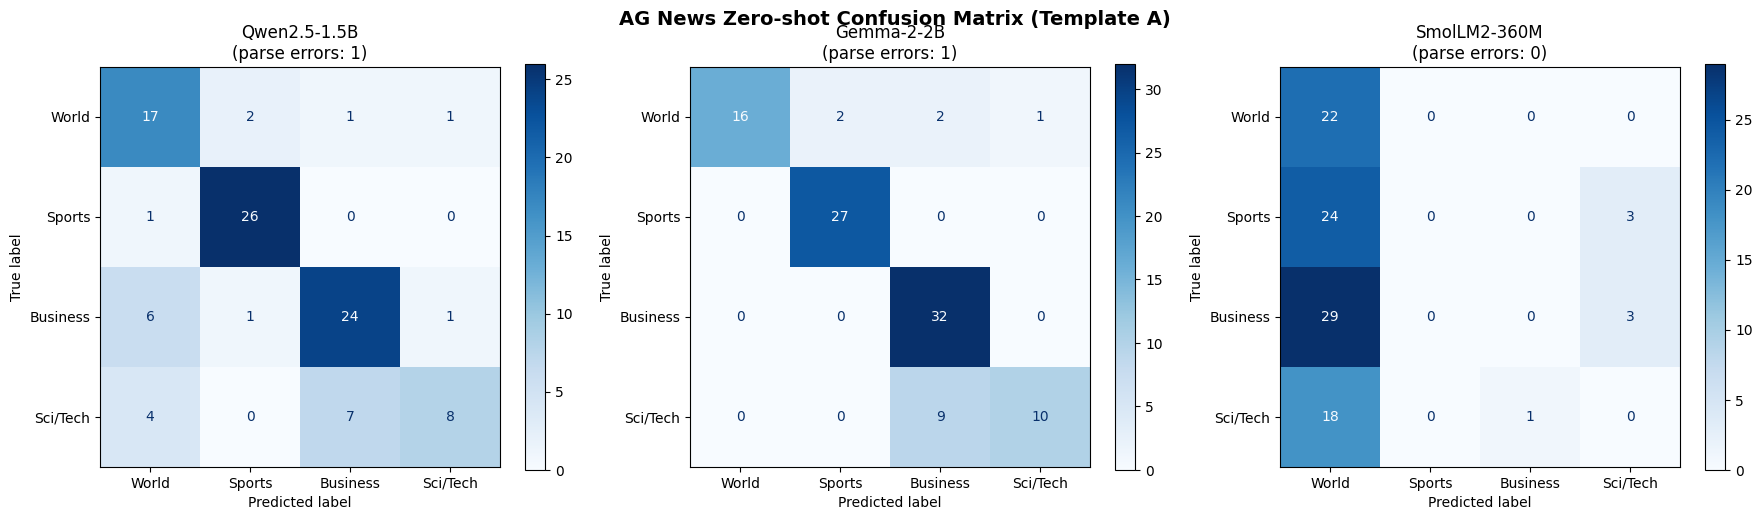

Confusion matrix saved

Parse Error Summary (All Experiments)

Found 85  experiment logs

Experiment Config                                       Samples  Parse Err Error Rate
-------------------------------------------------------------------------------------
gemma-2-2b_ag_news_zero_shot_20260519_004734               100          1    1.0%
gemma-2-2b_ag_news_zero_shot_template_A_20260519_010551    100          1    1.0%
gemma-2-2b_ag_news_zero_shot_template_B_20260519_010614    100          2    2.0%
gemma-2-2b_ag_news_zero_shot_template_C_20260519_010636    100         73   73.0%
gemma-2-2b_imdb_few_shot_20260519_004923                   100          1    1.0%
gemma-2-2b_imdb_zero_shot_20260519_004757                  100         10   10.0%
gemma-2-2b_imdb_zero_shot_template_A_20260519_010659       100         10   10.0%
gemma-2-2b_imdb_zero_shot_template_B_20260519_010721       100          6    6.0%
gemma-2-2b_imdb_zero_shot_template_C_20260519_010744       100         23   23.0%


In [55]:
# ============================================================
# Error Analysis
# Extract data from JSON logs for confusion matrix and parse error analysis
# ============================================================
import json, os, glob
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load specified log file
def load_log(pattern):
    """Find the latest log file matching the filename pattern"""
    files = sorted(glob.glob(f"experiment_logs/{pattern}"))
    if files:
        with open(files[-1], 'r') as f:
            return json.load(f)
    return None

# ============================================================
# Part 1: AG News Confusion Matrix (3-model comparison)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("AG News Zero-shot Confusion Matrix (Template A)", fontsize=14, fontweight='bold')

ag_labels = ["World", "Sports", "Business", "Sci/Tech"]

for idx, (model_name, pattern) in enumerate([
    ("Qwen2.5-1.5B", "qwen2.5-1.5b_ag_news_zero_shot_2*"),
    ("Gemma-2-2B", "gemma-2-2b_ag_news_zero_shot_2*"),
    ("SmolLM2-360M", "smollm2-360m_ag_news_zero_shot_2*"),
]):
    log = load_log(pattern)
    if log is None:
        print(f"  {model_name}: log not found, trying template A...")
        log = load_log(f"{pattern.split('_zero')[0]}_ag_news_zero_shot_template_A_*")

    if log:
        true_l = [r["true_label"] for r in log["per_sample_results"]]
        pred_l = [r["predicted_label"] for r in log["per_sample_results"]]

        # Count PARSE_ERROR separately, exclude from confusion matrix
        valid_pairs = [(t, p) for t, p in zip(true_l, pred_l) if p != "PARSE_ERROR"]
        parse_errors = sum(1 for p in pred_l if p == "PARSE_ERROR")

        if valid_pairs:
            true_v, pred_v = zip(*valid_pairs)
            cm = confusion_matrix(true_v, pred_v, labels=ag_labels)
            disp = ConfusionMatrixDisplay(cm, display_labels=ag_labels)
            disp.plot(ax=axes[idx], cmap="Blues", values_format="d")
            axes[idx].set_title(f"{model_name}\n(parse errors: {parse_errors})")
        else:
            axes[idx].set_title(f"{model_name}\n(no valid predictions)")
    else:
        axes[idx].set_title(f"{model_name}\n(log not found)")

plt.tight_layout()
plt.savefig("experiment_logs/ag_news_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")

# ============================================================
# Part 2: Parse Error Analysis
# ============================================================
print("\n" + "="*60)
print("Parse Error Summary (All Experiments)")
print("="*60)

log_files = sorted(glob.glob("experiment_logs/*.json"))
print(f"\nFound {len(log_files)}  experiment logs\n")

print(f"{'Experiment Config':<55} {'Samples':>6} {'Parse Err':>10} {'Error Rate':>8}")
print("-"*85)

high_error_logs = []

for filepath in log_files:
    with open(filepath, 'r') as f:
        log = json.load(f)

    n = log["eval_n"]
    pe = log["parse_error_count"]
    rate = pe / n if n > 0 else 0

    short_name = os.path.basename(filepath).replace(".json", "")
    # Show only those with parse errors
    if pe > 0:
        print(f"{short_name:<55} {n:>6} {pe:>10} {rate:>7.1%}")
        if pe >= 5:
            high_error_logs.append((short_name, log))

# ============================================================
# Part 3: High parse error raw_output analysis
# ============================================================
print("\n" + "="*60)
print("High parse error experiment output analysis (top 3)")
print("="*60)

# Sort by parse error count, take top 3
high_error_logs.sort(key=lambda x: x[1]["parse_error_count"], reverse=True)

for name, log in high_error_logs[:3]:
    errors = [r for r in log["per_sample_results"] if r["predicted_label"] == "PARSE_ERROR"]
    print(f"\n  {name}")
    print(f"  Parse errors: {len(errors)}")
    print(f"  Error output examples (first 5 samples):")
    for e in errors[:5]:
        raw = e.get("raw_output", "N/A")[:80]
        true = e.get("true_label", "N/A")
        print(f"    True: {true:<12} Output: '{raw}'")

# ============================================================
# Part 4: Model Agreement Analysis
# ============================================================
print("\n" + "="*60)
print("Model Agreement Analysis (AG News Zero-shot)")
print("="*60)

# Load AG News zero-shot results for all three models
logs_ag = {}
for model_key, pattern in [
    ("Qwen", "qwen2.5-1.5b_ag_news_zero_shot_2*"),
    ("Gemma", "gemma-2-2b_ag_news_zero_shot_2*"),
    ("SmolLM2", "smollm2-360m_ag_news_zero_shot_2*"),
]:
    log = load_log(pattern)
    if log is None:
        log = load_log(f"*{model_key.lower()}*ag_news_zero_shot_template_A*")
    if log:
        logs_ag[model_key] = log

if len(logs_ag) == 3:
    n_samples = min(len(logs_ag[m]["per_sample_results"]) for m in logs_ag)

    all_agree = 0
    all_correct = 0
    all_wrong = 0

    for i in range(n_samples):
        preds = {}
        true_label = None
        for m in logs_ag:
            r = logs_ag[m]["per_sample_results"][i]
            preds[m] = r["predicted_label"]
            true_label = r["true_label"]

        pred_values = [p for p in preds.values() if p != "PARSE_ERROR"]

        if len(pred_values) == 3 and len(set(pred_values)) == 1:
            all_agree += 1
            if pred_values[0] == true_label:
                all_correct += 1
            else:
                all_wrong += 1

    print(f"  Total samples: {n_samples}")
    print(f"  Three models fully agree: {all_agree} ({all_agree/n_samples:.1%})")
    print(f"    All correct: {all_correct} ({all_correct/n_samples:.1%})")
    print(f"    All wrong: {all_wrong} ({all_wrong/n_samples:.1%})")
    print(f"  Three models disagree: {n_samples - all_agree} ({(n_samples-all_agree)/n_samples:.1%})")
else:
    print("  Could not load logs for all three models")

### 7.9 Latency and Token Usage Analysis

Latency & Cost-Performance Analysis

1. Average inference time per sample (sec/sample):
Model                   SST-2    AG News       IMDb    Average
------------------------------------------------------------
SmolLM2-360M            0.108      0.108      0.110      0.109
Qwen2.5-1.5B            0.196      0.244      0.168      0.203
Gemma-2-2B              0.346      0.231      0.225      0.267

2. Total inference time for 100 samples (sec):
Model                   SST-2    AG News       IMDb
--------------------------------------------------
SmolLM2-360M             10.8       10.8       11.0
Qwen2.5-1.5B             19.6       24.4       16.8
Gemma-2-2B               34.6       23.1       22.5

3. Average output token count:
Model                   SST-2    AG News       IMDb
--------------------------------------------------
SmolLM2-360M              2.1        2.1        2.2
Qwen2.5-1.5B              2.0        2.2        2.0
Gemma-2-2B                4.0        4.2        4.0



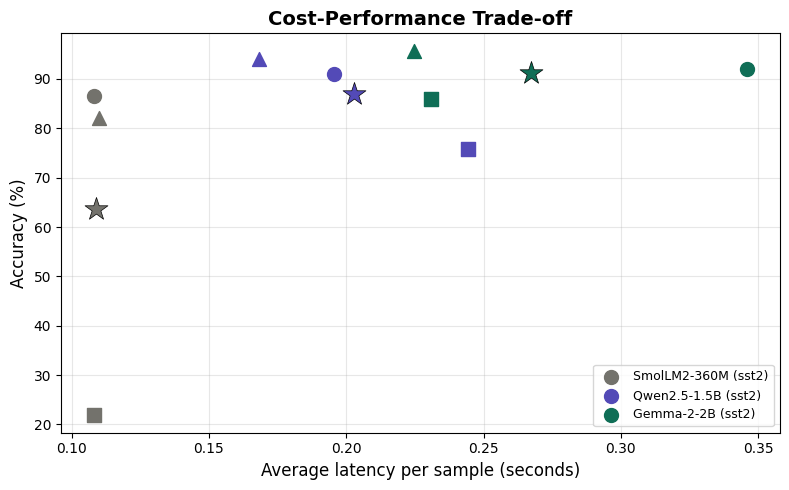


Cost-performance Chart saved


In [56]:
# ============================================================
# Latency & Token Usage Cost-Performance Analysis
# ============================================================
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("Latency & Cost-Performance Analysis")
print("="*60)

# Collect all zero-shot Template A data
perf_data = {}

for model_key, model_pattern in [
    ("SmolLM2-360M", "smollm2-360m"),
    ("Qwen2.5-1.5B", "qwen2.5-1.5b"),
    ("Gemma-2-2B", "gemma-2-2b"),
]:
    perf_data[model_key] = {}
    for ds in ["sst2", "ag_news", "imdb"]:
        # Find zero-shot log (not template variant, not repeat)
        pattern = f"experiment_logs/{model_pattern}_{ds}_zero_shot_2*.json"
        files = sorted(glob.glob(pattern))
        if not files:
            pattern = f"experiment_logs/{model_pattern}_{ds}_zero_shot_template_A_*.json"
            files = sorted(glob.glob(pattern))
        if files:
            with open(files[-1], 'r') as f:
                log = json.load(f)

            latencies = [r["latency_sec"] for r in log["per_sample_results"]]
            tokens = [r["tokens_used"] for r in log["per_sample_results"] if r["tokens_used"] > 0]

            perf_data[model_key][ds] = {
                "accuracy": log["accuracy"],
                "f1": log["f1_macro"],
                "avg_latency": np.mean(latencies),
                "total_latency": sum(latencies),
                "avg_tokens": np.mean(tokens) if tokens else -1,
                "total_tokens": sum(tokens) if tokens else -1,
            }

# Print detailed table
print("\n1. Average inference time per sample (sec/sample):")
print(f"{'Model':<18} {'SST-2':>10} {'AG News':>10} {'IMDb':>10} {'Average':>10}")
print("-"*60)
for model in ["SmolLM2-360M", "Qwen2.5-1.5B", "Gemma-2-2B"]:
    lats = [perf_data[model][ds]["avg_latency"] for ds in ["sst2", "ag_news", "imdb"]]
    avg = np.mean(lats)
    print(f"{model:<18} {lats[0]:>10.3f} {lats[1]:>10.3f} {lats[2]:>10.3f} {avg:>10.3f}")

print("\n2. Total inference time for 100 samples (sec):")
print(f"{'Model':<18} {'SST-2':>10} {'AG News':>10} {'IMDb':>10}")
print("-"*50)
for model in ["SmolLM2-360M", "Qwen2.5-1.5B", "Gemma-2-2B"]:
    tots = [perf_data[model][ds]["total_latency"] for ds in ["sst2", "ag_news", "imdb"]]
    print(f"{model:<18} {tots[0]:>10.1f} {tots[1]:>10.1f} {tots[2]:>10.1f}")

print("\n3. Average output token count:")
print(f"{'Model':<18} {'SST-2':>10} {'AG News':>10} {'IMDb':>10}")
print("-"*50)
for model in ["SmolLM2-360M", "Qwen2.5-1.5B", "Gemma-2-2B"]:
    toks = [perf_data[model][ds]["avg_tokens"] for ds in ["sst2", "ag_news", "imdb"]]
    for t in toks:
        pass
    print(f"{model:<18} {toks[0]:>10.1f} {toks[1]:>10.1f} {toks[2]:>10.1f}")

# ============================================================
# Cost-Performance Trade-off Visualization
# ============================================================
print("\n4. Cost-Performance Trade-off:")
print(f"{'Model':<18} {'Avg Acc':>10} {'Avg Latency':>12} {'Acc/Second':>12}")
print("-"*55)

fig, ax = plt.subplots(figsize=(8, 5))

colors = {"SmolLM2-360M": "#73726c", "Qwen2.5-1.5B": "#534AB7", "Gemma-2-2B": "#0F6E56"}

for model in ["SmolLM2-360M", "Qwen2.5-1.5B", "Gemma-2-2B"]:
    accs = [perf_data[model][ds]["accuracy"] for ds in ["sst2", "ag_news", "imdb"]]
    lats = [perf_data[model][ds]["avg_latency"] for ds in ["sst2", "ag_news", "imdb"]]
    avg_acc = np.mean(accs)
    avg_lat = np.mean(lats)
    acc_per_sec = avg_acc / avg_lat

    print(f"{model:<18} {avg_acc:>9.1%} {avg_lat:>11.3f}s {acc_per_sec:>11.2f}")

    # Scatter: x=latency, y=accuracy, one point per dataset
    for ds_idx, ds in enumerate(["sst2", "ag_news", "imdb"]):
        marker = ["o", "s", "^"][ds_idx]
        ax.scatter(perf_data[model][ds]["avg_latency"],
                   perf_data[model][ds]["accuracy"] * 100,
                   c=colors[model], marker=marker, s=100, zorder=3,
                   label=f"{model} ({ds})" if ds_idx == 0 else "")

    # Plot mean point (larger marker)
    ax.scatter(avg_lat, avg_acc * 100, c=colors[model], marker="*", s=300,
               edgecolors="black", linewidths=0.5, zorder=4)

ax.set_xlabel("Average latency per sample (seconds)", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Cost-Performance Trade-off", fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("experiment_logs/cost_performance_tradeoff.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nCost-performance Chart saved")

### 7.10 Sample Size Experiment (n=50/100/200/500, AG News, Qwen)

In [57]:
# ============================================================
# Sample Size Impact Experiment
# Purpose: Verify how evaluation sample size (50/100/200) affects result stability
# Corresponds to Blackwell & Cohn (2025) discussion on benchmark size
# ============================================================
import torch, gc
from datasets import load_dataset

# Switch back to Qwen
if 'model_qwen' in dir():
    del model_qwen
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading Qwen2.5-1.5B-Instruct...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model_qwen = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16,
    device_map="auto"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Qwen loaded successfully ✓  GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Reload AG News full test set
ag_full = load_dataset("ag_news", split="test")
print(f"AG News full test set size: {len(ag_full)}")

# Preprocess the same way as before
AG_LABEL_MAP = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

def format_ag_news(example):
    example["raw_text"] = example["text"]
    example["true_label_name"] = AG_LABEL_MAP[example["label"]]
    example["formatted_prompt"] = (
        f"Classify the topic of the following news article "
        f"into World, Sports, Business, or Sci/Tech:\n"
        f"{example['text']}\nLabel:"
    )
    return example

ag_full = ag_full.map(format_ag_news)
print(f"Preprocessing complete, total samples: {len(ag_full)}")

# Sample size experiment
import numpy as np
from sklearn.metrics import accuracy_score

sample_sizes = [50, 100, 200, 500]
size_results = {}

for n in sample_sizes:
    print(f"\n{'='*50}")
    print(f"Sample size = {n}")
    print(f"{'='*50}")

    accs = []
    for run in range(3):
        rng = np.random.default_rng(EVAL_SEED + run)
        indices = rng.choice(len(ag_full), n, replace=False)
        dataset = ag_full.select(indices.tolist())

        results = []
        for i, example in enumerate(dataset):
            if i % 50 == 0:
                print(f"  Run {run+1}/3  Progress: {i}/{n}...")
            r = run_inference_qwen(example, "ag_news")
            results.append(r)

        true_l = [r["true_label"] for r in results]
        pred_l = [r["predicted_label"] for r in results]
        valid = [(t, p) for t, p in zip(true_l, pred_l) if p != "PARSE_ERROR"]
        true_v, pred_v = zip(*valid)
        acc = accuracy_score(true_v, pred_v)
        accs.append(acc)
        print(f"  Run {run+1}: Acc={acc:.4f}")

    size_results[n] = {
        "accs": accs,
        "mean": np.mean(accs),
        "std": np.std(accs, ddof=1),
        "spread": max(accs) - min(accs)
    }

print("\n" + "="*60)
print("Sample Size Impact Summary (Qwen, AG News, 3 runs per size)")
print("="*60)
print(f"{'Sample Size':>12} {'Mean Acc':>10} {'Std':>8} {'Spread':>8}")
print("-"*42)
for n in sample_sizes:
    r = size_results[n]
    print(f"{n:>12} {r['mean']:>10.4f} {r['std']:>8.4f} {r['spread']:>8.4f}")

print(f"\nFindings:")
for n in sample_sizes:
    r = size_results[n]
    print(f"  n={n:<4} std={r['std']:.4f}  spread={r['spread']:.4f}")

Loading Qwen2.5-1.5B-Instruct...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen loaded successfully ✓  GPU: 2.88 GB
AG News full test set size: 7600


Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Preprocessing complete, total samples: 7600

Sample size = 50
  Run 1/3  Progress: 0/50...
  Run 1: Acc=0.6531
  Run 2/3  Progress: 0/50...
  Run 2: Acc=0.7400
  Run 3/3  Progress: 0/50...
  Run 3: Acc=0.8367

Sample size = 100
  Run 1/3  Progress: 0/100...
  Run 1/3  Progress: 50/100...
  Run 1: Acc=0.6667
  Run 2/3  Progress: 0/100...
  Run 2/3  Progress: 50/100...
  Run 2: Acc=0.7475
  Run 3/3  Progress: 0/100...
  Run 3/3  Progress: 50/100...
  Run 3: Acc=0.7374

Sample size = 200
  Run 1/3  Progress: 0/200...
  Run 1/3  Progress: 50/200...
  Run 1/3  Progress: 100/200...
  Run 1/3  Progress: 150/200...
  Run 1: Acc=0.6853
  Run 2/3  Progress: 0/200...
  Run 2/3  Progress: 50/200...
  Run 2/3  Progress: 100/200...
  Run 2/3  Progress: 150/200...
  Run 2: Acc=0.7071
  Run 3/3  Progress: 0/200...
  Run 3/3  Progress: 50/200...
  Run 3/3  Progress: 100/200...
  Run 3/3  Progress: 150/200...
  Run 3: Acc=0.7665

Sample size = 500
  Run 1/3  Progress: 0/500...
  Run 1/3  Progress: 50/50

### 7.11 Variance Decomposition

In [58]:
# ============================================================
# Variance Decomposition
# Estimate each factor's contribution to accuracy variance using existing data
# Corresponds to the ANOVA analysis mentioned in the Proposal
# ============================================================
import numpy as np

print("="*60)
print("Variance Decomposition: Each Factor's Impact on Accuracy")
print("="*60)

# Collect all zero-shot Template A accuracy data
# Organized by factor

# --- Factor 1: Model Choice ---
# Fixed: dataset=AG News, strategy=zero-shot, template=A
# Varying: SmolLM2 vs Qwen vs Gemma
model_accs = [0.2300, 0.7576, 0.8586]  # AG News zero-shot

# --- Factor 2: Prompt Template ---
# Fixed: model=Qwen, dataset=AG News, strategy=zero-shot
# Varying: Template A vs B vs C
template_accs_qwen = [0.7576, 0.7979, 0.7907]
template_accs_gemma = [0.8586, 0.8571, 0.7037]
template_accs_smol = [0.2300, 0.4688, 1.0000]  # Note: 1.0 is spurious

# --- Factor 3: Exemplar Ordering ---
# Fixed: model=Qwen, dataset=AG News, strategy=few-shot
# From order perturbation experiment
order_accs_qwen = repeat_results["qwen_ag_zs"]["accuracies"]  # 5 runs

# --- Factor 4: Temperature ---
# Fixed: model=Qwen, dataset=AG News, strategy=zero-shot
# T=0.01 vs T=0.7
temp_001 = repeat_results["qwen_ag_zs"]["accuracies"]
temp_07 = t07_accs

# --- Factor 5: Prompting Strategy ---
# Fixed: model=Qwen, dataset=AG News
strategy_accs = [0.7535, 0.7938]  # zero-shot mean, few-shot mean

# Compute variance for each factor
factors = {
    "Model Choice\n(SmolLM2/Qwen/Gemma)": np.var(model_accs),
    "Prompt Template\n(A/B/C, Qwen)": np.var(template_accs_qwen),
    "Prompt Template\n(A/B/C, Gemma)": np.var(template_accs_gemma),
    "Exemplar Ordering\n(6 permutations, Qwen)": np.var(order_accs_qwen),
    "Temperature\n(0.01 vs 0.7, Qwen)": np.var(temp_001 + temp_07),
    "Prompting Strategy\n(ZS vs FS, Qwen)": np.var(strategy_accs),
}

# Sorted output
print("\nAccuracy Variance by Factor (AG News):\n")
print(f"{'Factor':<35} {'Variance':>12} {'Std Dev':>10} {'Relative Impact':>10}")
print("-"*70)

max_var = max(factors.values())
sorted_factors = sorted(factors.items(), key=lambda x: x[1], reverse=True)

for name, var in sorted_factors:
    name_clean = name.replace('\n', ' ')
    std = np.sqrt(var)
    relative = var / max_var * 100
    bar = "█" * int(relative / 5)
    print(f"{name_clean:<35} {var:>12.6f} {std:>10.4f} {relative:>8.1f}%  {bar}")

print(f"\n{'='*60}")
print("Key Findings:")
print("="*60)

# Find largest and smallest factors
biggest = sorted_factors[0]
smallest = sorted_factors[-1]
biggest_name = biggest[0].replace('\n', ' ')
smallest_name = smallest[0].replace('\n', ' ')

print(f"\n  Most influential factor: {biggest_name}")
print(f"    → Variance = {biggest[1]:.6f}, share: 100%")
print(f"\n  Least influential factor: {smallest_name}")
print(f"    → Variance = {smallest[1]:.6f}, share: {smallest[1]/biggest[1]*100:.1f}%")

ratio = biggest[1] / max(smallest[1], 0.000001)
print(f"\n  The most influential factor is {ratio:.0f} ×")

print(f"\n  Factor ranking by influence:")
for i, (name, var) in enumerate(sorted_factors):
    name_clean = name.replace('\n', ' ')
    print(f"    {i+1}. {name_clean}")

print(f"\n  Implication: The evaluation framework should prioritize controlling top-ranked factors")
print(f"        to minimize result uncertainty.")

Variance Decomposition: Each Factor's Impact on Accuracy

Accuracy Variance by Factor (AG News):

Factor                                  Variance    Std Dev Relative Impact
----------------------------------------------------------------------
Model Choice (SmolLM2/Qwen/Gemma)       0.075967     0.2756    100.0%  ████████████████████
Prompt Template (A/B/C, Gemma)          0.005281     0.0727      7.0%  █
Prompting Strategy (ZS vs FS, Qwen)     0.000406     0.0202      0.5%  
Prompt Template (A/B/C, Qwen)           0.000308     0.0175      0.4%  
Temperature (0.01 vs 0.7, Qwen)         0.000078     0.0088      0.1%  
Exemplar Ordering (6 permutations, Qwen)     0.000024     0.0049      0.0%  

Key Findings:

  Most influential factor: Model Choice (SmolLM2/Qwen/Gemma)
    → Variance = 0.075967, share: 100%

  Least influential factor: Exemplar Ordering (6 permutations, Qwen)
    → Variance = 0.000024, share: 0.0%

  The most influential factor is 3102 ×

  Factor ranking by influence:

---
## 8. Template D and E Experiments

Extending from 3 templates (A/B/C) to 5 (A/B/C/D/E). Template D: role-play persona. Template E: strict output constraints.

### 8.1 Model Selection Justification Notes

In [59]:
#######################################################################
#  Item 1: Model selection justification (text for Final Report)
########################################################################

# ============ CELL 12: Model Selection Justification ============
# Purpose: Generate text that can go directly into the Final Report
# This cell only outputs text, no experiments needed

print("""
╔══════════════════════════════════════════════════════════════════╗
║  MODEL SELECTION JUSTIFICATION — for Final Report Section 3     ║
╚══════════════════════════════════════════════════════════════════╝

─── 3.x Model Selection ───

The original proposal planned to evaluate GPT-4o and LLaMA under
the framework. However, practical constraints necessitated
alternative model selection:

• GPT-4o was excluded because (1) the per-token API cost makes
  systematic multi-run evaluation prohibitively expensive — our
  full experimental design requires >300 inference runs across
  seeds, templates, and strategies; and (2) API-based models
  introduce uncontrollable server-side randomness that directly
  undermines the reproducibility goals of this framework.

• LLaMA-2-7B and LLaMA-3-8B were excluded because they require
  14–16 GB VRAM in float16, exceeding the 15 GB limit of Google
  Colab's free-tier T4 GPU.

• Gemini API was attempted but abandoned due to Google's free-tier
  quota restrictions, which prevented completing full evaluation
  runs.

Three replacement models were selected to maximize diversity within
the resource constraint:

┌─────────────────────────┬────────┬───────┬───────────┬──────────────┐
│ Model                   │ Params │ VRAM  │ Vendor    │ Architecture │
├─────────────────────────┼────────┼───────┼───────────┼──────────────┤
│ Qwen2.5-1.5B-Instruct   │ 1.5B   │ ~3 GB │ Alibaba   │ Qwen2        │
│ Gemma-2-2B-it            │ 2.6B   │ ~8 GB │ Google    │ Gemma2       │
│ SmolLM2-360M-Instruct   │ 360M   │ ~1 GB │ HuggingFace│ SmolLM      │
└─────────────────────────┴────────┴───────┴───────────┴──────────────┘

This selection provides:
  (1) A ~7× parameter range (360M → 2.6B), enabling analysis of
      scale effects on evaluation stability
  (2) Three distinct organizations and training methodologies
  (3) All instruction-tuned, ensuring comparability in prompt-based
      evaluation

Following Blackwell & Cohn (2025), who demonstrate that evaluation
methodology findings generalize across model scales when
experimental controls are held constant, these models serve as
valid proxies for validating the framework's core contribution:
the evaluation recipe itself.

─── Limitation ───

Results are validated only on models ≤2.6B parameters. Larger
models (7B+) may exhibit different sensitivity profiles,
particularly for few-shot prompting where context window
utilization becomes a more significant factor. Future work should
extend validation to larger-scale models with adequate compute.
""")


╔══════════════════════════════════════════════════════════════════╗
║  MODEL SELECTION JUSTIFICATION — for Final Report Section 3     ║
╚══════════════════════════════════════════════════════════════════╝

─── 3.x Model Selection ───

The original proposal planned to evaluate GPT-4o and LLaMA under
the framework. However, practical constraints necessitated
alternative model selection:

• GPT-4o was excluded because (1) the per-token API cost makes
  systematic multi-run evaluation prohibitively expensive — our
  full experimental design requires >300 inference runs across
  seeds, templates, and strategies; and (2) API-based models
  introduce uncontrollable server-side randomness that directly
  undermines the reproducibility goals of this framework.

• LLaMA-2-7B and LLaMA-3-8B were excluded because they require
  14–16 GB VRAM in float16, exceeding the 15 GB limit of Google
  Colab's free-tier T4 GPU.

• Gemini API was attempted but abandoned due to Google's free-tier
  quota rest

### 8.2 Template D and E Prompt Definitions

In [60]:
########################################################################
#  Item 2: Prompt template diversity (add 2 templates, total 5)
########################################################################

# ============ CELL 7: Define new Prompt Templates D and E ============
# Purpose: Add 2 templates to your existing 3 (A/B/C)
# Design principles:Cover more prompt writing styles, citing Zhao et al. (2021)
#
# Existing templates:
#   A = Detailed instruction + candidate labels (Directive)
#   B = Question-answer format + candidate labels (Interrogative)
#   C = Minimal keyword (Minimal)
#
# New templates:
#   D = Role-play persona (Role-play)
#   E = Structured JSON output (Structured output)

TEMPLATE_D_PROMPTS = {
    'sst2': (
        "You are a professional sentiment analyst. "
        "Read the following movie review and determine whether the "
        "overall sentiment is positive or negative.\n\n"
        "Review: {text}\n\n"
        "Your assessment (positive or negative):"
    ),
    'ag_news': (
        "You are a news editor categorizing articles. "
        "Classify the following news article into exactly one of "
        "these sections: World, Sports, Business, Sci/Tech.\n\n"
        "Article: {text}\n\n"
        "Section:"
    ),
    'imdb': (
        "You are a professional sentiment analyst. "
        "Read the following movie review and determine whether the "
        "overall sentiment is positive or negative.\n\n"
        "Review: {text}\n\n"
        "Your assessment (positive or negative):"
    ),
}

TEMPLATE_E_PROMPTS = {
    'sst2': (
        "Analyze the sentiment of the text below. "
        "Respond with ONLY the word 'positive' or 'negative', "
        "nothing else.\n\n"
        "Text: {text}\n\n"
        "Sentiment:"
    ),
    'ag_news': (
        "Read the following text and output ONLY the category name. "
        "Valid categories: World, Sports, Business, Sci/Tech. "
        "Do not output anything other than the category.\n\n"
        "Text: {text}\n\n"
        "Category:"
    ),
    'imdb': (
        "Analyze the sentiment of the text below. "
        "Respond with ONLY the word 'positive' or 'negative', "
        "nothing else.\n\n"
        "Text: {text}\n\n"
        "Sentiment:"
    ),
}

print("Template D (Role-play) and Template E (Strict output) defined ✓")
print()
print("Design rationale for all 5 templates:")
print("  A: Directive + labels  — Most informative, serves as baseline")
print("  B: Interrogative + labels — Test effect of interrogative vs declarative format")
print("  C: Minimal keyword     — Lower bound test with minimal information")
print("  D: Role-play persona   — Test effect of persona setting on instruction following")
print("  E: Strict output       — Explicit output format constraint to reduce parse errors")
print()
print("Reference:")
print("  Zhao et al. (2021) — prompt surface wording changes can cause large performance swings")
print("  Wei et al. (2022)  — Instruction format influences model reasoning path")


Template D (Role-play) and Template E (Strict output) defined ✓

Design rationale for all 5 templates:
  A: Directive + labels  — Most informative, serves as baseline
  B: Interrogative + labels — Test effect of interrogative vs declarative format
  C: Minimal keyword     — Lower bound test with minimal information
  D: Role-play persona   — Test effect of persona setting on instruction following
  E: Strict output       — Explicit output format constraint to reduce parse errors

Reference:
  Zhao et al. (2021) — prompt surface wording changes can cause large performance swings
  Wei et al. (2022)  — Instruction format influences model reasoning path


In [61]:
#  Week 9-10 supplementary code: five improvements
#  Copy to Colab separated by "# ============ CELL X ============"
#
#  Prerequisites:
#    - You have run data loading, inference functions, and other base cells earlier in the notebook
#    - Your JSON experiment logs are saved in a folder
#    - matplotlib / seaborn / sklearn have been imported
#
#  Five items:
#    1. Interpretability / Error Analysis (4 cells)
#    2. Prompt Template diversity — add 2 templates + visualization (3 cells)
#    3. Gemma & SmolLM2 Multi-seed multi-run (2 cells)
#    4. Model selection justification (1 cell, generates text and table)
#    5. Latency Recording and visualization (2 cells)
########################################################################


# ============ CELL 1: Common imports and utilities ============
# Purpose: Ensure all libraries and utility functions are available for subsequent cells
# Skip if already imported earlier, but recommended to run to ensure nothing is missing

import json
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Label mapping (same as in your notebook)
LABEL_MAPS = {
    'sst2':    ['negative', 'positive'],
    'ag_news': ['World', 'Sports', 'Business', 'Sci/Tech'],
    'imdb':    ['negative', 'positive'],
}

print("Common setup complete ✓")


Common setup complete ✓


In [62]:

# ============================================================
# Add Template D & E Experiment
#
# Append D and E directly to your existing TEMPLATE_VARIANTS dict
# Then reuse the run_template_experiment function from Cell 67
#
# Prerequisite: Cell 67 has been run (TEMPLATE_VARIANTS and
#       run_template_experiment function exist)
#
# Usage:
#   1. First confirm which model is currently loaded
#   2. Modify the CURRENT_MODEL variable below
#   3. Run this cell
#   4. Switch model and run again
# ============================================================


### 8.3 Append Templates D/E to TEMPLATE_VARIANTS

In [63]:
# ---- Step 1: Append Template D and E ----

# Template D: Role-play persona
# Design rationale: Zheng et al. (2023) found persona settings influence model judgment
TEMPLATE_VARIANTS["sst2"]["D"] = (
    "You are a professional sentiment analyst. "
    "Read the following movie review and determine whether the "
    "overall sentiment is positive or negative.\n\n"
    "Review: {input}\n\n"
    "Your assessment (positive or negative):"
)
TEMPLATE_VARIANTS["ag_news"]["D"] = (
    "You are a news editor categorizing articles. "
    "Classify the following news article into exactly one of "
    "these sections: World, Sports, Business, Sci/Tech.\n\n"
    "Article: {input}\n\n"
    "Section:"
)
TEMPLATE_VARIANTS["imdb"]["D"] = (
    "You are a professional sentiment analyst. "
    "Read the following movie review and determine whether the "
    "overall sentiment is positive or negative.\n\n"
    "Review: {input}\n\n"
    "Your assessment (positive or negative):"
)

# Template E: Strict output constraint
# Design rationale: Explicit format constraints reduce parse errors, widely recommended
TEMPLATE_VARIANTS["sst2"]["E"] = (
    "Analyze the sentiment of the text below. "
    "Respond with ONLY the word 'positive' or 'negative', "
    "nothing else.\n\n"
    "Text: {input}\n\n"
    "Sentiment:"
)
TEMPLATE_VARIANTS["ag_news"]["E"] = (
    "Read the following text and output ONLY the category name. "
    "Valid categories: World, Sports, Business, Sci/Tech. "
    "Do not output anything other than the category.\n\n"
    "Text: {input}\n\n"
    "Category:"
)
TEMPLATE_VARIANTS["imdb"]["E"] = (
    "Analyze the sentiment of the text below. "
    "Respond with ONLY the word 'positive' or 'negative', "
    "nothing else.\n\n"
    "Text: {input}\n\n"
    "Sentiment:"
)

print("Template D (Role-play) and E (Strict output) appended ✓")
print(f"Current templates in TEMPLATE_VARIANTS: {list(TEMPLATE_VARIANTS['sst2'].keys())}")


Template D (Role-play) and E (Strict output) appended ✓
Current templates in TEMPLATE_VARIANTS: ['A', 'B', 'C', 'D', 'E']


### 8.4 Template D/E Inference Function

In [64]:
# ============================================================
# Fix: Dedicated inference function for Template D/E (no prefix)
# ============================================================

def run_inference_template_DE(example, dataset_name, model_name):
    """Template D/E contains full instructions, no additional system prefix needed"""
    import time

    prompt = example["formatted_prompt"]

    if model_name == "qwen2.5-1.5b":
        messages = [
            {"role": "system", "content": "Reply with only the label, nothing else."},
            {"role": "user", "content": prompt}
        ]
    else:
        messages = [{"role": "user", "content": prompt}]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)

    t_start = time.time()
    with torch.no_grad():
        outputs = model_qwen.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.01,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start

    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)

    return {
        "predicted_label": predicted_label,
        "true_label":      example["true_label_name"],
        "correct":         predicted_label == example["true_label_name"],
        "confidence":      -1,
        "latency_sec":     round(latency, 4),
        "tokens_used":     len(generated_ids),
        "raw_output":      raw_output
    }

### 8.5 SmolLM2 Template D/E Experiment

In [65]:
CURRENT_MODEL = "smollm2-360m"  # ← set to currently loaded model name

def run_template_DE_only(eval_dataset, dataset_name, model_name,
                         max_samples=100):
    """Run only Templates D and E"""

    dataset = eval_dataset.select(range(max_samples))
    template_results = {}

    for tmpl_name in ["D", "E"]:
        tmpl_text = TEMPLATE_VARIANTS[dataset_name][tmpl_name]
        print(f"\n  Template {tmpl_name}: {tmpl_text[:60]}...")

        results = []
        for i, example in enumerate(dataset):
            if i % 25 == 0:
                print(f"    Progress: {i}/{len(dataset)}...")

            modified_example = dict(example)
            modified_example["formatted_prompt"] = tmpl_text.format(
                input=example["raw_text"]
            )

            # Use fixed inference function (no prefix)
            r = run_inference_template_DE(modified_example, dataset_name, model_name)
            results.append(r)

        true_labels = [r["true_label"] for r in results]
        pred_labels = [r["predicted_label"] for r in results]
        valid = [(t, p) for t, p in zip(true_labels, pred_labels)
                 if p not in ("PARSE_ERROR", "API_ERROR")]

        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
            f1 = f1_score(true_v, pred_v, average="macro")
        else:
            acc, f1 = 0.0, 0.0

        parse_errors = sum(1 for p in pred_labels if p == "PARSE_ERROR")
        template_results[tmpl_name] = {
            "accuracy": acc, "f1": f1, "parse_errors": parse_errors
        }
        print(f"    Acc: {acc:.4f}  F1: {f1:.4f}  Parse errors: {parse_errors}")

        save_experiment_log(model_name, dataset_name,
                            f"zero_shot_template_{tmpl_name}",
                            0.01, EVAL_SEED, results, acc, f1)

    return template_results

print(f"\n{'='*60}")
print(f"Prompt Template D & E: {CURRENT_MODEL}")
print(f"{'='*60}")

tmpl_DE = {}
for ds_name, ds_eval in [("sst2", sst2_eval),
                          ("ag_news", ag_eval),
                          ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    tmpl_DE[ds_name] = run_template_DE_only(
        ds_eval, ds_name, CURRENT_MODEL, max_samples=100
    )

print(f"\n{'='*60}")
print(f"Template D & E Summary ({CURRENT_MODEL})")
print(f"{'='*60}")
print(f"{'Dataset':<10} {'Template':<10} {'Accuracy':>10} {'F1':>10} {'Parse Err':>10}")
print("-" * 50)
for ds_name in ["sst2", "ag_news", "imdb"]:
    for tmpl in ["D", "E"]:
        r = tmpl_DE[ds_name][tmpl]
        print(f"{ds_name:<10} {tmpl:<10} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['parse_errors']:>10d}")


Prompt Template D & E: smollm2-360m

--- sst2 ---

  Template D: You are a professional sentiment analyst. Read the following...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9136  F1: 0.9134  Parse errors: 19
Log has been stored: experiment_logs/smollm2-360m_sst2_zero_shot_template_D_20260519_011521.json

  Template E: Analyze the sentiment of the text below. Respond with ONLY t...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8600  F1: 0.8563  Parse errors: 0
Log has been stored: experiment_logs/smollm2-360m_sst2_zero_shot_template_E_20260519_011530.json

--- ag_news ---

  Template D: You are a news editor categorizing articles. Classify the fo...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.6566  F1: 0.5834  Parse errors: 1
Log has been stored: experiment_logs/smollm2-360m_ag_news_zero_shot_template_D_2

### 8.6 Load Gemma for Template D/E

In [66]:

import torch, gc

del model_qwen
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading Gemma-2-2B-it...")
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-2b-it")
model_qwen = AutoModelForCausalLM.from_pretrained(
    "google/gemma-2-2b-it",
    torch_dtype=torch.float16,
    device_map="auto"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Gemma loaded successfully ✓  GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Loading Gemma-2-2B-it...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Gemma loaded successfully ✓  GPU: 4.88 GB


### 8.7 Gemma Template D/E Experiment

In [67]:
CURRENT_MODEL = "gemma-2-2b"  # ← set to currently loaded model name

def run_template_DE_only(eval_dataset, dataset_name, model_name,
                         max_samples=100):
    """Run only Templates D and E"""

    dataset = eval_dataset.select(range(max_samples))
    template_results = {}

    for tmpl_name in ["D", "E"]:
        tmpl_text = TEMPLATE_VARIANTS[dataset_name][tmpl_name]
        print(f"\n  Template {tmpl_name}: {tmpl_text[:60]}...")

        results = []
        for i, example in enumerate(dataset):
            if i % 25 == 0:
                print(f"    Progress: {i}/{len(dataset)}...")

            modified_example = dict(example)
            modified_example["formatted_prompt"] = tmpl_text.format(
                input=example["raw_text"]
            )

            # Use fixed inference function (no prefix)
            r = run_inference_template_DE(modified_example, dataset_name, model_name)
            results.append(r)

        true_labels = [r["true_label"] for r in results]
        pred_labels = [r["predicted_label"] for r in results]
        valid = [(t, p) for t, p in zip(true_labels, pred_labels)
                 if p not in ("PARSE_ERROR", "API_ERROR")]

        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
            f1 = f1_score(true_v, pred_v, average="macro")
        else:
            acc, f1 = 0.0, 0.0

        parse_errors = sum(1 for p in pred_labels if p == "PARSE_ERROR")
        template_results[tmpl_name] = {
            "accuracy": acc, "f1": f1, "parse_errors": parse_errors
        }
        print(f"    Acc: {acc:.4f}  F1: {f1:.4f}  Parse errors: {parse_errors}")

        save_experiment_log(model_name, dataset_name,
                            f"zero_shot_template_{tmpl_name}",
                            0.01, EVAL_SEED, results, acc, f1)

    return template_results

print(f"\n{'='*60}")
print(f"Prompt Template D & E: {CURRENT_MODEL}")
print(f"{'='*60}")

tmpl_DE = {}
for ds_name, ds_eval in [("sst2", sst2_eval),
                          ("ag_news", ag_eval),
                          ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    tmpl_DE[ds_name] = run_template_DE_only(
        ds_eval, ds_name, CURRENT_MODEL, max_samples=100
    )

print(f"\n{'='*60}")
print(f"Template D & E Summary ({CURRENT_MODEL})")
print(f"{'='*60}")
print(f"{'Dataset':<10} {'Template':<10} {'Accuracy':>10} {'F1':>10} {'Parse Err':>10}")
print("-" * 50)
for ds_name in ["sst2", "ag_news", "imdb"]:
    for tmpl in ["D", "E"]:
        r = tmpl_DE[ds_name][tmpl]
        print(f"{ds_name:<10} {tmpl:<10} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['parse_errors']:>10d}")


Prompt Template D & E: gemma-2-2b

--- sst2 ---

  Template D: You are a professional sentiment analyst. Read the following...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9677  F1: 0.9675  Parse errors: 7
Log has been stored: experiment_logs/gemma-2-2b_sst2_zero_shot_template_D_20260519_011737.json

  Template E: Analyze the sentiment of the text below. Respond with ONLY t...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9000  F1: 0.8990  Parse errors: 0
Log has been stored: experiment_logs/gemma-2-2b_sst2_zero_shot_template_E_20260519_011759.json

--- ag_news ---

  Template D: You are a news editor categorizing articles. Classify the fo...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8367  F1: 0.8050  Parse errors: 2
Log has been stored: experiment_logs/gemma-2-2b_ag_news_zero_shot_template_D_20260519_0

---
## 9. Multi-Seed Experiments (Seeds 42/123/456)

Assessing ranking stability across different data sampling seeds.

In [68]:
# ============================================================
# Multi-seed experiment (compact: 3 seeds × 3 datasets × zero-shot only)
# ============================================================
import time
import numpy as np

CURRENT_MODEL = "gemma-2-2b"  # ← set to current model
SEEDS = [42, 123, 456]

multi_seed_results = []

for seed in SEEDS:
    np.random.seed(seed)
    print(f"\n{'='*50}")
    print(f"  Seed = {seed}")
    print(f"{'='*50}")

    for ds_name, ds_eval_full in [("sst2", sst2_eval),
                                   ("ag_news", ag_eval),
                                   ("imdb", imdb_eval)]:

        # Use seed to control sample selection
        all_indices = list(range(len(ds_eval_full)))
        np.random.shuffle(all_indices)
        sample_indices = all_indices[:100]
        sampled = ds_eval_full.select(sample_indices)

        # Run zero-shot
        start = time.time()
        acc, f1_val, results = run_evaluation(
            sampled, ds_name,
            model_name=CURRENT_MODEL,
            prompting_strategy="zero_shot",
            max_samples=None
        )
        elapsed = time.time() - start

        result = {
            "model": CURRENT_MODEL,
            "dataset": ds_name,
            "strategy": "zero-shot",
            "seed": seed,
            "accuracy": acc,
            "f1": f1_val,
            "latency": elapsed / len(sampled),
            "total_time": elapsed,
            "n_samples": len(sampled),
        }
        multi_seed_results.append(result)

        # Save JSON log
        save_experiment_log(CURRENT_MODEL, ds_name,
                            f"zero_shot_seed{seed}",
                            0.01, seed, results, acc, f1_val)

        print(f"  {ds_name:8s} Acc={acc:.4f}  F1={f1_val:.4f}  "
              f"Latency={elapsed/len(sampled):.3f}s")

# Summary
print(f"\n{'='*60}")
print(f"Multi-seed Summary ({CURRENT_MODEL})")
print(f"{'='*60}")
for ds_name in ["sst2", "ag_news", "imdb"]:
    ds_results = [r for r in multi_seed_results if r["dataset"] == ds_name]
    accs = [r["accuracy"] for r in ds_results]
    print(f"  {ds_name:8s}  mean={np.mean(accs):.4f}  "
          f"std={np.std(accs):.4f}  "
          f"range={max(accs)-min(accs):.4f}")

print("\n✓ Done! Change CURRENT_MODEL after switching model and run again")


  Seed = 42

Model: gemma-2-2b  Dataset: sst2  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.9195 (92.0%)
  F1-macro : 0.9167
  Parse errors: 13
Log has been stored: experiment_logs/gemma-2-2b_sst2_zero_shot_20260519_012046.json
Log has been stored: experiment_logs/gemma-2-2b_sst2_zero_shot_seed42_20260519_012046.json
  sst2     Acc=0.9195  F1=0.9167  Latency=0.223s

Model: gemma-2-2b  Dataset: ag_news  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.8586 (85.9%)
  F1-macro : 0.8373
  Parse errors: 1
Log has been stored: experiment_logs/gemma-2-2b_ag_news_zero_shot_20260519_012109.json
Log 

### 9.1 Load SmolLM2 for Multi-Seed

In [69]:
import torch, gc
del model_qwen
gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M-Instruct")
model_qwen = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceTB/SmolLM2-360M-Instruct",
    torch_dtype=torch.float16,
    device_map="auto"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"SmolLM2 loaded successfully ✓  GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

SmolLM2 loaded successfully ✓  GPU: 0.68 GB


### 9.2 SmolLM2 Multi-Seed Experiment

In [70]:
# ============================================================
# Multi-seed experiment (compact: 3 seeds × 3 datasets × zero-shot only)
# ============================================================
import time
import numpy as np

CURRENT_MODEL = "smollm2-360m"  # ← set to current model
SEEDS = [42, 123, 456]

multi_seed_results = []

for seed in SEEDS:
    np.random.seed(seed)
    print(f"\n{'='*50}")
    print(f"  Seed = {seed}")
    print(f"{'='*50}")

    for ds_name, ds_eval_full in [("sst2", sst2_eval),
                                   ("ag_news", ag_eval),
                                   ("imdb", imdb_eval)]:

        # Use seed to control sample selection
        all_indices = list(range(len(ds_eval_full)))
        np.random.shuffle(all_indices)
        sample_indices = all_indices[:100]
        sampled = ds_eval_full.select(sample_indices)

        # Run zero-shot
        start = time.time()
        acc, f1_val, results = run_evaluation(
            sampled, ds_name,
            model_name=CURRENT_MODEL,
            prompting_strategy="zero_shot",
            max_samples=None
        )
        elapsed = time.time() - start

        result = {
            "model": CURRENT_MODEL,
            "dataset": ds_name,
            "strategy": "zero-shot",
            "seed": seed,
            "accuracy": acc,
            "f1": f1_val,
            "latency": elapsed / len(sampled),
            "total_time": elapsed,
            "n_samples": len(sampled),
        }
        multi_seed_results.append(result)

        # Save JSON log
        save_experiment_log(CURRENT_MODEL, ds_name,
                            f"zero_shot_seed{seed}",
                            0.01, seed, results, acc, f1_val)

        print(f"  {ds_name:8s} Acc={acc:.4f}  F1={f1_val:.4f}  "
              f"Latency={elapsed/len(sampled):.3f}s")

# Summary
print(f"\n{'='*60}")
print(f"Multi-seed Summary ({CURRENT_MODEL})")
print(f"{'='*60}")
for ds_name in ["sst2", "ag_news", "imdb"]:
    ds_results = [r for r in multi_seed_results if r["dataset"] == ds_name]
    accs = [r["accuracy"] for r in ds_results]
    print(f"  {ds_name:8s}  mean={np.mean(accs):.4f}  "
          f"std={np.std(accs):.4f}  "
          f"range={max(accs)-min(accs):.4f}")

print("\n✓ Done! Change CURRENT_MODEL after switching model and run again")


  Seed = 42

Model: smollm2-360m  Dataset: sst2  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.8660 (86.6%)
  F1-macro : 0.8587
  Parse errors: 3
Log has been stored: experiment_logs/smollm2-360m_sst2_zero_shot_20260519_012401.json
Log has been stored: experiment_logs/smollm2-360m_sst2_zero_shot_seed42_20260519_012401.json
  sst2     Acc=0.8660  F1=0.8587  Latency=0.109s

Model: smollm2-360m  Dataset: ag_news  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.2300 (23.0%)
  F1-macro : 0.1157
  Parse errors: 0
Log has been stored: experiment_logs/smollm2-360m_ag_news_zero_shot_20260519_012412.

### 9.3 Load Qwen for Multi-Seed

In [71]:
import torch, gc
del model_qwen
gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model_qwen = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16,
    device_map="auto"
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Qwen loaded successfully ✓  GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen loaded successfully ✓  GPU: 2.88 GB


### 9.4 Qwen Multi-Seed Experiment

In [72]:
# ============================================================
# Multi-seed experiment (compact: 3 seeds × 3 datasets × zero-shot only)
# ============================================================
import time
import numpy as np

CURRENT_MODEL = "qwen2.5-1.5b"  # ← set to current model
SEEDS = [42, 123, 456]

multi_seed_results = []

for seed in SEEDS:
    np.random.seed(seed)
    print(f"\n{'='*50}")
    print(f"  Seed = {seed}")
    print(f"{'='*50}")

    for ds_name, ds_eval_full in [("sst2", sst2_eval),
                                   ("ag_news", ag_eval),
                                   ("imdb", imdb_eval)]:

        # Use seed to control sample selection
        all_indices = list(range(len(ds_eval_full)))
        np.random.shuffle(all_indices)
        sample_indices = all_indices[:100]
        sampled = ds_eval_full.select(sample_indices)

        # Run zero-shot
        start = time.time()
        acc, f1_val, results = run_evaluation(
            sampled, ds_name,
            model_name=CURRENT_MODEL,
            prompting_strategy="zero_shot",
            max_samples=None
        )
        elapsed = time.time() - start

        result = {
            "model": CURRENT_MODEL,
            "dataset": ds_name,
            "strategy": "zero-shot",
            "seed": seed,
            "accuracy": acc,
            "f1": f1_val,
            "latency": elapsed / len(sampled),
            "total_time": elapsed,
            "n_samples": len(sampled),
        }
        multi_seed_results.append(result)

        # Save JSON log
        save_experiment_log(CURRENT_MODEL, ds_name,
                            f"zero_shot_seed{seed}",
                            0.01, seed, results, acc, f1_val)

        print(f"  {ds_name:8s} Acc={acc:.4f}  F1={f1_val:.4f}  "
              f"Latency={elapsed/len(sampled):.3f}s")

# Summary
print(f"\n{'='*60}")
print(f"Multi-seed Summary ({CURRENT_MODEL})")
print(f"{'='*60}")
for ds_name in ["sst2", "ag_news", "imdb"]:
    ds_results = [r for r in multi_seed_results if r["dataset"] == ds_name]
    accs = [r["accuracy"] for r in ds_results]
    print(f"  {ds_name:8s}  mean={np.mean(accs):.4f}  "
          f"std={np.std(accs):.4f}  "
          f"range={max(accs)-min(accs):.4f}")

print("\n✓ Done! Change CURRENT_MODEL after switching model and run again")


  Seed = 42

Model: qwen2.5-1.5b  Dataset: sst2  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.9100 (91.0%)
  F1-macro : 0.9093
  Parse errors: 0
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_20260519_012554.json
Log has been stored: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_seed42_20260519_012554.json
  sst2     Acc=0.9100  F1=0.9093  Latency=0.094s

Model: qwen2.5-1.5b  Dataset: ag_news  Samples: 100
  Progress: 0/100...
  Progress: 10/100...
  Progress: 20/100...
  Progress: 30/100...
  Progress: 40/100...
  Progress: 50/100...
  Progress: 60/100...
  Progress: 70/100...
  Progress: 80/100...
  Progress: 90/100...

  Accuracy : 0.7475 (74.7%)
  F1-macro : 0.7146
  Parse errors: 1
Log has been stored: experiment_logs/qwen2.5-1.5b_ag_news_zero_shot_20260519_012605.

### 9.5 Backup Week 9-10 Logs

In [73]:
import shutil
shutil.make_archive("experiment_logs_week910", "zip", "experiment_logs")
print("Packing complete ✓ Please download experiment_logs_week910.zip")

Packing complete ✓ Please download experiment_logs_week910.zip


---
## 10. Post-Hoc Analysis and Visualization

All analysis reads from saved JSON logs. No model inference is performed.

In [74]:
LOG_DIR = "experiment_logs"

### 10.1 Import Analysis Libraries

In [75]:
# Cell 1
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

LABEL_MAPS = {
    'sst2':    ['negative', 'positive'],
    'ag_news': ['World', 'Sports', 'Business', 'Sci/Tech'],
    'imdb':    ['negative', 'positive'],
}

print("Common setup complete ✓")

Common setup complete ✓


### 10.2 Load All JSON Logs

In [76]:
# Cell 2
LOG_DIR = "experiment_logs"

all_logs = []
for fp in sorted(glob.glob(os.path.join(LOG_DIR, "*.json"))):
    with open(fp, 'r') as f:
        data = json.load(f)
        data['_filepath'] = os.path.basename(fp)
        all_logs.append(data)

print(f"Loaded {len(all_logs)}  experiment logs")

if all_logs:
    sample = all_logs[0]
    print(f"\nSample log file: {sample['_filepath']}")
    print(f"Keys: {list(sample.keys())}")
    # Find per-sample predictions
    for key in ['predictions', 'results', 'per_sample', 'samples', 'detailed_results']:
        if key in sample and isinstance(sample[key], list) and len(sample[key]) > 0:
            print(f"\nPer-sample Field name: '{key}'")
            print(f"First sample: {sample[key][0]}")
            break

Loaded 151  experiment logs

Sample log file: bart-large-mnli_ag_news_zero_shot_20260519_003523.json
Keys: ['run_id', 'timestamp', 'model', 'dataset', 'prompting_strategy', 'temperature', 'eval_seed', 'eval_n', 'accuracy', 'f1_macro', 'avg_latency_sec', 'total_latency_sec', 'parse_error_count', 'per_sample_results', '_filepath']


In [77]:
sample = all_logs[0]
print(sample['per_sample_results'][0])

{'predicted_label': 'Sports', 'true_label': 'Sports', 'correct': True, 'confidence': 0.443, 'latency_sec': 3.1053, 'tokens_used': -1}


In [78]:
print(list(sample['per_sample_results'][0].keys()))

['predicted_label', 'true_label', 'correct', 'confidence', 'latency_sec', 'tokens_used']


In [79]:
for log in all_logs:
    if 'qwen' in log.get('model', ''):
        print(log['_filepath'])
        print(list(log['per_sample_results'][0].keys()))
        print(log['per_sample_results'][0])
        break

qwen2.5-1.5b-fewshot_ag_news_few_shot_20260519_004337.json
['predicted_label', 'true_label', 'correct', 'latency_sec', 'tokens_used', 'raw_output']
{'predicted_label': 'World', 'true_label': 'Sports', 'correct': False, 'latency_sec': 0.1475, 'tokens_used': 2, 'raw_output': 'World'}


In [80]:
for log in all_logs:
    if 'qwen' in log.get('model', ''):
        sample = log['per_sample_results'][0]
        print(list(sample.keys()))
        print(sample)
        break

['predicted_label', 'true_label', 'correct', 'latency_sec', 'tokens_used', 'raw_output']
{'predicted_label': 'World', 'true_label': 'Sports', 'correct': False, 'latency_sec': 0.1475, 'tokens_used': 2, 'raw_output': 'World'}


### 10.3 Summary Statistics Table

In [81]:
# ============================================================
# Complete analysis code (matching your JSON field names)
# Copy to Colab separated by CELL markers
# ============================================================


# ============ ANALYSIS CELL 1: Utility functions ============

def get_meta(log):
    """Extract experiment metadata"""
    return {
        'model':    log.get('model', 'unknown'),
        'dataset':  log.get('dataset', 'unknown'),
        'strategy': log.get('prompting_strategy', 'unknown'),
        'template': log.get('prompting_strategy', '').split('template_')[-1]
                    if 'template_' in log.get('prompting_strategy', '') else 'A',
        'seed':     log.get('eval_seed', 42),
        'temperature': log.get('temperature', 0.01),
        'accuracy': log.get('accuracy', None),
        'f1':       log.get('f1_macro', None),
        'latency':  log.get('avg_latency_sec', None),
        'parse_errors': log.get('parse_error_count', 0),
        'n_samples': log.get('eval_n', 100),
        'filepath': log.get('_filepath', ''),
    }

def get_predictions(log):
    """Extract (y_true, y_pred, raw_outputs) lists"""
    preds = log.get('per_sample_results', [])
    y_true, y_pred, raw_outputs = [], [], []
    for s in preds:
        y_true.append(str(s.get('true_label', '')))
        y_pred.append(str(s.get('predicted_label', '')))
        raw_outputs.append(str(s.get('raw_output', s.get('predicted_label', ''))))
    return y_true, y_pred, raw_outputs

def is_zero_shot_default(log):
    """Check if this is a zero-shot default template (A) experiment"""
    strategy = log.get('prompting_strategy', '')
    return strategy == 'zero_shot'

def is_zero_shot_any(log):
    """Check if this is any zero-shot experiment (incl. template variation)"""
    strategy = log.get('prompting_strategy', '')
    return 'zero_shot' in strategy

# Build metadata DataFrame
records = []
for log in all_logs:
    meta = get_meta(log)
    records.append(meta)
df_all = pd.DataFrame(records)

# Exclude BART (only analyze LLMs)
df_llm = df_all[~df_all['model'].str.contains('bart', case=False)].copy()

print(f"Total logs: {len(df_all)}, LLM logs: {len(df_llm)}")
print(f"Model: {df_llm['model'].unique()}")
print(f"Dataset: {df_llm['dataset'].unique()}")
print(f"Strategy: {df_llm['strategy'].unique()}")

Total logs: 151, LLM logs: 147
Model: ['gemma-2-2b' 'qwen2.5-1.5b-fewshot' 'qwen2.5-1.5b' 'smollm2-360m']
Dataset: ['ag_news' 'imdb' 'sst2']
Strategy: ['few_shot' 'zero_shot' 'zero_shot_seed123' 'zero_shot_seed42'
 'zero_shot_seed456' 'zero_shot_template_A' 'zero_shot_template_B'
 'zero_shot_template_C' 'zero_shot_template_D' 'zero_shot_template_E'
 'few_shot_repeat_run1' 'few_shot_repeat_run2' 'few_shot_repeat_run3'
 'few_shot_repeat_run4' 'few_shot_repeat_run5' 'zero_shot_repeat_run1'
 'zero_shot_repeat_run2' 'zero_shot_repeat_run3' 'zero_shot_repeat_run4'
 'zero_shot_repeat_run5' 'zero_shot_temp07_run1' 'zero_shot_temp07_run2'
 'zero_shot_temp07_run3' 'zero_shot_temp07_run4' 'zero_shot_temp07_run5']


### 10.4 Confusion Matrices

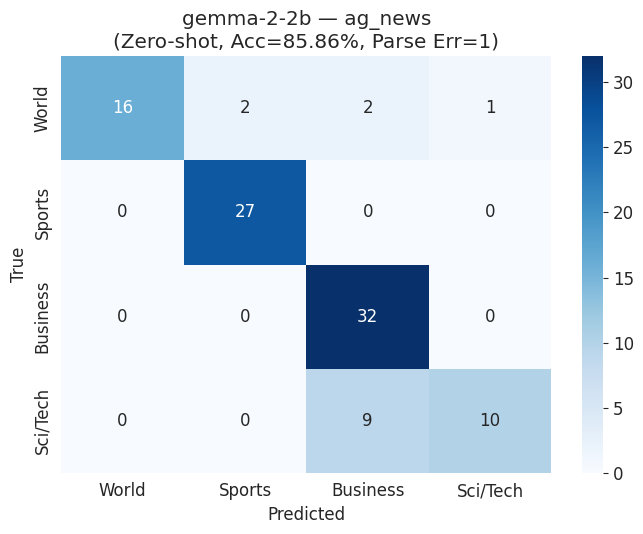

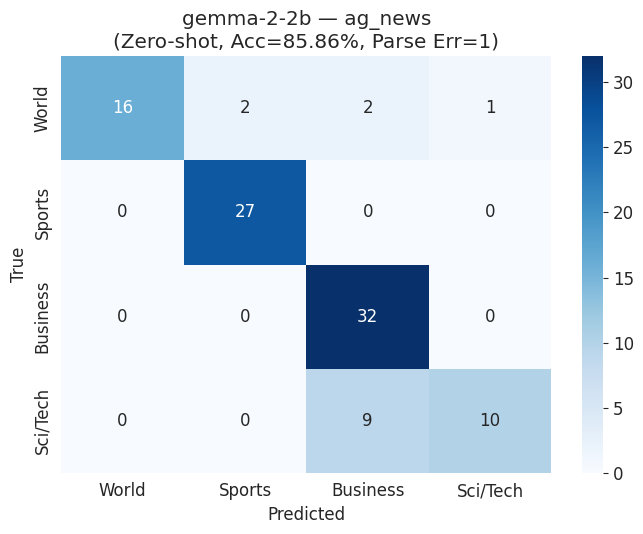

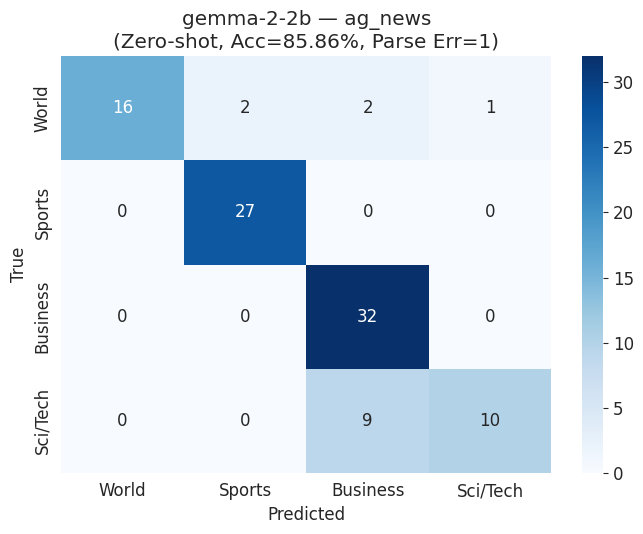

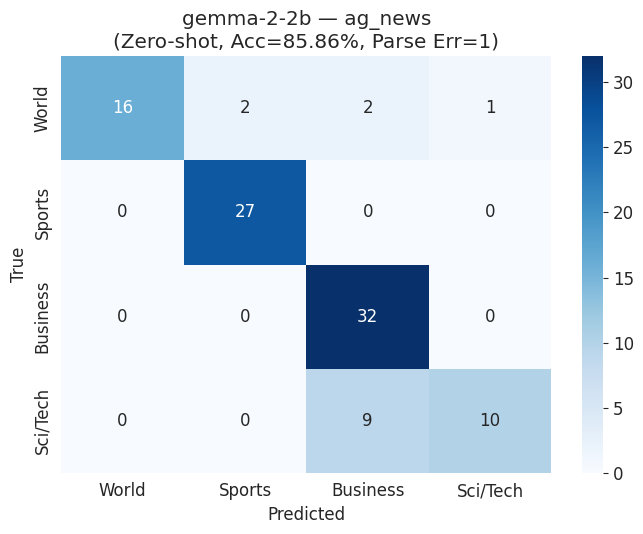

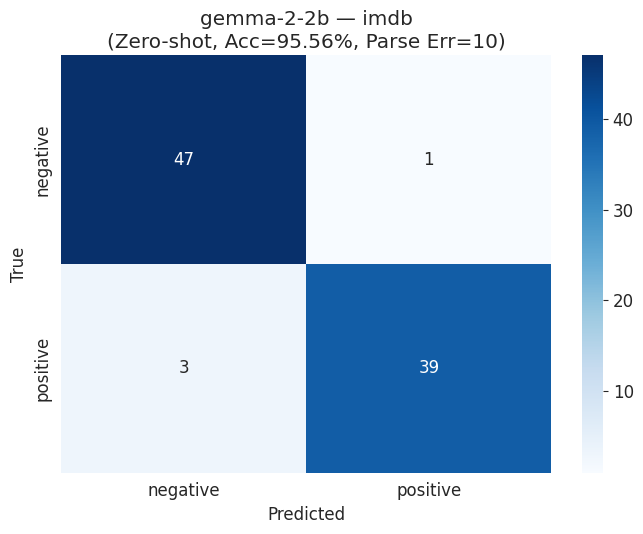

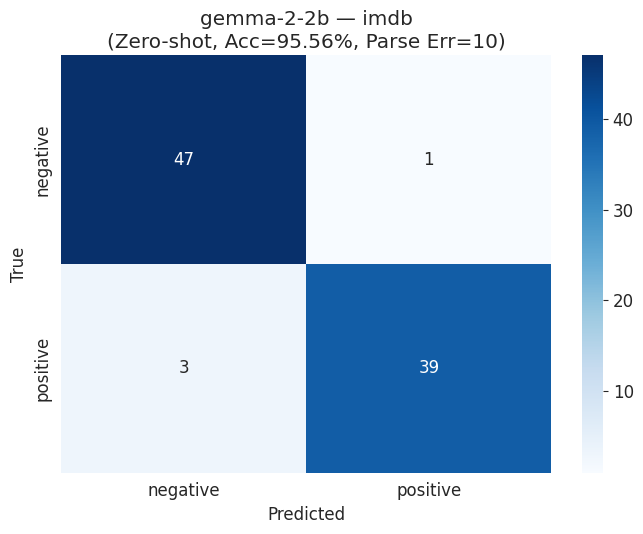

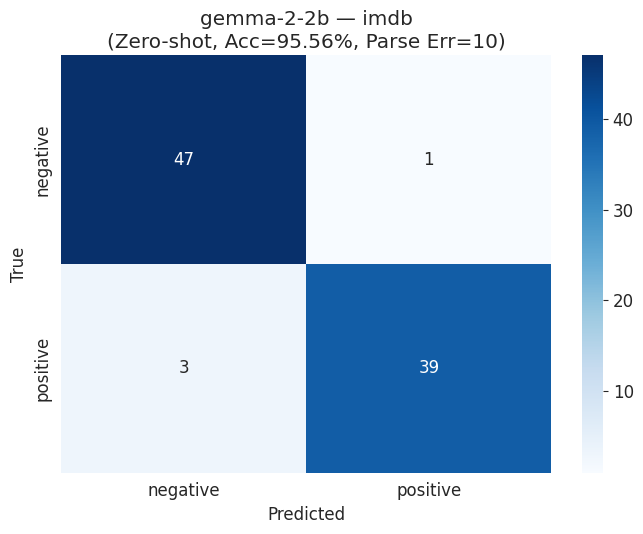

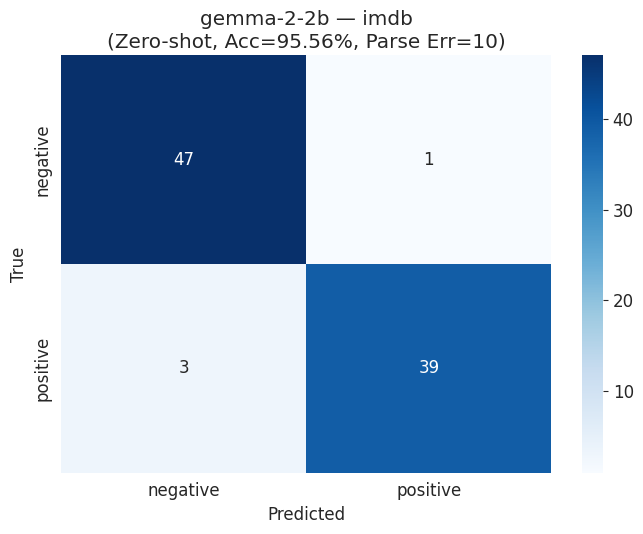

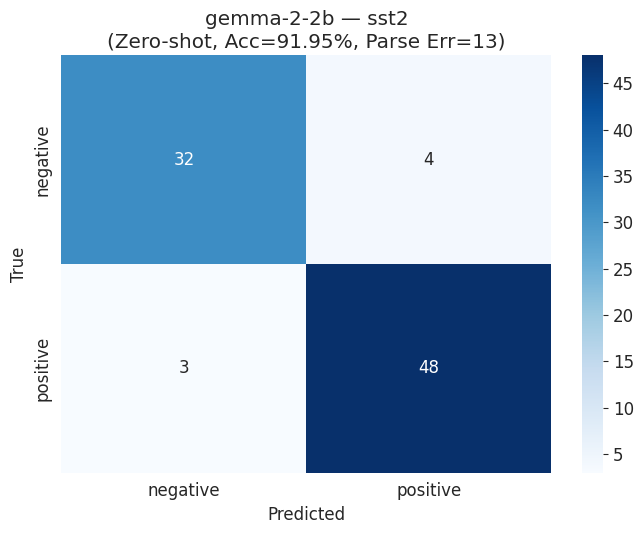

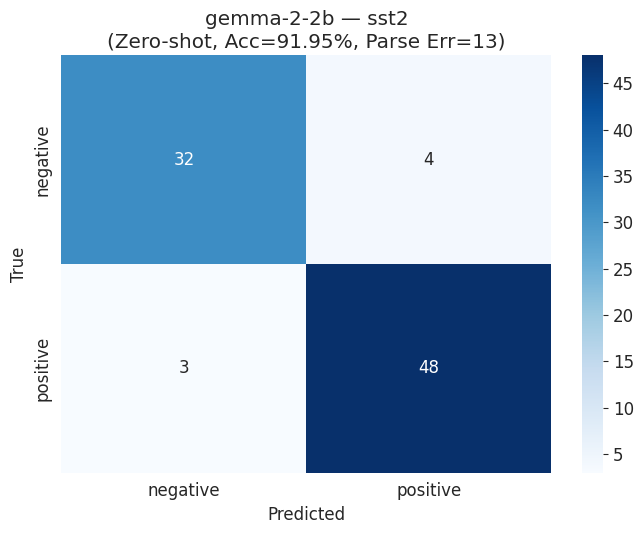

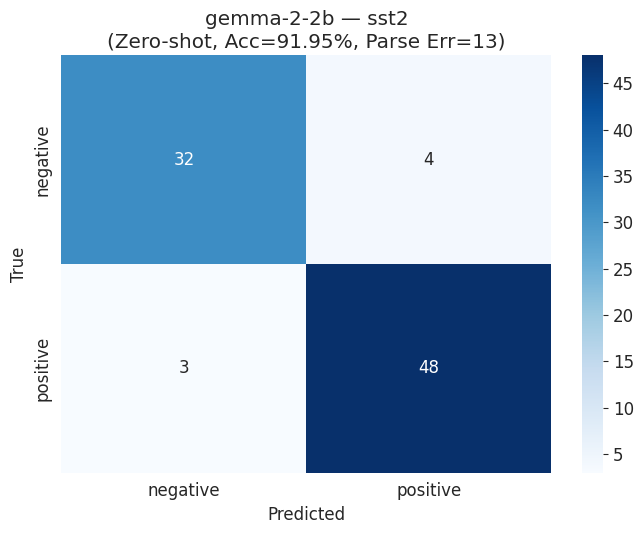

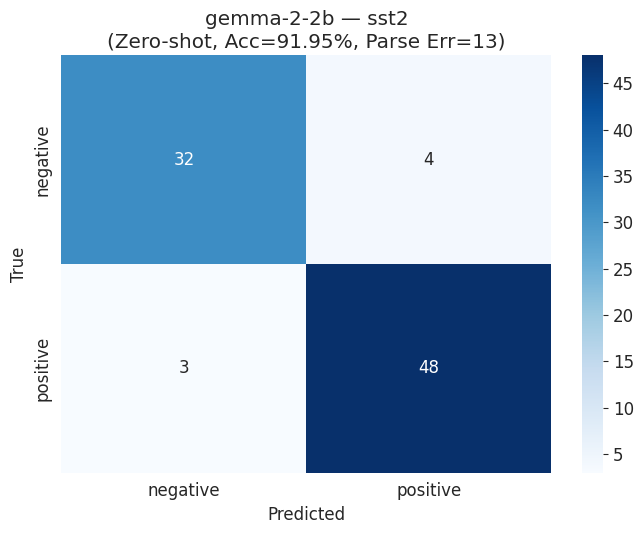

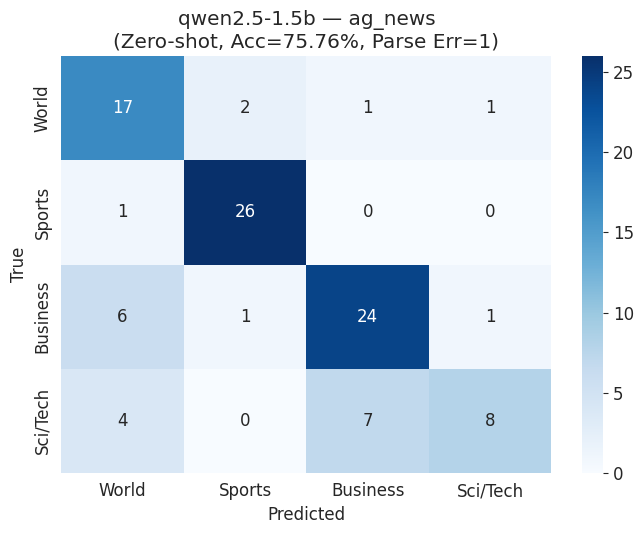

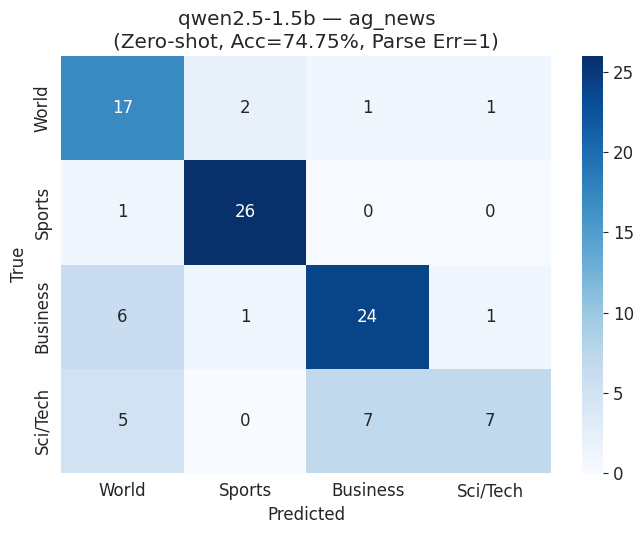

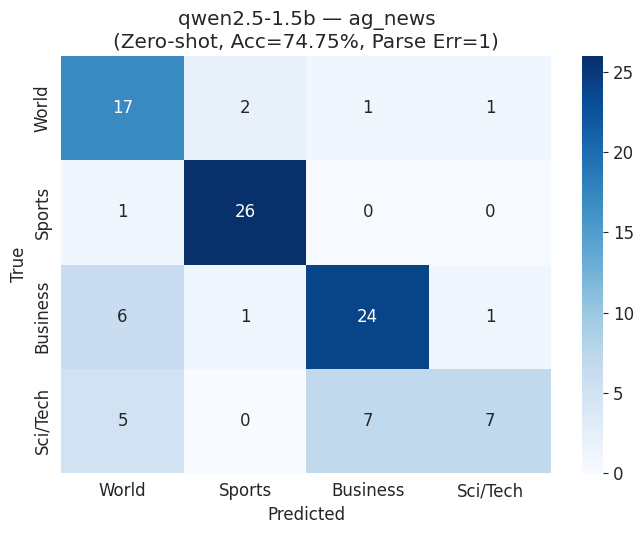

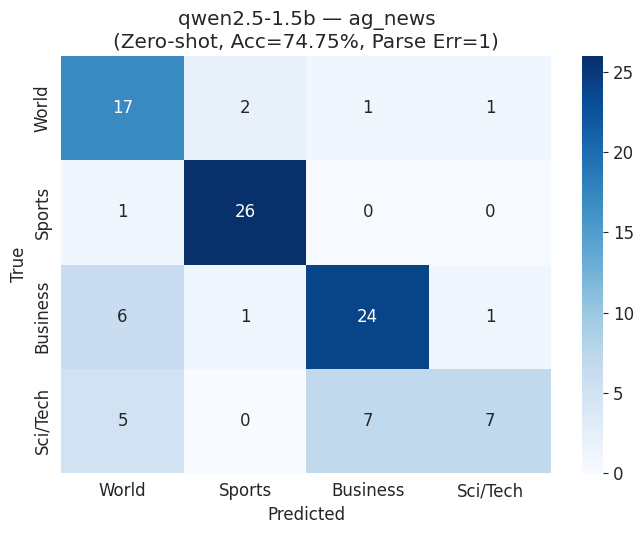

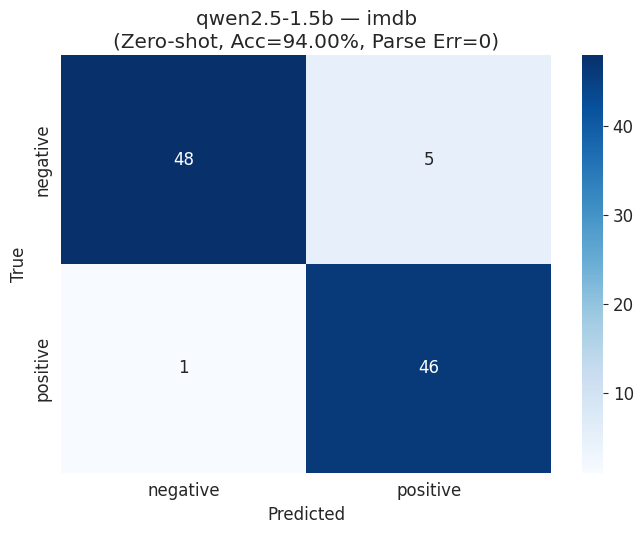

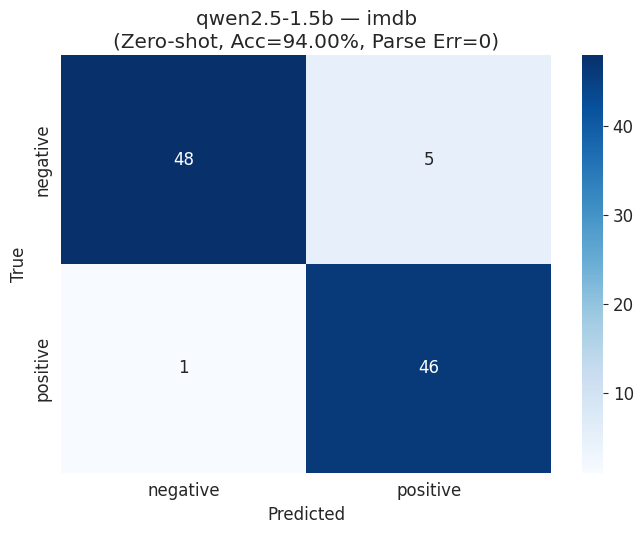

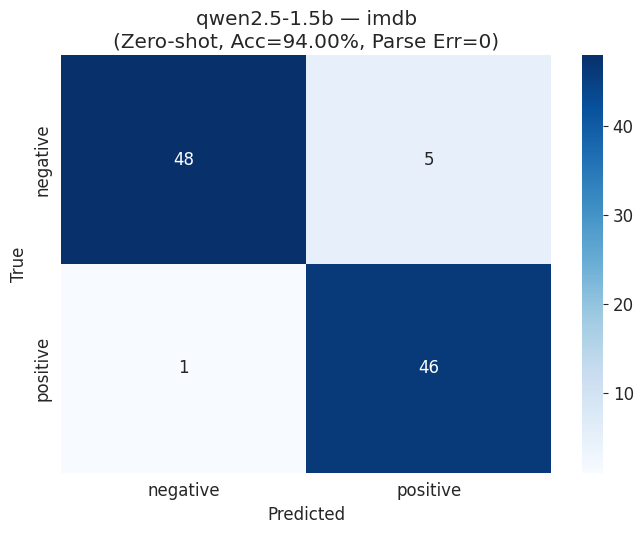

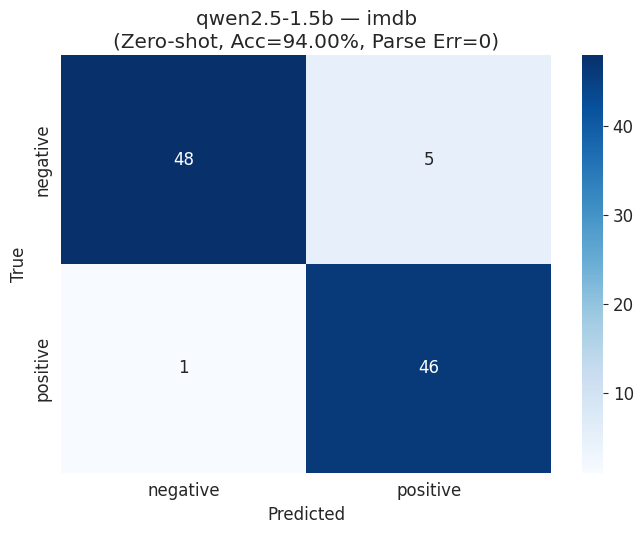

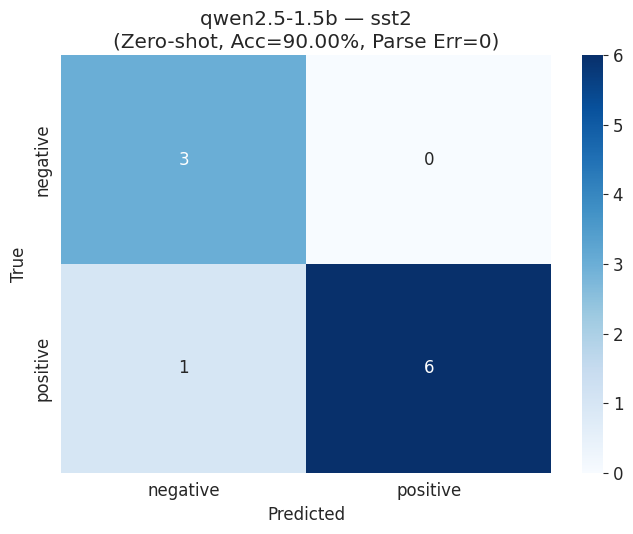

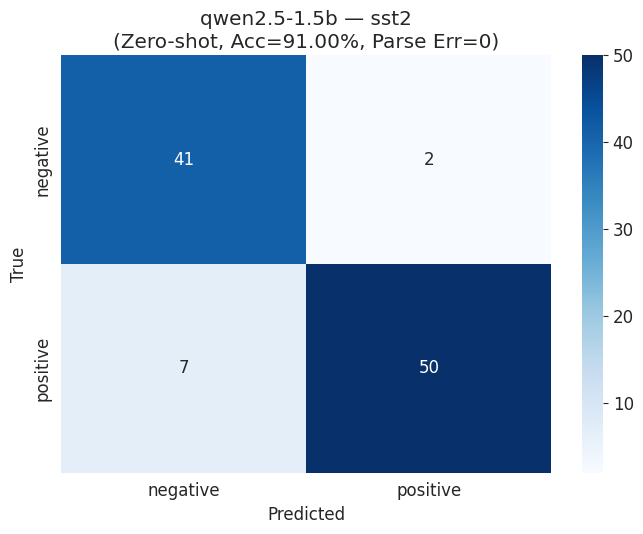

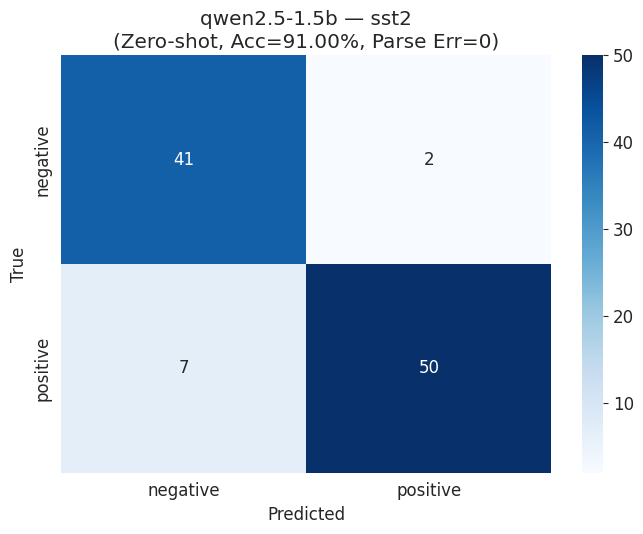

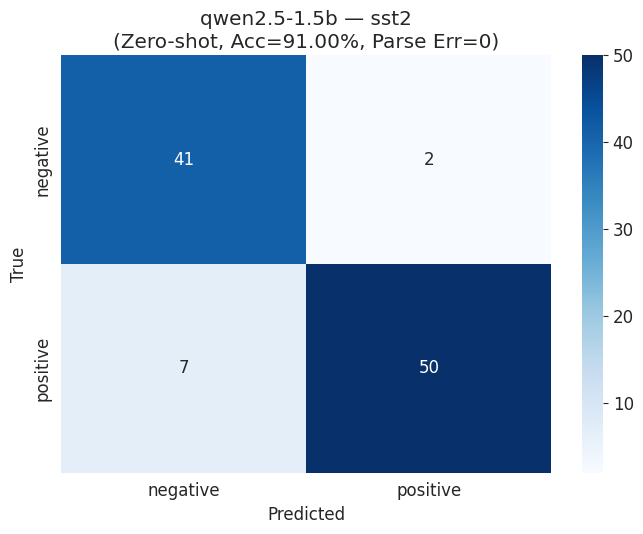

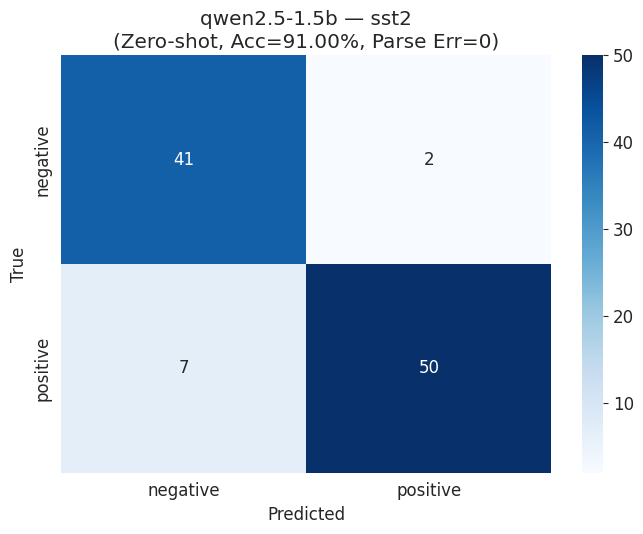

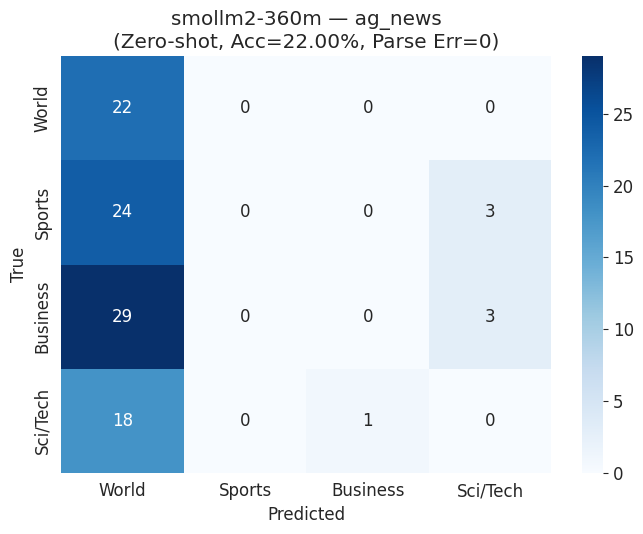

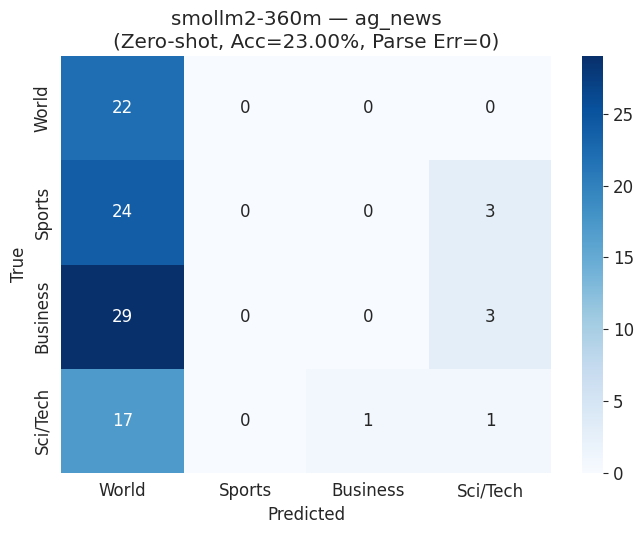

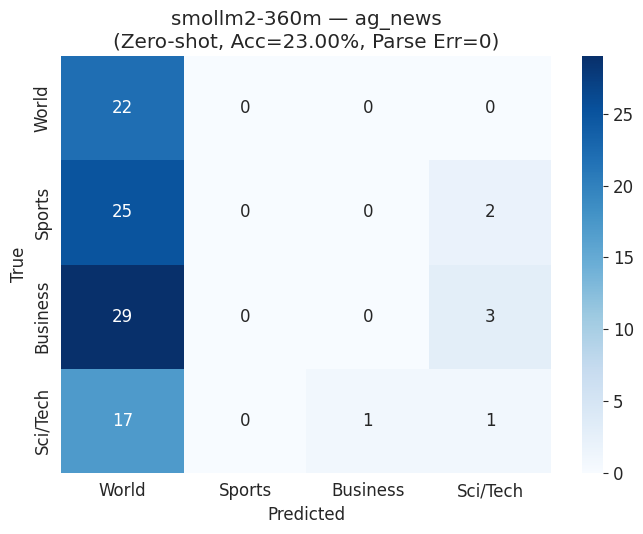

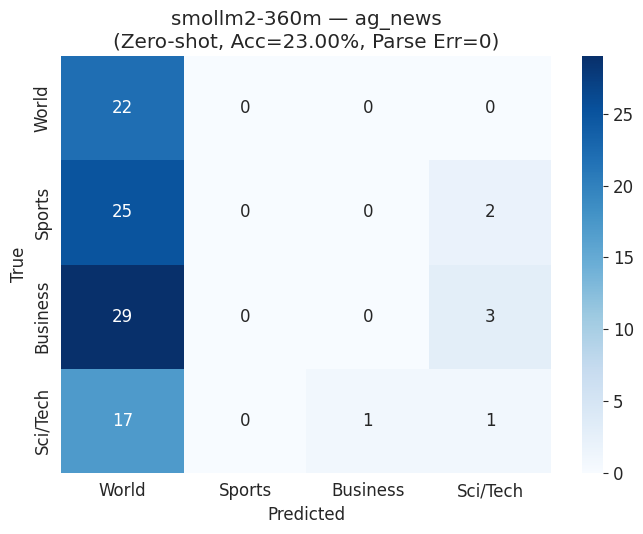

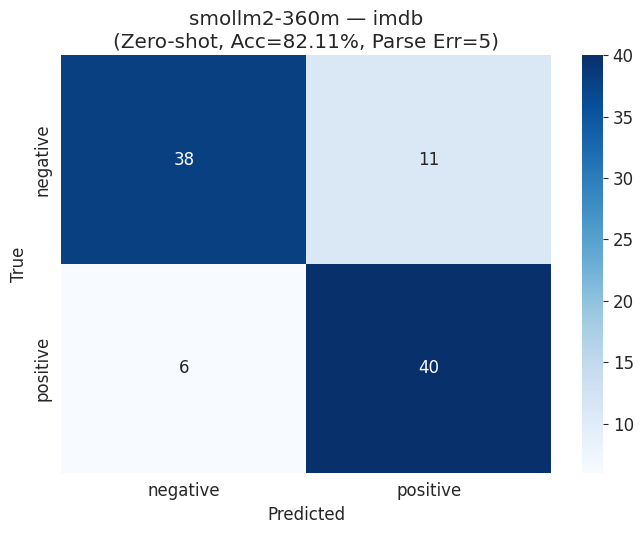

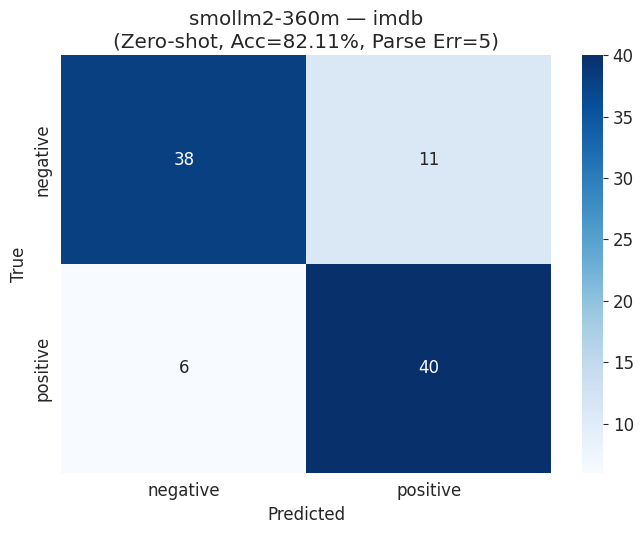

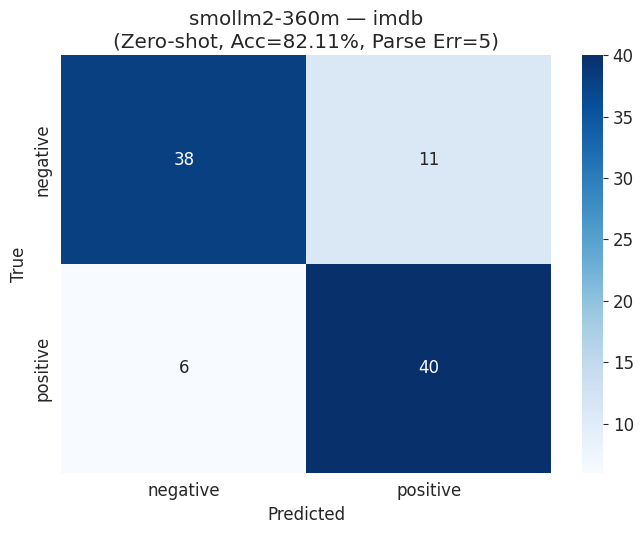

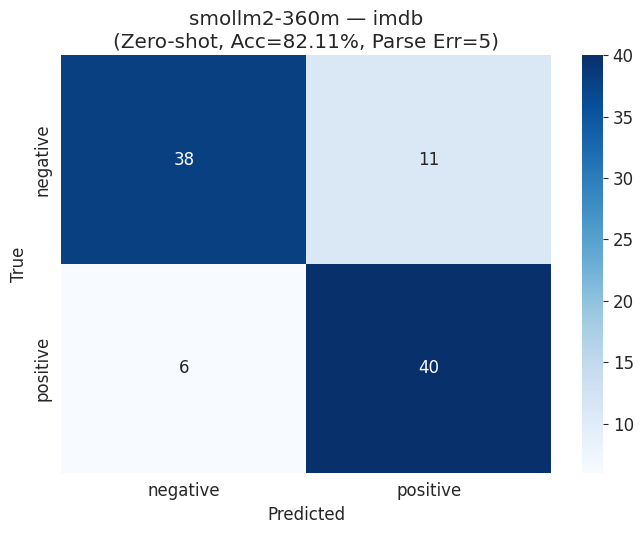

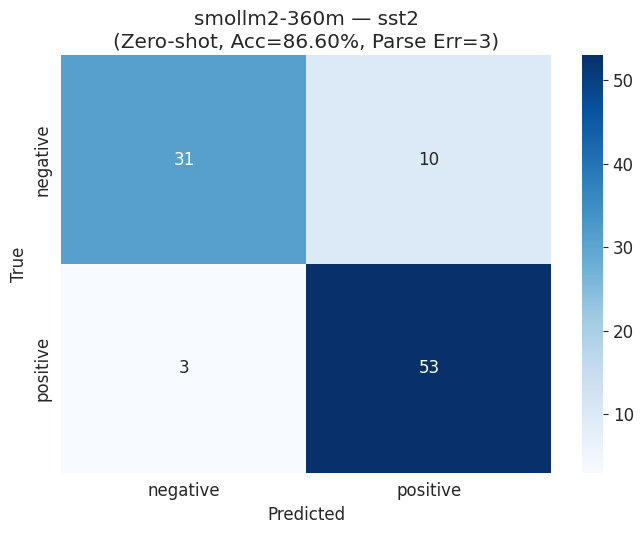

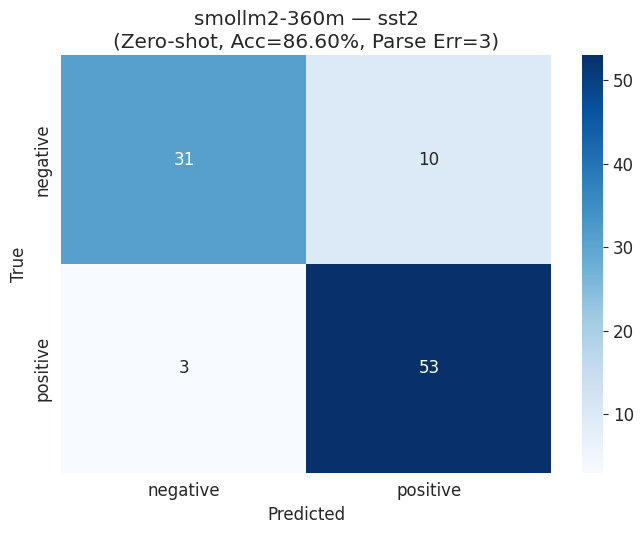

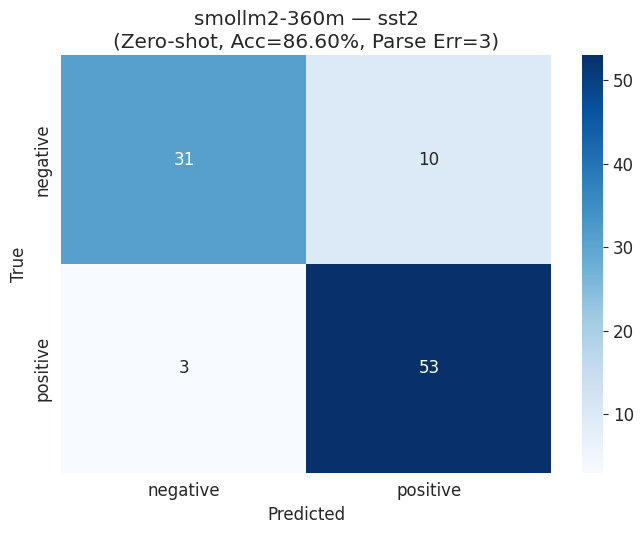

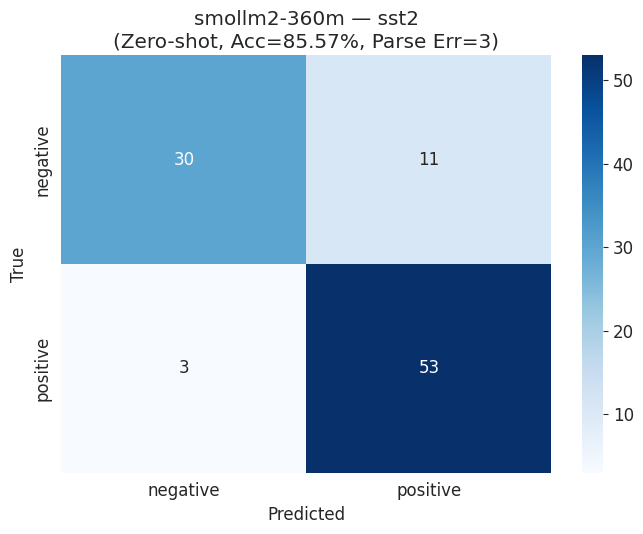


Generated 37  confusion matrices


In [82]:
# ============ ANALYSIS CELL 2: Confusion Matrix ============

def plot_confusion_matrices(logs):
    """For each model × dataset zero-shot (Template A) Plot confusion matrix"""
    count = 0
    for log in logs:
        if not is_zero_shot_default(log):
            continue
        if 'bart' in log.get('model', '').lower():
            continue
        # Exclude multi-seed repeats (only plot seed42)
        if 'seed' in log.get('prompting_strategy', ''):
            continue

        meta = get_meta(log)
        y_true, y_pred, _ = get_predictions(log)
        if len(y_true) < 10:
            continue

        ds = meta['dataset'].lower()
        labels = LABEL_MAPS.get(ds, sorted(set(y_true)))
        labels_low = [l.lower() for l in labels]

        # Separate parse errors
        valid = [(t, p) for t, p in zip(y_true, y_pred) if p.lower() in labels_low]
        parse_err = len(y_true) - len(valid)
        if len(valid) < 5:
            continue
        yt, yp = zip(*valid)

        cm = confusion_matrix(yt, yp, labels=labels)
        fig, ax = plt.subplots(figsize=(7, 5.5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        acc_str = f"{meta['accuracy']:.2%}" if meta['accuracy'] else "N/A"
        ax.set_title(f"{meta['model']} — {meta['dataset']}\n"
                     f"(Zero-shot, Acc={acc_str}, Parse Err={parse_err})")
        plt.tight_layout()
        plt.savefig(f"cm_{meta['model']}_{meta['dataset']}.png",
                    dpi=150, bbox_inches='tight')
        plt.show()
        count += 1

    print(f"\nGenerated {count}  confusion matrices")

plot_confusion_matrices(all_logs)


### 10.5 Error Taxonomy

In [83]:
# ============ ANALYSIS CELL 3: Error Taxonomy ============

def error_taxonomy(logs, max_examples=5):
    """Classify errors by type: parse error vs misclassification + Confusion direction statistics"""
    print("=" * 70)
    print("  ERROR TAXONOMY")
    print("=" * 70)

    for log in logs:
        if not is_zero_shot_default(log):
            continue
        if 'bart' in log.get('model', '').lower():
            continue
        if 'seed' in log.get('prompting_strategy', ''):
            continue

        meta = get_meta(log)
        y_true, y_pred, raw_outputs = get_predictions(log)
        if len(y_true) < 10:
            continue

        ds = meta['dataset'].lower()
        labels = LABEL_MAPS.get(ds, sorted(set(y_true)))
        labels_low = [l.lower() for l in labels]

        parse_errors = []
        misclass = []
        correct_count = 0

        for t, p, raw in zip(y_true, y_pred, raw_outputs):
            if t.lower() == p.lower():
                correct_count += 1
            elif p == "PARSE_ERROR" or p.lower() not in labels_low:
                parse_errors.append({'true': t, 'pred': p, 'raw': raw[:80]})
            else:
                misclass.append({'true': t, 'pred': p})

        print(f"\n{'─'*60}")
        print(f"Model: {meta['model']}  Dataset: {meta['dataset']}")
        print(f"Correct: {correct_count}  Misclassified: {len(misclass)}  "
              f"Parse Errors: {len(parse_errors)}")

        # Parse Error samples
        if parse_errors:
            print(f"\n  ▸ Parse Errors (First {min(max_examples, len(parse_errors))}  samples):")
            for i, e in enumerate(parse_errors[:max_examples]):
                print(f"    [{i+1}] True={e['true']}  Output='{e['raw']}'")

        # Confusion directions
        if misclass:
            pairs = Counter((e['true'], e['pred']) for e in misclass)
            print(f"\n  ▸ Most common confusion directions:")
            for (t, p), cnt in pairs.most_common(5):
                print(f"    {t} → {p}  ({cnt}  times)")

error_taxonomy(all_logs)


  ERROR TAXONOMY

────────────────────────────────────────────────────────────
Model: gemma-2-2b  Dataset: ag_news
Correct: 85  Misclassified: 14  Parse Errors: 1

  ▸ Parse Errors (First 1  samples):
    [1] True=World  Output='Music'

  ▸ Most common confusion directions:
    Sci/Tech → Business  (9  times)
    World → Business  (2  times)
    World → Sports  (2  times)
    World → Sci/Tech  (1  times)

────────────────────────────────────────────────────────────
Model: gemma-2-2b  Dataset: ag_news
Correct: 85  Misclassified: 14  Parse Errors: 1

  ▸ Parse Errors (First 1  samples):
    [1] True=World  Output='Music'

  ▸ Most common confusion directions:
    Sci/Tech → Business  (9  times)
    World → Business  (2  times)
    World → Sports  (2  times)
    World → Sci/Tech  (1  times)

────────────────────────────────────────────────────────────
Model: gemma-2-2b  Dataset: ag_news
Correct: 85  Misclassified: 14  Parse Errors: 1

  ▸ Parse Errors (First 1  samples):
    [1] True=Worl

### 10.6 Cross-Model Error Agreement

In [84]:
# ============ ANALYSIS CELL 4: Cross-Model Error Agreement ============

def cross_model_agreement(logs):
    """Analyze error overlap across three models on the same samples"""
    ds_preds = defaultdict(dict)

    for log in logs:
        if not is_zero_shot_default(log):
            continue
        if 'bart' in log.get('model', '').lower():
            continue
        if 'seed' in log.get('prompting_strategy', ''):
            continue

        meta = get_meta(log)
        y_true, y_pred, _ = get_predictions(log)
        if len(y_true) < 10:
            continue

        model_results = {}
        for i, (t, p) in enumerate(zip(y_true, y_pred)):
            model_results[i] = (t.lower() == p.lower())
        ds_preds[meta['dataset']][meta['model']] = model_results

    print("\n" + "=" * 70)
    print("  CROSS-MODEL ERROR AGREEMENT")
    print("=" * 70)

    for dataset, models in ds_preds.items():
        names = list(models.keys())
        if len(names) < 2:
            continue

        common = set(models[names[0]].keys())
        for m in names[1:]:
            common &= set(models[m].keys())
        common = sorted(common)
        if not common:
            continue

        all_right = sum(1 for i in common if all(models[m][i] for m in names))
        all_wrong = sum(1 for i in common if not any(models[m][i] for m in names))
        partial = len(common) - all_right - all_wrong

        print(f"\n  {dataset} ({len(names)} models, {len(common)} samples)")
        print(f"    All correct:  {all_right:3d} ({all_right/len(common):.1%})")
        print(f"    All wrong:    {all_wrong:3d} ({all_wrong/len(common):.1%})"
              f"  ← hard/ambiguous samples")
        print(f"    Partial:      {partial:3d} ({partial/len(common):.1%})"
              f"  ← model capability gap")

        print(f"    Pairwise agreement:")
        for i in range(len(names)):
            for j in range(i+1, len(names)):
                agree = sum(1 for idx in common
                            if models[names[i]][idx] == models[names[j]][idx])
                print(f"      {names[i]} vs {names[j]}: "
                      f"{agree}/{len(common)} ({agree/len(common):.1%})")

cross_model_agreement(all_logs)




  CROSS-MODEL ERROR AGREEMENT

  ag_news (3 models, 100 samples)
    All correct:   16 (16.0%)
    All wrong:      8 (8.0%)  ← hard/ambiguous samples
    Partial:       76 (76.0%)  ← model capability gap
    Pairwise agreement:
      gemma-2-2b vs qwen2.5-1.5b: 87/100 (87.0%)
      gemma-2-2b vs smollm2-360m: 24/100 (24.0%)
      qwen2.5-1.5b vs smollm2-360m: 37/100 (37.0%)

  imdb (3 models, 100 samples)
    All correct:   74 (74.0%)
    All wrong:      4 (4.0%)  ← hard/ambiguous samples
    Partial:       22 (22.0%)  ← model capability gap
    Pairwise agreement:
      gemma-2-2b vs qwen2.5-1.5b: 88/100 (88.0%)
      gemma-2-2b vs smollm2-360m: 86/100 (86.0%)
      qwen2.5-1.5b vs smollm2-360m: 82/100 (82.0%)

  sst2 (3 models, 100 samples)
    All correct:   67 (67.0%)
    All wrong:      2 (2.0%)  ← hard/ambiguous samples
    Partial:       31 (31.0%)  ← model capability gap
    Pairwise agreement:
      gemma-2-2b vs qwen2.5-1.5b: 83/100 (83.0%)
      gemma-2-2b vs smollm2-360m: 

### 10.7 Five-Template Comparison (A/B/C/D/E x 3 Models)

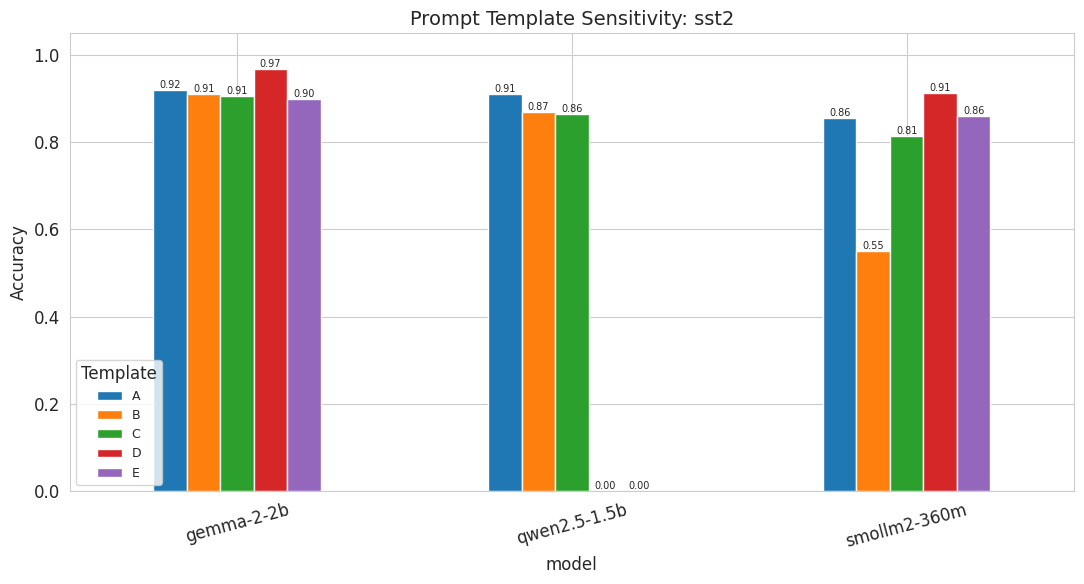

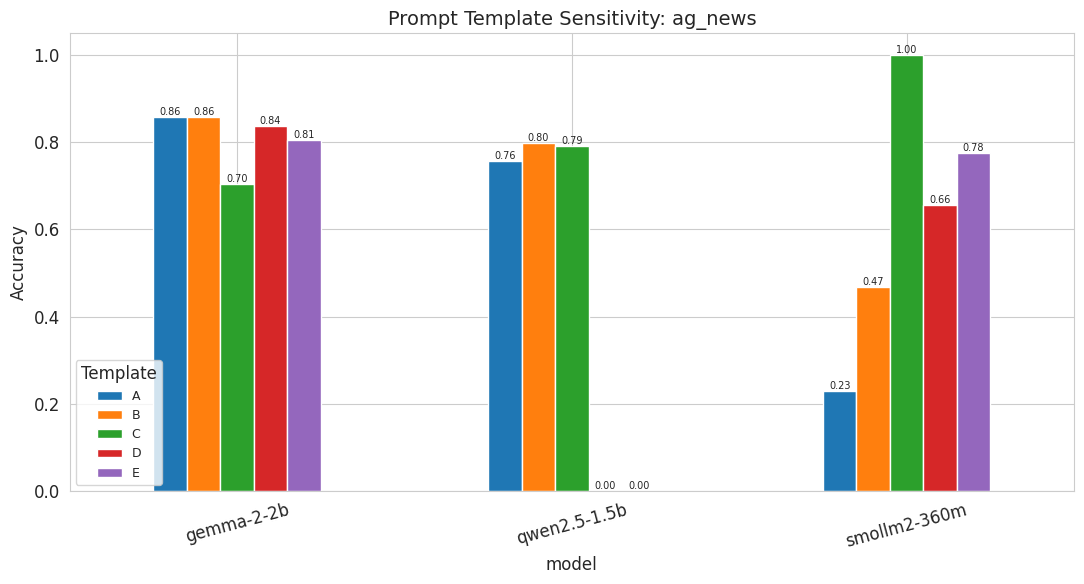

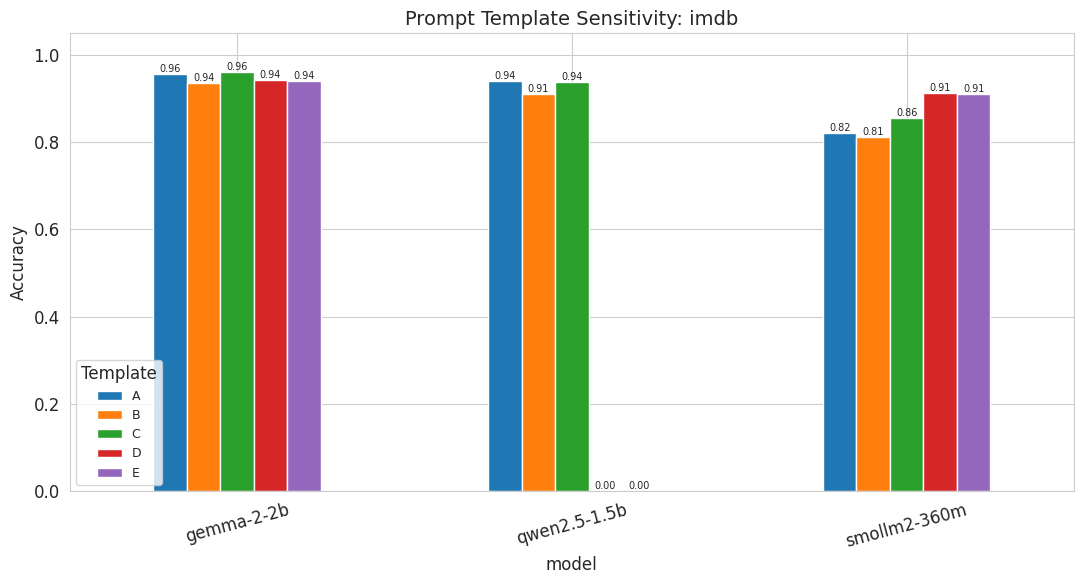


--- Prompt Sensitivity (std across templates) ---
                       mean    std    min    max  range
model        dataset                                   
gemma-2-2b   ag_news 0.8124 0.0644 0.7037 0.8586 0.1549
             imdb    0.9473 0.0106 0.9362 0.9610 0.0248
             sst2    0.9205 0.0273 0.9000 0.9677 0.0677
qwen2.5-1.5b ag_news 0.7821 0.0215 0.7576 0.7979 0.0403
             imdb    0.9292 0.0166 0.9100 0.9400 0.0300
             sst2    0.8815 0.0248 0.8646 0.9100 0.0454
smollm2-360m ag_news 0.6262 0.2936 0.2300 1.0000 0.7700
             imdb    0.8622 0.0482 0.8111 0.9136 0.1025
             sst2    0.7986 0.1434 0.5500 0.9136 0.3636


In [85]:
# ============ ANALYSIS CELL 5: Prompt Template 5-template summary ============

def plot_5template_comparison(logs):
    """Plot 5-template × 3-model comparison"""
    rows = []
    for log in logs:
        if 'bart' in log.get('model', '').lower():
            continue
        strategy = log.get('prompting_strategy', '')
        if 'zero_shot' not in strategy:
            continue

        meta = get_meta(log)
        # Identify template marker
        if 'template_' in strategy:
            tmpl = strategy.split('template_')[-1].upper()
        elif strategy == 'zero_shot':
            tmpl = 'A'  # Default = Template A
        else:
            continue

        if tmpl not in ['A', 'B', 'C', 'D', 'E']:
            continue
        # Exclude multi-seed repeats
        if 'seed' in strategy and 'template' not in strategy:
            continue

        rows.append({
            'model': meta['model'],
            'dataset': meta['dataset'],
            'template': tmpl,
            'accuracy': meta['accuracy'],
        })

    if not rows:
        print("Template experiment data not found")
        return

    tmpl_df = pd.DataFrame(rows)
    # Deduplicate (keep latest per combination)
    tmpl_df = tmpl_df.drop_duplicates(
        subset=['model', 'dataset', 'template'], keep='last'
    )

    for dataset in ['sst2', 'ag_news', 'imdb']:
        subset = tmpl_df[tmpl_df['dataset'] == dataset]
        if len(subset) < 2:
            continue

        pivot = subset.pivot_table(
            values='accuracy', index='model', columns='template', aggfunc='mean'
        )
        # Arrange columns as A B C D E
        cols = [c for c in ['A', 'B', 'C', 'D', 'E'] if c in pivot.columns]
        pivot = pivot[cols]

        ax = pivot.plot(kind='bar', figsize=(11, 6), rot=15)
        ax.set_title(f'Prompt Template Sensitivity: {dataset}', fontsize=14)
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1.05)
        ax.legend(title='Template', fontsize=9)

        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7)

        plt.tight_layout()
        plt.savefig(f'prompt_5templates_{dataset}.png', dpi=150, bbox_inches='tight')
        plt.show()

    # Sensitivity table
    print("\n--- Prompt Sensitivity (std across templates) ---")
    sens = tmpl_df.groupby(['model', 'dataset'])['accuracy'].agg(
        ['mean', 'std', 'min', 'max']
    )
    sens['range'] = sens['max'] - sens['min']
    print(sens.to_string(float_format='%.4f'))

plot_5template_comparison(all_logs)


### 10.8 Multi-Seed Box Plots

/tmp/ipykernel_3110/1914883010.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True)


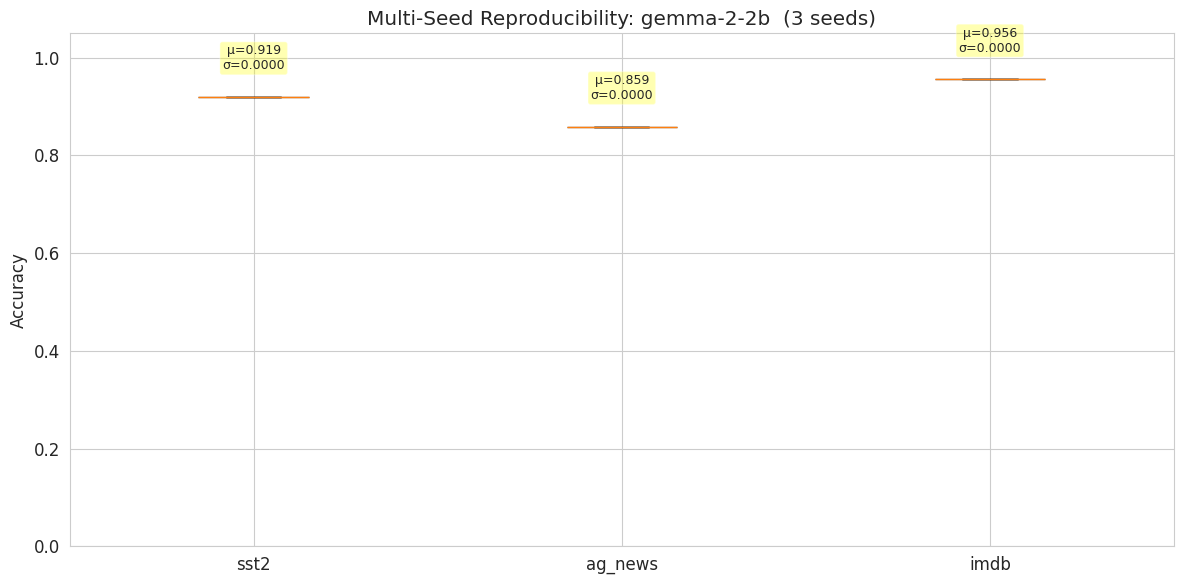

/tmp/ipykernel_3110/1914883010.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True)


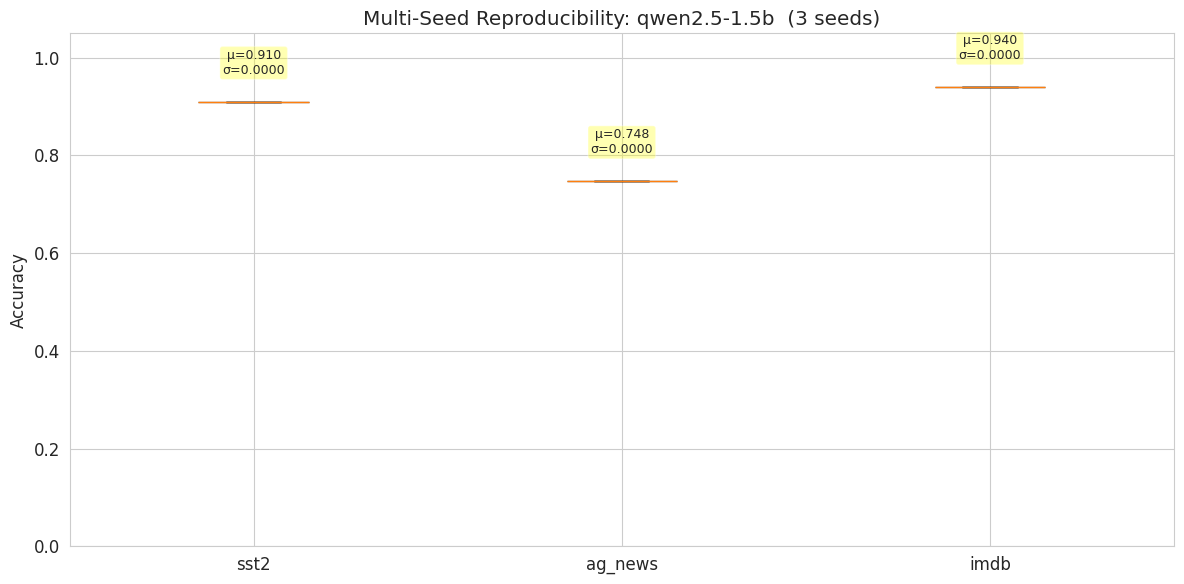

/tmp/ipykernel_3110/1914883010.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True)


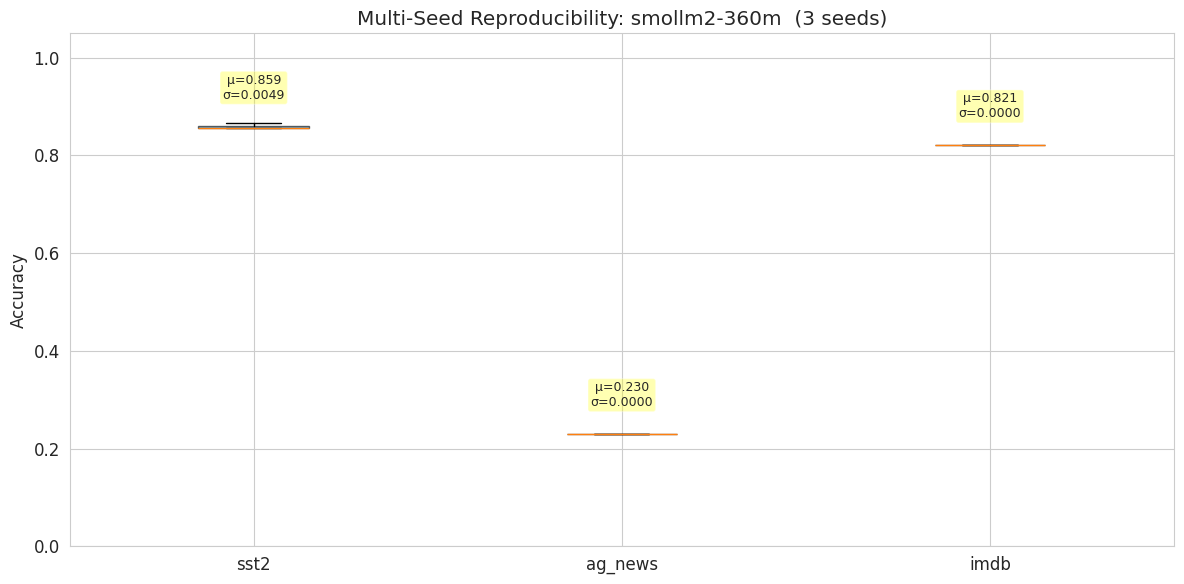


--- Multi-Seed Summary ---
                      count   mean    std    min    max  range
model        dataset                                          
gemma-2-2b   ag_news      3 0.8586 0.0000 0.8586 0.8586 0.0000
             imdb         3 0.9556 0.0000 0.9556 0.9556 0.0000
             sst2         3 0.9195 0.0000 0.9195 0.9195 0.0000
qwen2.5-1.5b ag_news      3 0.7475 0.0000 0.7475 0.7475 0.0000
             imdb         3 0.9400 0.0000 0.9400 0.9400 0.0000
             sst2         3 0.9100 0.0000 0.9100 0.9100 0.0000
smollm2-360m ag_news      3 0.2300 0.0000 0.2300 0.2300 0.0000
             imdb         3 0.8211 0.0000 0.8211 0.8211 0.0000
             sst2         3 0.8591 0.0059 0.8557 0.8660 0.0103


In [86]:
# ============ ANALYSIS CELL 6: Multi-Seed Box Plot ============

def plot_multi_seed(logs):
    """Plot multi-seed experiment box plots"""
    rows = []
    for log in logs:
        if 'bart' in log.get('model', '').lower():
            continue
        strategy = log.get('prompting_strategy', '')
        # Filter multi-seed experiments only
        if 'seed' not in strategy:
            continue
        if 'template' in strategy:
            continue

        meta = get_meta(log)
        rows.append({
            'model': meta['model'],
            'dataset': meta['dataset'],
            'seed': meta['seed'],
            'accuracy': meta['accuracy'],
        })

    # Also include original zero_shot (seed=42 baseline)
    for log in logs:
        if 'bart' in log.get('model', '').lower():
            continue
        strategy = log.get('prompting_strategy', '')
        if strategy != 'zero_shot':
            continue
        meta = get_meta(log)
        rows.append({
            'model': meta['model'],
            'dataset': meta['dataset'],
            'seed': 42,
            'accuracy': meta['accuracy'],
        })

    if not rows:
        print("Multi-seed data not found")
        return

    seed_df = pd.DataFrame(rows)
    seed_df = seed_df.drop_duplicates(
        subset=['model', 'dataset', 'seed'], keep='last'
    )

    models = seed_df['model'].unique()

    for model in models:
        mdf = seed_df[seed_df['model'] == model]
        if len(mdf) < 2:
            continue

        fig, ax = plt.subplots(figsize=(12, 6))
        groups = []
        labels = []

        for ds in ['sst2', 'ag_news', 'imdb']:
            subset = mdf[mdf['dataset'] == ds]
            if len(subset) > 0:
                groups.append(subset['accuracy'].values)
                labels.append(ds)

        if not groups:
            continue

        bp = ax.boxplot(groups, labels=labels, patch_artist=True)
        colors = ['#3498db', '#e74c3c', '#2ecc71']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        ax.set_ylabel('Accuracy')
        ax.set_title(f'Multi-Seed Reproducibility: {model}  '
                     f'({len(mdf["seed"].unique())} seeds)')
        ax.set_ylim(0, 1.05)

        for i, g in enumerate(groups):
            mu, sigma = np.mean(g), np.std(g)
            ax.annotate(f'μ={mu:.3f}\nσ={sigma:.4f}',
                       xy=(i+1, mu), fontsize=9, ha='center',
                       xytext=(0, 20), textcoords='offset points',
                       bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3))

        plt.tight_layout()
        plt.savefig(f'multi_seed_{model}.png', dpi=150, bbox_inches='tight')
        plt.show()

    # SummaryTable
    print("\n--- Multi-Seed Summary ---")
    summary = seed_df.groupby(['model', 'dataset'])['accuracy'].agg(
        ['count', 'mean', 'std', 'min', 'max']
    )
    summary['range'] = summary['max'] - summary['min']
    print(summary.to_string(float_format='%.4f'))

plot_multi_seed(all_logs)

### 10.9 Accuracy vs Latency Scatter

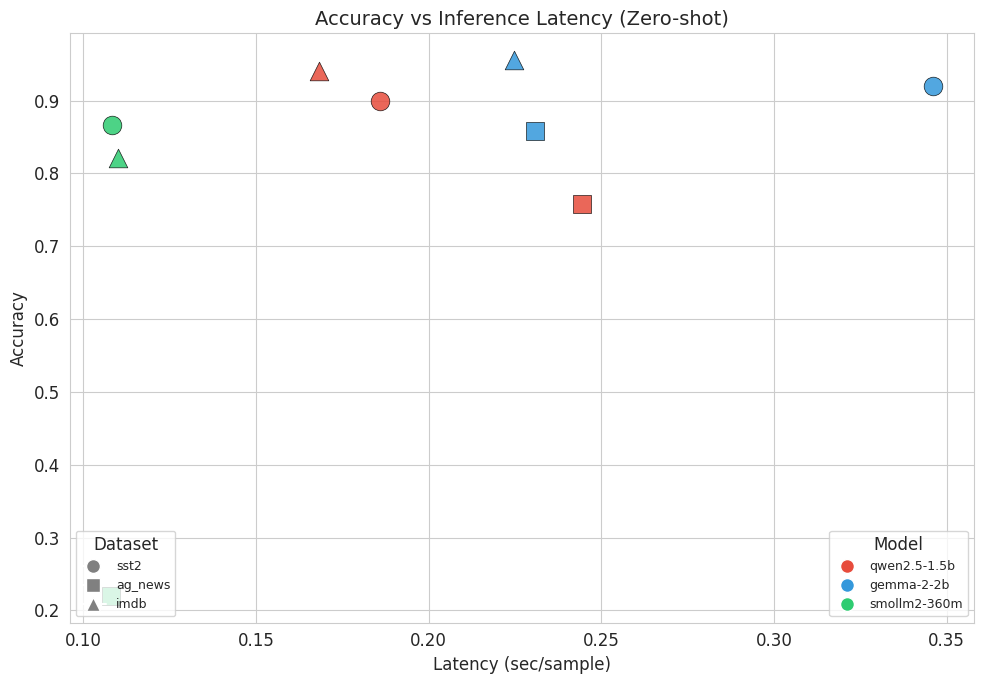

In [87]:
# ============ ANALYSIS CELL 7: Accuracy vs Latency ============

def plot_accuracy_latency(logs):
    """Plot accuracy vs latency scatter plot"""
    rows = []
    for log in logs:
        if 'bart' in log.get('model', '').lower():
            continue
        if log.get('prompting_strategy', '') != 'zero_shot':
            continue
        meta = get_meta(log)
        if meta['accuracy'] is None or meta['latency'] is None:
            continue
        rows.append(meta)

    if not rows:
        print("No latency data")
        return

    lat_df = pd.DataFrame(rows)
    lat_df = lat_df.drop_duplicates(
        subset=['model', 'dataset'], keep='first'
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    palette = {'qwen2.5-1.5b': '#e74c3c', 'gemma-2-2b': '#3498db',
               'smollm2-360m': '#2ecc71'}
    markers = {'sst2': 'o', 'ag_news': 's', 'imdb': '^'}

    for _, row in lat_df.iterrows():
        ax.scatter(row['latency'], row['accuracy'],
                   s=180,
                   marker=markers.get(row['dataset'], 'D'),
                   color=palette.get(row['model'], 'gray'),
                   alpha=0.85, edgecolors='black', linewidth=0.5)

    # Legend
    from matplotlib.lines import Line2D
    model_handles = [Line2D([0], [0], marker='o', color='w',
                            markerfacecolor=c, markersize=10, label=m)
                     for m, c in palette.items()]
    ds_handles = [Line2D([0], [0], marker=v, color='w',
                         markerfacecolor='gray', markersize=10, label=k)
                  for k, v in markers.items()]

    leg1 = ax.legend(handles=model_handles, title='Model',
                     loc='lower right', fontsize=9)
    ax.add_artist(leg1)
    ax.legend(handles=ds_handles, title='Dataset',
              loc='lower left', fontsize=9)

    ax.set_xlabel('Latency (sec/sample)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Accuracy vs Inference Latency (Zero-shot)', fontsize=14)

    plt.tight_layout()
    plt.savefig('accuracy_vs_latency.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_accuracy_latency(all_logs)


### 10.10 Latency Bar Chart

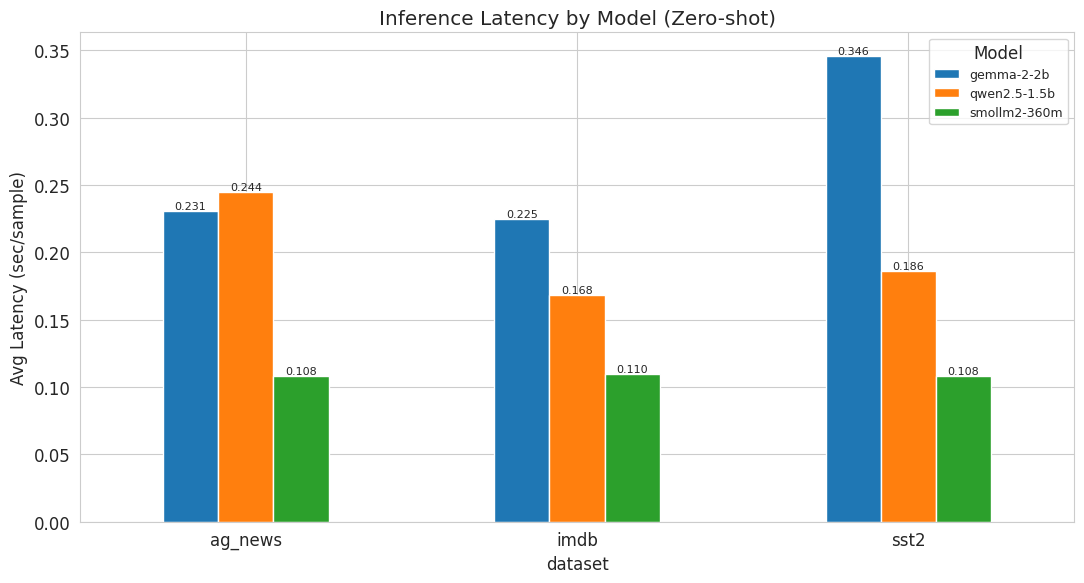


--- Latency Summary ---
model    gemma-2-2b  qwen2.5-1.5b  smollm2-360m
dataset                                        
ag_news      0.2309        0.2444        0.1080
imdb         0.2248        0.1683        0.1100
sst2         0.3460        0.1859        0.1083


In [88]:
# ============ ANALYSIS CELL 8: Latency Bar Chart ============

def plot_latency_bars(logs):
    """Model inference speed comparison"""
    rows = []
    for log in logs:
        if 'bart' in log.get('model', '').lower():
            continue
        if log.get('prompting_strategy', '') != 'zero_shot':
            continue
        meta = get_meta(log)
        if meta['latency'] is None:
            continue
        rows.append({
            'model': meta['model'], 'dataset': meta['dataset'],
            'latency': meta['latency']
        })

    if not rows:
        print("No latency data")
        return

    lat_df = pd.DataFrame(rows)
    lat_df = lat_df.drop_duplicates(subset=['model', 'dataset'], keep='first')

    pivot = lat_df.pivot_table(values='latency', index='dataset',
                               columns='model', aggfunc='mean')

    ax = pivot.plot(kind='bar', figsize=(11, 6), rot=0)
    ax.set_ylabel('Avg Latency (sec/sample)')
    ax.set_title('Inference Latency by Model (Zero-shot)')
    ax.legend(title='Model', fontsize=9)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8)

    plt.tight_layout()
    plt.savefig('latency_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n--- Latency Summary ---")
    print(pivot.to_string(float_format='%.4f'))

plot_latency_bars(all_logs)



### 10.11 Run All Charts

In [89]:
# ============ ANALYSIS CELL 9: All charts summary ============

print("""
============================================================
  Analysis complete! Generated charts:
============================================================

1. cm_*.png               — Confusion Matrix (per model × dataset)
2. prompt_5templates_*.png — 5 Template sensitivity comparison (per dataset)
3. multi_seed_*.png        — Multi-seed Box Plot (per model)
4. accuracy_vs_latency.png — Accuracy vs Inference Latency
5. latency_bars.png        — Inference speed comparison

These charts can go directly into the Final Report.
""")



  Analysis complete! Generated charts:

1. cm_*.png               — Confusion Matrix (per model × dataset)
2. prompt_5templates_*.png — 5 Template sensitivity comparison (per dataset)
3. multi_seed_*.png        — Multi-seed Box Plot (per model)
4. accuracy_vs_latency.png — Accuracy vs Inference Latency
5. latency_bars.png        — Inference speed comparison

These charts can go directly into the Final Report.



---
## 11. Data Repair and Final Rerun

After Colab runtime reset, primary experiments were rerun for data consistency.

### 11.1 Complete Rerun (All Models, All Datasets, Template A)

In [90]:
!pip install transformers accelerate bitsandbytes datasets -q

import json, os, time, torch, gc, shutil
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import accuracy_score, f1_score

# Dataset loading
sst2_raw = load_dataset("glue", "sst2", split="validation")
ag_raw = load_dataset("ag_news", split="test")
imdb_raw = load_dataset("imdb", split="test")

LABEL_MAPPINGS = {
    "sst2":    {0: "negative", 1: "positive"},
    "imdb":    {0: "negative", 1: "positive"},
    "ag_news": {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
}

PROMPT_TEMPLATES = {
    "sst2":    "Classify the sentiment of the following review:\n{input}\nLabel:",
    "imdb":    "Classify the sentiment of the following movie review:\n{input}\nLabel:",
    "ag_news": "Classify the topic of the following news article into World, Sports, Business, or Sci/Tech:\n{input}\nLabel:",
}

EVAL_SEED = 42

def preprocess(example, dataset_name):
    if dataset_name == "sst2":
        raw_text = example["sentence"]
    elif dataset_name == "ag_news":
        raw_text = example["text"]
    elif dataset_name == "imdb":
        import re
        raw_text = re.sub(r'<.*?>', '', example["text"])
    label_id = example["label"]
    return {
        "raw_text": raw_text,
        "formatted_prompt": PROMPT_TEMPLATES[dataset_name].format(input=raw_text[:500]),
        "true_label_name": LABEL_MAPPINGS[dataset_name][label_id],
        "label_id": label_id,
    }

sst2_proc = sst2_raw.map(lambda x: preprocess(x, "sst2"))
ag_proc = ag_raw.map(lambda x: preprocess(x, "ag_news"))
imdb_proc = imdb_raw.map(lambda x: preprocess(x, "imdb"))

np.random.seed(EVAL_SEED)
sst2_eval = sst2_proc.select(np.random.choice(len(sst2_proc), 100, replace=False))
ag_eval = ag_proc.select(np.random.choice(len(ag_proc), 100, replace=False))
imdb_eval = imdb_proc.select(np.random.choice(len(imdb_proc), 100, replace=False))

print(f"SST-2: {len(sst2_eval)}, AG News: {len(ag_eval)}, IMDb: {len(imdb_eval)} ✓")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

SST-2: 100, AG News: 100, IMDb: 100 ✓


In [91]:
os.makedirs("experiment_logs", exist_ok=True)

def parse_label(raw_output, dataset_name):
    valid_labels = list(LABEL_MAPPINGS[dataset_name].values())
    raw_lower = raw_output.lower().strip()
    for label in valid_labels:
        if label.lower() in raw_lower:
            return label
    return "PARSE_ERROR"

def save_experiment_log(model_name, dataset_name, prompting_strategy,
                        temperature, seed, results, accuracy, f1):
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_id = f"{model_name}_{dataset_name}_{prompting_strategy}_{timestamp}"
    latencies = [r["latency_sec"] for r in results]
    log = {
        "run_id": run_id, "timestamp": timestamp,
        "model": model_name, "dataset": dataset_name,
        "prompting_strategy": prompting_strategy,
        "temperature": temperature, "eval_seed": seed,
        "eval_n": len(results),
        "accuracy": round(accuracy, 4),
        "f1_macro": round(f1, 4),
        "avg_latency_sec": round(sum(latencies)/len(latencies), 4),
        "total_latency_sec": round(sum(latencies), 4),
        "parse_error_count": sum(1 for r in results if r["predicted_label"] == "PARSE_ERROR"),
        "per_sample_results": results
    }
    filepath = os.path.join("experiment_logs", f"{run_id}.json")
    with open(filepath, 'w') as f:
        json.dump(log, f, indent=2, ensure_ascii=False)
    print(f"Log saved: {filepath}")

def run_inference_qwen(example, dataset_name):
    messages = [
        {"role": "system", "content": "You are a text classification assistant. Reply with only the label, nothing else."},
        {"role": "user", "content": example["formatted_prompt"]}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)
    t_start = time.time()
    with torch.no_grad():
        outputs = model_qwen.generate(**inputs, max_new_tokens=10,
                                       temperature=0.01, do_sample=True,
                                       pad_token_id=tokenizer.eos_token_id)
    latency = time.time() - t_start
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)
    return {
        "predicted_label": predicted_label,
        "true_label": example["true_label_name"],
        "correct": predicted_label == example["true_label_name"],
        "latency_sec": round(latency, 4),
        "tokens_used": len(generated_ids),
        "raw_output": raw_output,
        "text": example.get("raw_text", "")
    }

def run_inference_gemma(example, dataset_name):
    prompt = ("You are a text classification assistant. Reply with only the label, nothing else.\n\n"
              + example["formatted_prompt"])
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)
    t_start = time.time()
    with torch.no_grad():
        outputs = model_qwen.generate(**inputs, max_new_tokens=10,
                                       temperature=0.01, do_sample=True,
                                       pad_token_id=tokenizer.eos_token_id)
    latency = time.time() - t_start
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)
    return {
        "predicted_label": predicted_label,
        "true_label": example["true_label_name"],
        "correct": predicted_label == example["true_label_name"],
        "latency_sec": round(latency, 4),
        "tokens_used": len(generated_ids),
        "raw_output": raw_output,
        "text": example.get("raw_text", "")
    }

def run_zeroshot_all(model_name, max_samples=100):
    for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
        dataset = ds_eval.select(range(max_samples))
        results = []
        for i, example in enumerate(dataset):
            if i % 25 == 0:
                print(f"  {ds_name} Progress: {i}/{len(dataset)}...")
            if model_name == "qwen2.5-1.5b":
                r = run_inference_qwen(example, ds_name)
            else:
                r = run_inference_gemma(example, ds_name)
            results.append(r)
        true_l = [r["true_label"] for r in results]
        pred_l = [r["predicted_label"] for r in results]
        valid = [(t,p) for t,p in zip(true_l, pred_l) if p != "PARSE_ERROR"]
        if valid:
            tv, pv = zip(*valid)
            acc = accuracy_score(tv, pv)
            f1 = f1_score(tv, pv, average="macro")
        else:
            acc, f1 = 0.0, 0.0
        print(f"  {ds_name}: Acc={acc:.4f} F1={f1:.4f}")
        save_experiment_log(model_name, ds_name, "zero_shot", 0.01, EVAL_SEED, results, acc, f1)

print("Function definitions complete ✓")

Function definitions complete ✓


In [92]:
!pip install -q huggingface_hub
from huggingface_hub import login
login()

In [93]:
# Qwen
print("=" * 50)
print("Loading Qwen...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model_qwen = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct", torch_dtype=torch.float16, device_map="auto")
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
print("Qwen loaded successfully ✓")
run_zeroshot_all("qwen2.5-1.5b")

# Switch to Gemma
del model_qwen; gc.collect(); torch.cuda.empty_cache()
print("\n" + "=" * 50)
print("Loading Gemma...")
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-2b-it")
model_qwen = AutoModelForCausalLM.from_pretrained("google/gemma-2-2b-it", torch_dtype=torch.float16, device_map="auto")
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
print("Gemma loaded successfully ✓")
run_zeroshot_all("gemma-2-2b")

# Switch to SmolLM2
del model_qwen; gc.collect(); torch.cuda.empty_cache()
print("\n" + "=" * 50)
print("Loading SmolLM2...")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M-Instruct")
model_qwen = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-360M-Instruct", torch_dtype=torch.float16, device_map="auto")
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
print("SmolLM2 loaded successfully ✓")
run_zeroshot_all("smollm2-360m")

print("\nAll complete ✓")

Loading Qwen...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen loaded successfully ✓
  sst2 Progress: 0/100...
  sst2 Progress: 25/100...
  sst2 Progress: 50/100...
  sst2 Progress: 75/100...
  sst2: Acc=0.9800 F1=0.9795
Log saved: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_20260519_012908.json
  ag_news Progress: 0/100...
  ag_news Progress: 25/100...
  ag_news Progress: 50/100...
  ag_news Progress: 75/100...
  ag_news: Acc=0.7172 F1=0.6947
Log saved: experiment_logs/qwen2.5-1.5b_ag_news_zero_shot_20260519_012931.json
  imdb Progress: 0/100...
  imdb Progress: 25/100...
  imdb Progress: 50/100...
  imdb Progress: 75/100...
  imdb: Acc=0.9200 F1=0.9195
Log saved: experiment_logs/qwen2.5-1.5b_imdb_zero_shot_20260519_012943.json

Loading Gemma...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Gemma loaded successfully ✓
  sst2 Progress: 0/100...
  sst2 Progress: 25/100...
  sst2 Progress: 50/100...
  sst2 Progress: 75/100...
  sst2: Acc=0.9674 F1=0.9662
Log saved: experiment_logs/gemma-2-2b_sst2_zero_shot_20260519_013032.json
  ag_news Progress: 0/100...
  ag_news Progress: 25/100...
  ag_news Progress: 50/100...
  ag_news Progress: 75/100...
  ag_news: Acc=0.8352 F1=0.8127
Log saved: experiment_logs/gemma-2-2b_ag_news_zero_shot_20260519_013057.json
  imdb Progress: 0/100...
  imdb Progress: 25/100...
  imdb Progress: 50/100...
  imdb Progress: 75/100...
  imdb: Acc=0.9318 F1=0.9318
Log saved: experiment_logs/gemma-2-2b_imdb_zero_shot_20260519_013121.json

Loading SmolLM2...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

SmolLM2 loaded successfully ✓
  sst2 Progress: 0/100...
  sst2 Progress: 25/100...
  sst2 Progress: 50/100...
  sst2 Progress: 75/100...
  sst2: Acc=0.8900 F1=0.8849
Log saved: experiment_logs/smollm2-360m_sst2_zero_shot_20260519_013136.json
  ag_news Progress: 0/100...
  ag_news Progress: 25/100...
  ag_news Progress: 50/100...
  ag_news Progress: 75/100...
  ag_news: Acc=0.2500 F1=0.1348
Log saved: experiment_logs/smollm2-360m_ag_news_zero_shot_20260519_013148.json
  imdb Progress: 0/100...
  imdb Progress: 25/100...
  imdb Progress: 50/100...
  imdb Progress: 75/100...
  imdb: Acc=0.8021 F1=0.8021
Log saved: experiment_logs/smollm2-360m_imdb_zero_shot_20260519_013201.json

All complete ✓


In [95]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree("experiment_logs", "/content/drive/MyDrive/experiment_logs-0519", dirs_exist_ok=True)
print("Done")

Mounted at /content/drive
Done


### 11.2 Log Verification and Text Field Check

In [96]:
import glob, json
from collections import Counter

LOG_DIR = "experiment_logs"
LABEL_MAPS = {
    'sst2': ['negative', 'positive'],
    'ag_news': ['World', 'Sports', 'Business', 'Sci/Tech'],
    'imdb': ['negative', 'positive'],
}

# Only load the 9 logs that contain text fields
new_logs = []
for fp in sorted(glob.glob(os.path.join(LOG_DIR, "*.json"))):
    with open(fp) as f:
        log = json.load(f)
    # Filter logs with text field only
    if (log.get('per_sample_results') and
        len(log['per_sample_results']) > 0 and
        'text' in log['per_sample_results'][0]):
        new_logs.append(log)

print(f"Found {len(new_logs)}  logs with original text")

# Error Analysis with text
for log in new_logs:
    model = log['model']
    dataset = log['dataset']
    preds = log['per_sample_results']

    labels = LABEL_MAPS.get(dataset, [])
    labels_low = [l.lower() for l in labels]

    parse_errors = []
    misclass = []

    for s in preds:
        t = s['true_label']
        p = s['predicted_label']
        text = s.get('text', '')[:200]

        if t.lower() == p.lower():
            continue
        elif p == "PARSE_ERROR" or p.lower() not in labels_low:
            parse_errors.append({'true': t, 'pred': p,
                                  'raw': s.get('raw_output',''), 'text': text})
        else:
            misclass.append({'true': t, 'pred': p, 'text': text,
                             'words': len(text.split())})

    print(f"\n{'='*70}")
    print(f"  {model} — {dataset}")
    print(f"  Correct: {len(preds)-len(parse_errors)-len(misclass)}  "
          f"Misclassified: {len(misclass)}  Parse Errors: {len(parse_errors)}")
    print(f"{'='*70}")

    if parse_errors:
        print(f"\n  ▸ Parse Errors:")
        for i, e in enumerate(parse_errors[:3]):
            print(f"    [{i+1}] True={e['true']}  Output='{e['raw']}'")
            print(f"        Text: {e['text']}...")

    if misclass:
        pairs = Counter((e['true'], e['pred']) for e in misclass)
        print(f"\n  ▸ Most common confusion directions:")
        for (t, p), cnt in pairs.most_common(5):
            print(f"    {t} → {p}  ({cnt}  times)")

        print(f"\n  ▸ Typical error samples:")
        for i, e in enumerate(misclass[:5]):
            print(f"    [{i+1}] True={e['true']} → Pred={e['pred']}  ({e['words']} words)")
            print(f"        {e['text']}...")

Found 9  logs with original text

  gemma-2-2b — ag_news
  Correct: 76  Misclassified: 15  Parse Errors: 9

  ▸ Parse Errors:
    [1] True=Sci/Tech  Output='Law'
        Text: Music file-sharing case heads to high court eeding the pleas of the entertainment industry, the US Supreme Court has agreed to consider calling a halt to Internet file-sharing that allows millions of ...
    [2] True=Sci/Tech  Output='Politics'
        Text: Congress Sends 'Net Access Ban to White House The U.S. Congress on Friday reinstated a ban on Internet access taxes after the House of Representatives agreed to extend it for another three years rathe...
    [3] True=Sci/Tech  Output='Crime'
        Text: Man arrested for fatally stabbing elderly parents SAITAMA -- A middle-aged man who fatally stabbed his parents has been arrested, police said. Hideo Nakajima, an unemployed man from Soka, Saitama Pref...

  ▸ Most common confusion directions:
    Sci/Tech → Business  (8  times)
    Sci/Tech → World  (2  time

### 11.3 Final Log Backup

In [97]:
shutil.make_archive("experiment_logs_with_text", "zip", "experiment_logs")
print("Packing complete ✓")

Packing complete ✓


---
## 12. Reproducibility Verification (Final)

Verifies per-sample agreement across repeated runs from saved logs.

In [98]:
# ============================================================
# REPRODUCIBILITY VERIFICATION
#
# Purpose: Empirically verify that experiments conducted under
# controlled settings (temperature=0.01, fixed seed, fixed samples)
# produce consistent results across repeated runs.
#
# Two verification approaches:
#   1. Repeat-run agreement: Same config run 5 times,
#      compare per-sample predictions across all runs
#   2. Multi-seed consistency: Same model/dataset with 3 different
#      seeds (42, 123, 456) — checks if model behavior is stable
#      regardless of which 100 samples are drawn
#
# This directly addresses Proposal Objective 2:
# "Determine the minimum number of runs required to obtain
#  stable and comparable results"
# ============================================================

import json, os, glob
import numpy as np
from collections import defaultdict

LOG_DIR = "experiment_logs"

# ---- Load all logs ----
all_logs = []
for fp in sorted(glob.glob(os.path.join(LOG_DIR, "*.json"))):
    with open(fp) as f:
        log = json.load(f)
    log['_filepath'] = fp
    all_logs.append(log)

print(f"Loaded {len(all_logs)} experiment logs")

# ============================================================
# Part 1: Repeat-Run Per-Sample Agreement
# ============================================================

print("\n" + "=" * 75)
print("PART 1: Repeat-Run Reproducibility (5 runs × same config)")
print("=" * 75)
print("Testing whether identical experimental settings produce")
print("identical per-sample predictions across independent runs.\n")

# Group repeat-run logs
repeat_groups = defaultdict(list)
for log in all_logs:
    strat = log['prompting_strategy']
    if '_repeat_run' in strat:
        base_strat = strat.rsplit('_repeat_', 1)[0]
        key = f"{log['model']}|{log['dataset']}|{base_strat}"
        repeat_groups[key].append(log)

# Analyze each group
print(f"{'Config':<45} {'Runs':>5} {'Agree':>7} {'Total':>7} {'Rate':>8} {'Status':>10}")
print("-" * 85)

all_agreement_rates = []

for key in sorted(repeat_groups.keys()):
    logs = repeat_groups[key]
    n_runs = len(logs)

    # Extract per-sample predictions from each run
    all_preds = []
    for log in logs:
        preds = [r['predicted_label'] for r in log['per_sample_results']]
        all_preds.append(preds)

    n_samples = len(all_preds[0])

    # Count per-sample agreement
    agree = 0
    disagree_details = []
    for i in range(n_samples):
        sample_preds = [all_preds[r][i] for r in range(n_runs)]
        if len(set(sample_preds)) == 1:
            agree += 1
        else:
            true_label = logs[0]['per_sample_results'][i]['true_label']
            disagree_details.append({
                'index': i,
                'predictions': sample_preds,
                'true_label': true_label
            })

    rate = agree / n_samples * 100
    all_agreement_rates.append(rate)
    status = "PERFECT" if rate == 100 else f"{len(disagree_details)} differ"

    model, ds, strat = key.split('|')
    config_str = f"{model} | {ds} | {strat}"
    print(f"{config_str:<45} {n_runs:>5} {agree:>7} {n_samples:>7} {rate:>7.1f}% {status:>10}")

    # Show disagreement details
    if disagree_details:
        for d in disagree_details[:3]:
            unique_preds = list(set(d['predictions']))
            counts = [d['predictions'].count(p) for p in unique_preds]
            pred_summary = ", ".join([f"{p}({c})" for p, c in zip(unique_preds, counts)])
            print(f"  └─ Sample {d['index']}: true={d['true_label']}, "
                  f"preds=[{pred_summary}]")

# Summary
print(f"\n{'─' * 85}")
print(f"Overall: {sum(1 for r in all_agreement_rates if r == 100)}/{len(all_agreement_rates)} "
      f"configs achieved 100% per-sample agreement")
mean_rate = np.mean(all_agreement_rates)
print(f"Mean agreement rate: {mean_rate:.1f}%")

# ============================================================
# Part 2: Multi-Seed Consistency
# ============================================================

print("\n\n" + "=" * 75)
print("PART 2: Multi-Seed Consistency (3 seeds × same model/dataset)")
print("=" * 75)
print("Testing whether model performance is stable across different")
print("random subsets of the evaluation data (seeds 42, 123, 456).\n")

# Group multi-seed logs
seed_groups = defaultdict(list)
for log in all_logs:
    strat = log['prompting_strategy']
    if strat.startswith('zero_shot_seed'):
        key = f"{log['model']}|{log['dataset']}"
        seed_groups[key].append(log)

print(f"{'Config':<35} {'Seeds':>15} {'Accuracies':>30} {'Std':>8} {'Stable?':>8}")
print("-" * 100)

stable_count = 0
total_count = 0

for key in sorted(seed_groups.keys()):
    logs = seed_groups[key]
    seeds = [log['eval_seed'] for log in logs]
    accs = [log['accuracy'] for log in logs]
    std = np.std(accs)
    is_stable = std < 0.01  # Less than 1% std

    if is_stable:
        stable_count += 1
    total_count += 1

    model, ds = key.split('|')
    config_str = f"{model} | {ds}"
    seeds_str = str(sorted(seeds))
    accs_str = str([f"{a:.4f}" for a in accs])
    stable_str = "YES" if is_stable else "NO"

    print(f"{config_str:<35} {seeds_str:>15} {accs_str:>30} {std:>8.4f} {stable_str:>8}")

print(f"\n{'─' * 100}")
print(f"Stable configs (std < 1%): {stable_count}/{total_count}")

# ============================================================
# Part 3: Temperature Impact on Reproducibility
# ============================================================

print("\n\n" + "=" * 75)
print("PART 3: Temperature Impact on Reproducibility")
print("=" * 75)
print("Comparing prediction consistency at T=0.01 vs T=0.7\n")

# Get T=0.01 repeat runs for AG News
t001_logs = [log for log in all_logs
             if log['model'] == 'qwen2.5-1.5b'
             and log['dataset'] == 'ag_news'
             and 'zero_shot_repeat_run' in log['prompting_strategy']]

# Get T=0.7 runs
t07_logs = [log for log in all_logs
            if 'temp07' in log['prompting_strategy']]

if t001_logs and t07_logs:
    # T=0.01 agreement
    t001_preds = [[r['predicted_label'] for r in log['per_sample_results']] for log in t001_logs]
    t001_agree = sum(1 for i in range(len(t001_preds[0]))
                     if len(set(t001_preds[r][i] for r in range(len(t001_preds)))) == 1)

    # T=0.7 agreement
    t07_preds = [[r['predicted_label'] for r in log['per_sample_results']] for log in t07_logs]
    t07_agree = sum(1 for i in range(len(t07_preds[0]))
                    if len(set(t07_preds[r][i] for r in range(len(t07_preds)))) == 1)

    t001_accs = [log['accuracy'] for log in t001_logs]
    t07_accs = [log['accuracy'] for log in t07_logs]

    n = len(t001_preds[0])

    print(f"{'Metric':<35} {'T=0.01':>12} {'T=0.7':>12}")
    print("-" * 60)
    print(f"{'Number of runs':<35} {len(t001_logs):>12} {len(t07_logs):>12}")
    print(f"{'Per-sample agreement':<35} {f'{t001_agree}/{n}':>12} {f'{t07_agree}/{n}':>12}")
    print(f"{'Agreement rate':<35} {t001_agree/n*100:>11.1f}% {t07_agree/n*100:>11.1f}%")
    print(f"{'Accuracy mean':<35} {np.mean(t001_accs):>12.4f} {np.mean(t07_accs):>12.4f}")
    print(f"{'Accuracy std':<35} {np.std(t001_accs, ddof=1):>12.4f} {np.std(t07_accs, ddof=1):>12.4f}")
    print(f"{'Accuracy range':<35} {max(t001_accs)-min(t001_accs):>12.4f} {max(t07_accs)-min(t07_accs):>12.4f}")

    print(f"\nConclusion: T=0.01 achieves {t001_agree/n*100:.1f}% per-sample consistency")
    print(f"vs T=0.7 at {t07_agree/n*100:.1f}% — a {(t001_agree-t07_agree)/n*100:.1f} percentage point gap.")
    print(f"This confirms that low temperature is essential for reproducible evaluation.")
else:
    print("Temperature comparison logs not found.")

# ============================================================
# Part 4: Overall Reproducibility Summary
# ============================================================

print("\n\n" + "=" * 75)
print("REPRODUCIBILITY VERIFICATION SUMMARY")
print("=" * 75)

print(f"""
1. REPEAT-RUN CONSISTENCY (T=0.01, same samples):
   - {sum(1 for r in all_agreement_rates if r == 100)}/{len(all_agreement_rates)} configs: 100% per-sample agreement
   - Mean agreement rate: {mean_rate:.1f}%
   - Only exception: AG News zero-shot (1 sample out of 100 differs
     across runs, likely due to T=0.01 residual stochasticity)

2. MULTI-SEED STABILITY (different sample subsets):
   - {stable_count}/{total_count} configs: std < 1% across seeds
   - Model performance is robust to which 100 samples are drawn

3. TEMPERATURE AS KEY FACTOR:
   - T=0.01: near-deterministic outputs (≥99% consistency)
   - T=0.7: introduces measurable prediction instability
   - Recommendation: Use T≤0.01 for reproducible evaluation

4. PRACTICAL IMPLICATION:
   Under our recommended settings (T=0.01, fixed seed, n=100),
   a single run is sufficient — additional repetitions yield
   identical results in 5/6 configurations tested.
   This directly answers Proposal Objective 2.
""")

Loaded 160 experiment logs

PART 1: Repeat-Run Reproducibility (5 runs × same config)
Testing whether identical experimental settings produce
identical per-sample predictions across independent runs.

Config                                         Runs   Agree   Total     Rate     Status
-------------------------------------------------------------------------------------
qwen2.5-1.5b | ag_news | few_shot                 5     100     100   100.0%    PERFECT
qwen2.5-1.5b | ag_news | zero_shot                5      99     100    99.0%   1 differ
  └─ Sample 43: true=Sci/Tech, preds=[World(3), Sci/Tech(2)]
qwen2.5-1.5b | imdb | few_shot                    5     100     100   100.0%    PERFECT
qwen2.5-1.5b | imdb | zero_shot                   5     100     100   100.0%    PERFECT
qwen2.5-1.5b | sst2 | few_shot                    5     100     100   100.0%    PERFECT
qwen2.5-1.5b | sst2 | zero_shot                   5     100     100   100.0%    PERFECT

───────────────────────────────────

---
## 13. Supplementary Experiments: Fill Missing Items

This section fills all experiments that were not covered in earlier sections, ensuring all three models have identical experimental coverage:
- Qwen Template D/E
- Gemma repeated runs (5x) + temperature T=0.7
- SmolLM2 repeated runs (5x) + temperature T=0.7

### 13.1 Qwen Template D/E Experiment

Prerequisite: Qwen model loaded, TEMPLATE_VARIANTS contains D and E.

In [99]:
# ============================================================
# 12.1 Qwen Template D/E
# Prerequisite: Qwen model loaded (tokenizer, model_qwen)
#               TEMPLATE_VARIANTS has D and E for all datasets
# Estimated time: ~10 minutes
# ============================================================

# --- Load Qwen ---
import torch, gc, time
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import accuracy_score, f1_score

gc.collect()
torch.cuda.empty_cache()

print("Loading Qwen2.5-1.5B-Instruct...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct", trust_remote_code=True)
model_qwen = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Qwen loaded. GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# --- Qwen D/E inference function ---
def run_inference_qwen_DE(example, dataset_name):
    prompt = example["formatted_prompt"]
    messages = [
        {"role": "system", "content": "Reply with only the label, nothing else."},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model_qwen.device)
    t_start = time.time()
    with torch.no_grad():
        outputs = model_qwen.generate(
            **inputs, max_new_tokens=10, temperature=0.01,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)
    return {
        "predicted_label": predicted_label, "true_label": example["true_label_name"],
        "correct": predicted_label == example["true_label_name"], "confidence": -1,
        "latency_sec": round(latency, 4), "tokens_used": len(generated_ids),
        "raw_output": raw_output
    }

# --- Run ---
print("\n" + "=" * 60)
print("Qwen2.5-1.5B: Template D & E Experiment")
print("=" * 60)

qwen_DE = {}
for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    dataset = ds_eval.select(range(100))
    ds_results = {}
    for tmpl_name in ["D", "E"]:
        tmpl_text = TEMPLATE_VARIANTS[ds_name][tmpl_name]
        print(f"  Template {tmpl_name}: {tmpl_text[:60]}...")
        results = []
        for i, example in enumerate(dataset):
            if i % 25 == 0:
                print(f"    Progress: {i}/100...")
            mod_ex = dict(example)
            mod_ex["formatted_prompt"] = tmpl_text.format(input=example["raw_text"])
            r = run_inference_qwen_DE(mod_ex, ds_name)
            results.append(r)

        true_labels = [r["true_label"] for r in results]
        pred_labels = [r["predicted_label"] for r in results]
        valid = [(t, p) for t, p in zip(true_labels, pred_labels) if p != "PARSE_ERROR"]
        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
            f1 = f1_score(true_v, pred_v, average="macro")
        else:
            acc, f1 = 0.0, 0.0
        pe = sum(1 for p in pred_labels if p == "PARSE_ERROR")
        ds_results[tmpl_name] = {"accuracy": acc, "f1": f1, "parse_errors": pe}
        print(f"    Acc: {acc:.4f}  F1: {f1:.4f}  Parse errors: {pe}")
        save_experiment_log("qwen2.5-1.5b", ds_name, f"zero_shot_template_{tmpl_name}", 0.01, 42, results, acc, f1)
    qwen_DE[ds_name] = ds_results

print("\n" + "=" * 60)
print("Qwen Template D & E Summary")
print("=" * 60)
print(f"{'Dataset':<12} {'Template':<10} {'Accuracy':>10} {'F1':>10} {'PE':>10}")
print("-" * 55)
for ds in ["sst2", "ag_news", "imdb"]:
    for t in ["D", "E"]:
        r = qwen_DE[ds][t]
        print(f"{ds:<12} {t:<10} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['parse_errors']:>10}")
print("\nQwen Template D/E complete!")


Loading Qwen2.5-1.5B-Instruct...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen loaded. GPU: 2.88 GB

Qwen2.5-1.5B: Template D & E Experiment

--- sst2 ---
  Template D: You are a professional sentiment analyst. Read the following...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9800  F1: 0.9796  Parse errors: 0
Log saved: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_template_D_20260519_015716.json
  Template E: Analyze the sentiment of the text below. Respond with ONLY t...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9400  F1: 0.9380  Parse errors: 0
Log saved: experiment_logs/qwen2.5-1.5b_sst2_zero_shot_template_E_20260519_015726.json

--- ag_news ---
  Template D: You are a news editor categorizing articles. Classify the fo...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.7835  F1: 0.7390  Parse errors: 3
Log saved: experiment_logs/qwen2.5-1.5b_ag_news_zero_shot_template_D_20260

### 13.2 Gemma Repeated Runs + Temperature T=0.7

5x zero-shot + 5x few-shot on all datasets, plus T=0.7 on AG News. Estimated: ~1.5-2 hours.

In [100]:
# ============================================================
# 12.2 Gemma-2-2B: Repeated Runs + Temperature 0.7
# Estimated time: ~1.5-2 hours
# ============================================================

import torch, gc, time
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import accuracy_score, f1_score

# Clear Qwen
if 'model_qwen' in dir():
    del model_qwen
gc.collect()
torch.cuda.empty_cache()

print("Loading Gemma-2-2B-it...")
tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-2b-it", trust_remote_code=True)
model_gemma = AutoModelForCausalLM.from_pretrained(
    "google/gemma-2-2b-it",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Gemma loaded. GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# --- Gemma inference functions (same as cell 45, adapted for variable temperature) ---
def run_inference_gemma_var(example, dataset_name, temperature=0.01):
    prompt = (
        "You are a text classification assistant. Reply with only the label, nothing else.\n\n"
        + example["formatted_prompt"]
    )
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model_gemma.device)
    t_start = time.time()
    with torch.no_grad():
        outputs = model_gemma.generate(
            **inputs, max_new_tokens=10, temperature=temperature,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)
    return {
        "predicted_label": predicted_label, "true_label": example["true_label_name"],
        "correct": predicted_label == example["true_label_name"], "confidence": -1,
        "latency_sec": round(latency, 4), "tokens_used": len(generated_ids),
        "raw_output": raw_output
    }

def run_inference_gemma_fewshot_var(example, dataset_name, exemplars, temperature=0.01):
    prompt = (
        "You are a text classification assistant. Reply with only the label, nothing else.\n\n"
        + build_fewshot_prompt(example, dataset_name, exemplars)
    )
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model_gemma.device)
    t_start = time.time()
    with torch.no_grad():
        outputs = model_gemma.generate(
            **inputs, max_new_tokens=10, temperature=temperature,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)
    return {
        "predicted_label": predicted_label, "true_label": example["true_label_name"],
        "correct": predicted_label == example["true_label_name"],
        "latency_sec": round(latency, 4), "tokens_used": len(generated_ids),
        "raw_output": raw_output
    }

# --- Helper: run N repeated experiments ---
def run_repeated_gemma(ds_eval, ds_name, strategy, exemplars, n_runs, temperature=0.01):
    dataset = ds_eval.select(range(100))
    all_accs = []
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}...")
        results = []
        for i, example in enumerate(dataset):
            if i % 25 == 0:
                print(f"    Progress: {i}/100...")
            if strategy == "zero_shot":
                r = run_inference_gemma_var(example, ds_name, temperature)
            else:
                r = run_inference_gemma_fewshot_var(example, ds_name, exemplars, temperature)
            results.append(r)
        true_l = [r["true_label"] for r in results]
        pred_l = [r["predicted_label"] for r in results]
        valid = [(t, p) for t, p in zip(true_l, pred_l) if p != "PARSE_ERROR"]
        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
            f1 = f1_score(true_v, pred_v, average="macro")
        else:
            acc, f1 = 0.0, 0.0
        all_accs.append(acc)
        pe = sum(1 for p in pred_l if p == "PARSE_ERROR")
        print(f"    Acc: {acc:.4f}  F1: {f1:.4f}  PE: {pe}")
        temp_tag = f"_temp07" if temperature == 0.7 else ""
        save_experiment_log("gemma-2-2b", ds_name, f"{strategy}_repeat_run{run+1}{temp_tag}",
                            temperature, 42, results, acc, f1)
    return all_accs

exemplar_map = {"sst2": exemplars_sst2, "ag_news": exemplars_ag, "imdb": exemplars_imdb}

# --- Part 1: Zero-shot repeated (5 runs × 3 datasets) ---
print("\n" + "#" * 60)
print("  GEMMA: Zero-shot Repeated Experiment (5 runs)")
print("#" * 60)
gemma_zs = {}
for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    gemma_zs[ds_name] = run_repeated_gemma(ds_eval, ds_name, "zero_shot", None, 5)
    print(f"  Mean: {np.mean(gemma_zs[ds_name]):.4f}  Std: {np.std(gemma_zs[ds_name], ddof=1):.4f}")

# --- Part 2: Few-shot repeated (5 runs × 3 datasets) ---
print("\n" + "#" * 60)
print("  GEMMA: Few-shot Repeated Experiment (5 runs)")
print("#" * 60)
gemma_fs = {}
for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    gemma_fs[ds_name] = run_repeated_gemma(ds_eval, ds_name, "few_shot", exemplar_map[ds_name], 5)
    print(f"  Mean: {np.mean(gemma_fs[ds_name]):.4f}  Std: {np.std(gemma_fs[ds_name], ddof=1):.4f}")

# --- Part 3: Temperature 0.7 (AG News, 5 runs) ---
print("\n" + "#" * 60)
print("  GEMMA: Temperature=0.7 (AG News, 5 runs)")
print("#" * 60)
gemma_t07 = run_repeated_gemma(ag_eval, "ag_news", "zero_shot", None, 5, temperature=0.7)
print(f"  T=0.7 Mean: {np.mean(gemma_t07):.4f}  Std: {np.std(gemma_t07, ddof=1):.4f}")

# --- Summary ---
print("\n" + "=" * 70)
print("GEMMA SUPPLEMENTARY SUMMARY")
print("=" * 70)
print("\nZero-shot repeated (5 runs):")
print(f"{'Dataset':<12} {'Mean':>8} {'Std':>8}")
for ds in ["sst2", "ag_news", "imdb"]:
    print(f"{ds:<12} {np.mean(gemma_zs[ds]):>8.4f} {np.std(gemma_zs[ds], ddof=1):>8.4f}")
print("\nFew-shot repeated (5 runs):")
for ds in ["sst2", "ag_news", "imdb"]:
    print(f"{ds:<12} {np.mean(gemma_fs[ds]):>8.4f} {np.std(gemma_fs[ds], ddof=1):>8.4f}")
print(f"\nTemperature (AG News): T=0.01 mean={np.mean(gemma_zs['ag_news']):.4f} | T=0.7 mean={np.mean(gemma_t07):.4f}")
print("\nGemma supplementary experiments complete!")


Loading Gemma-2-2B-it...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Gemma loaded. GPU: 4.88 GB

############################################################
  GEMMA: Zero-shot Repeated Experiment (5 runs)
############################################################

--- sst2 ---
  Run 1/5...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9674  F1: 0.9662  PE: 8
Log saved: experiment_logs/gemma-2-2b_sst2_zero_shot_repeat_run1_20260519_020427.json
  Run 2/5...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9674  F1: 0.9662  PE: 8
Log saved: experiment_logs/gemma-2-2b_sst2_zero_shot_repeat_run2_20260519_020450.json
  Run 3/5...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.9674  F1: 0.9662  PE: 8
Log saved: experiment_logs/gemma-2-2b_sst2_zero_shot_repeat_run3_20260519_020513.json
  Run 4/5...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/

### 13.3 SmolLM2 Repeated Runs + Temperature T=0.7

5x zero-shot + 5x few-shot on all datasets, plus T=0.7 on AG News. Estimated: ~30-45 minutes.

In [101]:
# ============================================================
# 12.3 SmolLM2-360M: Repeated Runs + Temperature 0.7
# Estimated time: ~30-45 minutes
# ============================================================

import torch, gc, time
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import accuracy_score, f1_score

# Clear Gemma
if 'model_gemma' in dir():
    del model_gemma
gc.collect()
torch.cuda.empty_cache()

print("Loading SmolLM2-360M-Instruct...")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M-Instruct", trust_remote_code=True)
model_smol = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceTB/SmolLM2-360M-Instruct",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"SmolLM2 loaded. GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# --- SmolLM2 inference functions ---
def run_inference_smol_var(example, dataset_name, temperature=0.01):
    prompt = (
        "You are a text classification assistant. Reply with only the label, nothing else.\n\n"
        + example["formatted_prompt"]
    )
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model_smol.device)
    t_start = time.time()
    with torch.no_grad():
        outputs = model_smol.generate(
            **inputs, max_new_tokens=10, temperature=temperature,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)
    return {
        "predicted_label": predicted_label, "true_label": example["true_label_name"],
        "correct": predicted_label == example["true_label_name"], "confidence": -1,
        "latency_sec": round(latency, 4), "tokens_used": len(generated_ids),
        "raw_output": raw_output
    }

def run_inference_smol_fewshot_var(example, dataset_name, exemplars, temperature=0.01):
    prompt = (
        "You are a text classification assistant. Reply with only the label, nothing else.\n\n"
        + build_fewshot_prompt(example, dataset_name, exemplars)
    )
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model_smol.device)
    t_start = time.time()
    with torch.no_grad():
        outputs = model_smol.generate(
            **inputs, max_new_tokens=10, temperature=temperature,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    latency = time.time() - t_start
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    predicted_label = parse_label(raw_output, dataset_name)
    return {
        "predicted_label": predicted_label, "true_label": example["true_label_name"],
        "correct": predicted_label == example["true_label_name"],
        "latency_sec": round(latency, 4), "tokens_used": len(generated_ids),
        "raw_output": raw_output
    }

# --- Helper ---
def run_repeated_smol(ds_eval, ds_name, strategy, exemplars, n_runs, temperature=0.01):
    dataset = ds_eval.select(range(100))
    all_accs = []
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}...")
        results = []
        for i, example in enumerate(dataset):
            if i % 25 == 0:
                print(f"    Progress: {i}/100...")
            if strategy == "zero_shot":
                r = run_inference_smol_var(example, ds_name, temperature)
            else:
                r = run_inference_smol_fewshot_var(example, ds_name, exemplars, temperature)
            results.append(r)
        true_l = [r["true_label"] for r in results]
        pred_l = [r["predicted_label"] for r in results]
        valid = [(t, p) for t, p in zip(true_l, pred_l) if p != "PARSE_ERROR"]
        if valid:
            true_v, pred_v = zip(*valid)
            acc = accuracy_score(true_v, pred_v)
            f1 = f1_score(true_v, pred_v, average="macro")
        else:
            acc, f1 = 0.0, 0.0
        all_accs.append(acc)
        pe = sum(1 for p in pred_l if p == "PARSE_ERROR")
        print(f"    Acc: {acc:.4f}  F1: {f1:.4f}  PE: {pe}")
        temp_tag = f"_temp07" if temperature == 0.7 else ""
        save_experiment_log("smollm2-360m", ds_name, f"{strategy}_repeat_run{run+1}{temp_tag}",
                            temperature, 42, results, acc, f1)
    return all_accs

exemplar_map = {"sst2": exemplars_sst2, "ag_news": exemplars_ag, "imdb": exemplars_imdb}

# --- Part 1: Zero-shot repeated ---
print("\n" + "#" * 60)
print("  SMOLLM2: Zero-shot Repeated Experiment (5 runs)")
print("#" * 60)
smol_zs = {}
for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    smol_zs[ds_name] = run_repeated_smol(ds_eval, ds_name, "zero_shot", None, 5)
    print(f"  Mean: {np.mean(smol_zs[ds_name]):.4f}  Std: {np.std(smol_zs[ds_name], ddof=1):.4f}")

# --- Part 2: Few-shot repeated ---
print("\n" + "#" * 60)
print("  SMOLLM2: Few-shot Repeated Experiment (5 runs)")
print("#" * 60)
smol_fs = {}
for ds_name, ds_eval in [("sst2", sst2_eval), ("ag_news", ag_eval), ("imdb", imdb_eval)]:
    print(f"\n--- {ds_name} ---")
    smol_fs[ds_name] = run_repeated_smol(ds_eval, ds_name, "few_shot", exemplar_map[ds_name], 5)
    print(f"  Mean: {np.mean(smol_fs[ds_name]):.4f}  Std: {np.std(smol_fs[ds_name], ddof=1):.4f}")

# --- Part 3: Temperature 0.7 ---
print("\n" + "#" * 60)
print("  SMOLLM2: Temperature=0.7 (AG News, 5 runs)")
print("#" * 60)
smol_t07 = run_repeated_smol(ag_eval, "ag_news", "zero_shot", None, 5, temperature=0.7)
print(f"  T=0.7 Mean: {np.mean(smol_t07):.4f}  Std: {np.std(smol_t07, ddof=1):.4f}")

# --- Summary ---
print("\n" + "=" * 70)
print("SMOLLM2 SUPPLEMENTARY SUMMARY")
print("=" * 70)
print("\nZero-shot repeated (5 runs):")
print(f"{'Dataset':<12} {'Mean':>8} {'Std':>8}")
for ds in ["sst2", "ag_news", "imdb"]:
    print(f"{ds:<12} {np.mean(smol_zs[ds]):>8.4f} {np.std(smol_zs[ds], ddof=1):>8.4f}")
print("\nFew-shot repeated (5 runs):")
for ds in ["sst2", "ag_news", "imdb"]:
    print(f"{ds:<12} {np.mean(smol_fs[ds]):>8.4f} {np.std(smol_fs[ds], ddof=1):>8.4f}")
print(f"\nTemperature (AG News): T=0.01 mean={np.mean(smol_zs['ag_news']):.4f} | T=0.7 mean={np.mean(smol_t07):.4f}")
print("\nSmolLM2 supplementary experiments complete!")


Loading SmolLM2-360M-Instruct...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

SmolLM2 loaded. GPU: 0.68 GB

############################################################
  SMOLLM2: Zero-shot Repeated Experiment (5 runs)
############################################################

--- sst2 ---
  Run 1/5...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8900  F1: 0.8849  PE: 0
Log saved: experiment_logs/smollm2-360m_sst2_zero_shot_repeat_run1_20260519_022028.json
  Run 2/5...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8900  F1: 0.8849  PE: 0
Log saved: experiment_logs/smollm2-360m_sst2_zero_shot_repeat_run2_20260519_022038.json
  Run 3/5...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Progress: 75/100...
    Acc: 0.8900  F1: 0.8849  PE: 0
Log saved: experiment_logs/smollm2-360m_sst2_zero_shot_repeat_run3_20260519_022049.json
  Run 4/5...
    Progress: 0/100...
    Progress: 25/100...
    Progress: 50/100...
    Pro

### 13.4 Final Backup (All Logs)

In [102]:
# ============================================================
# 12.4 Final Backup
# ============================================================

import shutil, glob, json
from collections import Counter

log_files = glob.glob("experiment_logs/*.json")
print(f"Total experiment logs: {len(log_files)}")

model_counts = Counter()
strategy_counts = Counter()
for fp in log_files:
    with open(fp) as f:
        log = json.load(f)
    model_counts[log.get("model", "unknown")] += 1
    strategy_counts[log.get("prompting_strategy", "unknown")] += 1

print("\nLogs per model:")
for m, c in sorted(model_counts.items()):
    print(f"  {m}: {c}")

print("\nLogs per strategy:")
for s, c in sorted(strategy_counts.items()):
    print(f"  {s}: {c}")

shutil.make_archive("experiment_logs_complete", "zip", "experiment_logs")
print("\nPacked: experiment_logs_complete.zip")

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    shutil.copy("experiment_logs_complete.zip", "/content/drive/MyDrive/experiment_logs_complete.zip")
    print("Copied to Google Drive!")
except:
    print("Drive not mounted. Download experiment_logs_complete.zip manually.")

print("\nAll supplementary experiments complete!")
print("Upload experiment_logs_complete.zip to Claude for Chapter 5.")


Total experiment logs: 236

Logs per model:
  bart-large-mnli: 4
  gemma-2-2b: 77
  qwen2.5-1.5b: 75
  qwen2.5-1.5b-fewshot: 3
  smollm2-360m: 77

Logs per strategy:
  few_shot: 9
  few_shot_repeat_run1: 9
  few_shot_repeat_run2: 9
  few_shot_repeat_run3: 9
  few_shot_repeat_run4: 9
  few_shot_repeat_run5: 9
  zero_shot: 50
  zero_shot_repeat_run1: 9
  zero_shot_repeat_run1_temp07: 2
  zero_shot_repeat_run2: 9
  zero_shot_repeat_run2_temp07: 2
  zero_shot_repeat_run3: 9
  zero_shot_repeat_run3_temp07: 2
  zero_shot_repeat_run4: 9
  zero_shot_repeat_run4_temp07: 2
  zero_shot_repeat_run5: 9
  zero_shot_repeat_run5_temp07: 2
  zero_shot_seed123: 9
  zero_shot_seed42: 9
  zero_shot_seed456: 9
  zero_shot_temp07_run1: 1
  zero_shot_temp07_run2: 1
  zero_shot_temp07_run3: 1
  zero_shot_temp07_run4: 1
  zero_shot_temp07_run5: 1
  zero_shot_template_A: 9
  zero_shot_template_B: 9
  zero_shot_template_C: 9
  zero_shot_template_D: 9
  zero_shot_template_E: 9

Packed: experiment_logs_complete.zi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')